# Comparing Metropolis and Event-Chain Monte Carlo

This notebook compares Metropolis Monte Carlo and Event-Chain Monte Carlo (ECMC) for single-well and double-well potentials. The algorithms are compared using their empirical cumulative distribution functions and trajectories.

## Imports and General Functions

This section imports the required libraries and defines functions used throughout the notebook.

In [1]:
# import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# import the performance counter for timing
from time import perf_counter

# set random seed for reproducibility
rng = np.random.default_rng(seed=42)

## Single-Well Potential

The first comparison uses the single-well potential

$$
U(x)=x^2.
$$

The corresponding target distribution at temperature $T$ is proportional to

$$
\pi_T(x)\propto \exp\left(-\frac{U(x)}{T}\right).
$$

In [2]:
def U_single(x):
    """
    Calculate the potential energy for a single particle.

    Args:
        x (float): Position of the particle.

    Returns:
        float: Potential energy of the particle.
    """
    return x**2

def dU_single(x):
    """
    Calculate the derivative of the potential energy for a single particle.

    Args:
        x (float): Position of the particle.

    Returns:
        float: Derivative of the potential energy.
    """
    return 2 * x

def target_distribution(x_grid, potential_func, temperature):
    
    weights = np.exp(-potential_func(x_grid) / temperature)
    normalise = np.trapezoid(weights, x_grid)
    return weights / normalise 

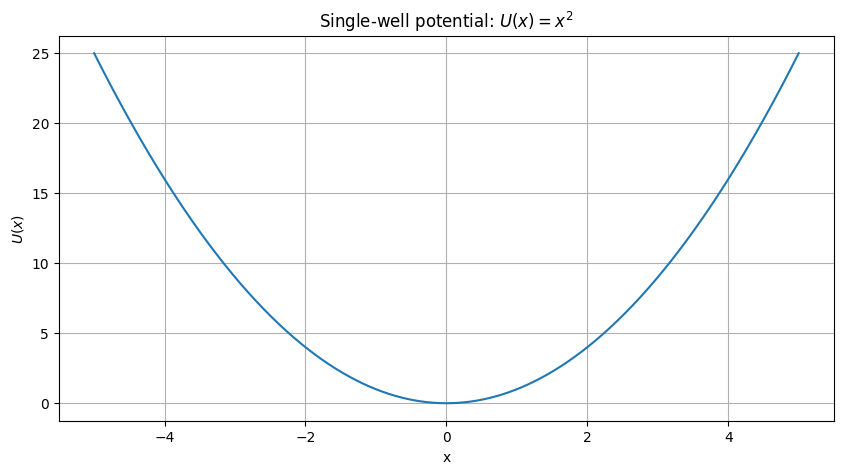

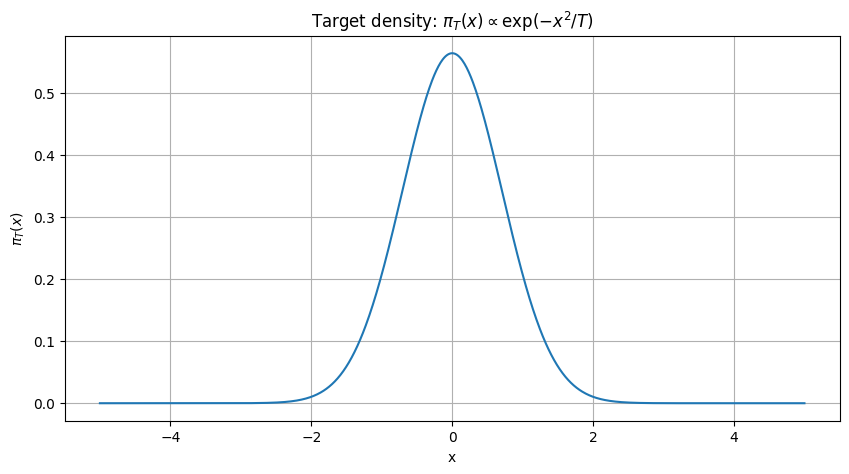

In [3]:
temperature = 1.0

x_grid = np.linspace(-5, 5, 1000)
density = target_distribution(x_grid, U_single, temperature)

plt.figure(figsize=(10, 5))
plt.plot(x_grid, U_single(x_grid))
plt.xlabel("x")
plt.ylabel(r"$U(x)$")
plt.title(r"Single-well potential: $U(x)=x^2$")
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(x_grid, density)
plt.xlabel("x")
plt.ylabel(r"$\pi_T(x)$")
plt.title(r"Target density: $\pi_T(x) \propto \exp(-x^2/T)$")
plt.grid()
plt.show()

### Metropolis Sampling

The Metropolis algorithm generates samples using random proposals that are accepted or rejected according to the change in potential energy.

In [4]:
def metropolis_step(x_current, proposal_width, temperature, potential_func, rng):
    """
    Perform a single Metropolis-Hastings step.

    Args:
        x_current (_type_): _description_
        proposal_width (_type_): _description_
        temperature (_type_): _description_
        potential_func (_type_): _description_
        rng (_type_): _description_

    Returns:
        _type_: _description_
    """
    noise = rng.uniform(-proposal_width / 2, proposal_width / 2)
    x_proposed = x_current + noise
    
    delta_U = potential_func(x_proposed) - potential_func(x_current)
    
    acceptance_prob = min(1, np.exp(-delta_U / temperature))
    
    if rng.random() < acceptance_prob:
        return x_proposed, True
    else:
        return x_current, False
    
def run_metropolis(initial_x, num_steps, proposal_width, temperature, potential_func, rng):
    """
    Run a Metropolis-Hastings sampling simulation.

    Args:
        initial_x (float): The initial position.
        num_steps (int): The number of steps to run.
        proposal_width (float): The width of the proposal distribution.
        temperature (float): The temperature of the system.
        potential_func (callable): The potential function.
        rng (numpy.random.Generator): The random number generator.

    Returns:
        tuple: A tuple containing the trajectory and the acceptance rate.
    """
    trajectory = np.empty(num_steps + 1)
    trajectory[0] = initial_x
    
    current_x = initial_x
    accepted_moves = 0
    
    for step in range(1, num_steps + 1):
        current_x, accepted = metropolis_step(current_x, proposal_width, temperature, potential_func, rng)
        trajectory[step] = current_x
        
        if accepted:
            accepted_moves += 1
            
    acceptance_rate = accepted_moves / num_steps
    
    return trajectory, acceptance_rate

In [5]:
temperature = 1.0
initial_x = 5.0
burn_in = 1_000
num_samples = 10**5
num_steps = burn_in + num_samples
proposal_width = 2.0

metropolis_trajectory, metropolis_acceptance_rate = run_metropolis(
    initial_x=initial_x,
    num_steps=num_steps,
    proposal_width=proposal_width,
    temperature=temperature,
    potential_func=U_single,
    rng=rng
)

print(f"Metropolis acceptance rate: {metropolis_acceptance_rate:.2%}")

Metropolis acceptance rate: 72.89%


### Cumulative Distribution Functions

The empirical CDF of the generated samples is compared with the theoretical CDF of the target distribution.

In [6]:
def empirical_cdf(samples):
    """
    Calculate the empirical cumulative density function (CDF) from the given samples.

    Args:
        samples (array-like): A list or array of samples.

    Returns:
        tuple: A tuple containing the sorted samples and their corresponding cumulative probabilities.
    """
    sorted_samples = np.sort(samples)
    cumulative_probs = np.arange(1, len(sorted_samples) + 1) / len(sorted_samples)
    return sorted_samples, cumulative_probs

def theoretical_cdf(x_grid, potential_func, temperature):
    """
    Calculate the theoretical cumulative density function (CDF) based on the target distribution.

    Args:
        x_grid (float): The grid of x values over which to compute the CDF.
        potential_func (float): The potential energy function.
        temperature (float): The temperature parameter for the target distribution.

    Returns:
        array: Theoretical cumulative probabilities corresponding to the x_grid.
    """ 
    density = target_distribution(x_grid, potential_func, temperature)

    cumulative = np.zeros_like(x_grid)
    cumulative[1:] = np.cumsum(
        0.5 * (density[1:] + density[:-1]) * np.diff(x_grid)
    )

    cumulative = cumulative / cumulative[-1]

    return cumulative

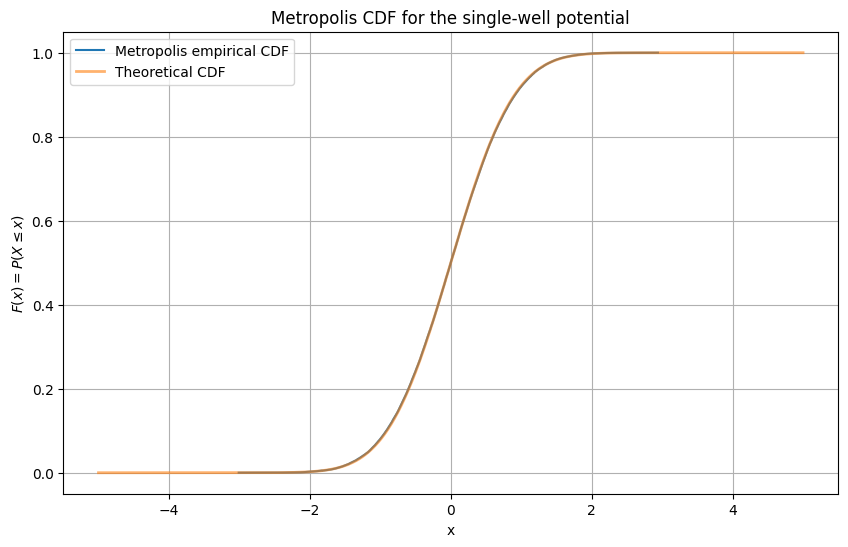

In [7]:
metropolis_samples = metropolis_trajectory[burn_in + 1:]

metropolis_x_cdf, metropolis_y_cdf = empirical_cdf(metropolis_samples)

x_grid = np.linspace(-5, 5, 4000)
theory_cdf = theoretical_cdf(x_grid, U_single, temperature)

plt.figure(figsize=(10, 6))

plt.plot(
    metropolis_x_cdf,
    metropolis_y_cdf,
    label="Metropolis empirical CDF"
)

plt.plot(
    x_grid,
    theory_cdf,
    linewidth=2,
    alpha=0.6,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("Metropolis CDF for the single-well potential")
plt.grid()
plt.legend()
plt.show()

### Event-Chain Monte Carlo

Apply ECMC to the single-well potential by calculating the distance to the next event.

In [8]:
def distance_to_next_event_single_well(x_current, velocity, temperature, rng):
    """
    Calculate the distance to the next event in a single-well potential.

    Args:
        x_current (float): The current position.
        velocity (float): The velocity.
        temperature (float): The temperature.
        rng (numpy.random.Generator): A random number generator.

    Returns:
        float: The distance to the next event.
    """
    uphill_energy = rng.exponential(scale=temperature)
    
    y0 = velocity * x_current
    
    if y0 < 0:
        distance_to_minimum = -y0
        
        uphill_distance = np.sqrt(uphill_energy)
        
        return distance_to_minimum + uphill_distance
    
    else:
        return np.sqrt(y0**2 + uphill_energy) - y0

In [9]:
def run_ecmc_single_well(initial_x, num_burn_in_steps, num_samples, distance_between_samples, temperature, potential_func, rng):
    """
    Run the Event-Chain Monte Carlo (ECMC) algorithm for a single-well potential.
    
    Args:
        initial_x (float): The initial position of the particle.
        num_burn_in_steps (int): The number of burn-in steps before sampling.
        num_samples (int): The number of samples to collect after burn-in.
        distance_between_samples (float): The distance to move between samples.
        temperature (float): The temperature parameter for the target distribution.
        potential_func (callable): The potential energy function.
        rng (numpy.random.Generator): A random number generator.
        
    Returns:
        np.ndarray: An array containing the potential trajectory and position trajectory.
    """
    current_x = initial_x

    num_iterations = num_burn_in_steps + num_samples

    potential_trajectory = np.empty(num_iterations)
    position_trajectory = np.empty(num_iterations)

    num_events = 0

    for iteration in range(num_iterations):

        # Uniformly resample the velocity at the start of each sampling interval.
        velocity = rng.choice([-1, 1])

        distance_remaining = distance_between_samples

        while distance_remaining > 0:

            distance_to_event = distance_to_next_event_single_well(
                current_x,
                velocity,
                temperature,
                rng
            )

            if distance_to_event <= distance_remaining:
                # Move to the event.
                current_x += velocity * distance_to_event

                # Reduce the remaining distance.
                distance_remaining -= distance_to_event

                # Bounce at the event.
                velocity *= -1

                num_events += 1

            else:
                # No event before the next sample.
                current_x += velocity * distance_remaining
                distance_remaining = 0

        potential_trajectory[iteration] = potential_func(current_x)
        position_trajectory[iteration] = current_x

    print(f"Number of ECMC events: {num_events}")

    return np.array([potential_trajectory, position_trajectory])

Number of ECMC events: 56986


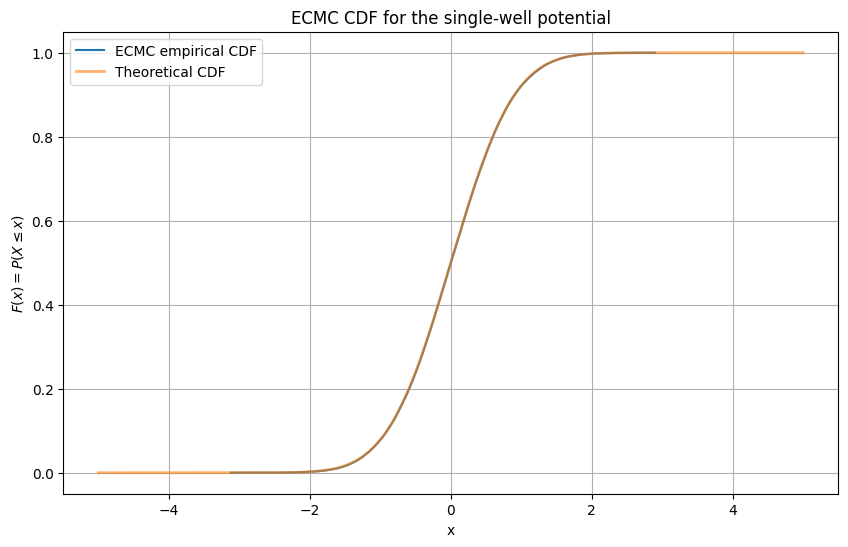

In [10]:
num_burn_in_steps = 1_000
num_samples = 10**5
distance_between_samples = 1.0
initial_x = 5.0
temperature = 1.0

ecmc_trajectory = run_ecmc_single_well(
    initial_x=initial_x,
    temperature=temperature,
    num_burn_in_steps=num_burn_in_steps,
    num_samples=num_samples,
    distance_between_samples=distance_between_samples,
    potential_func=U_single,
    rng=rng
)

ecmc_potential_samples = ecmc_trajectory[0, num_burn_in_steps:]
ecmc_position_samples = ecmc_trajectory[1, num_burn_in_steps:]

ecmc_x_cdf, ecmc_y_cdf = empirical_cdf(ecmc_position_samples)

x_grid = np.linspace(-5, 5, 4000)
theory_cdf = theoretical_cdf(x_grid, U_single, temperature)

plt.figure(figsize=(10, 6))

plt.plot(
    ecmc_x_cdf,
    ecmc_y_cdf,
    label="ECMC empirical CDF"
)

plt.plot(
    x_grid,
    theory_cdf,
    linewidth=2,
    alpha=0.6,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("ECMC CDF for the single-well potential")
plt.grid()
plt.legend()
plt.show()

### Single-Well Comparison

Compare the Metropolis and ECMC results for the single-well potential.

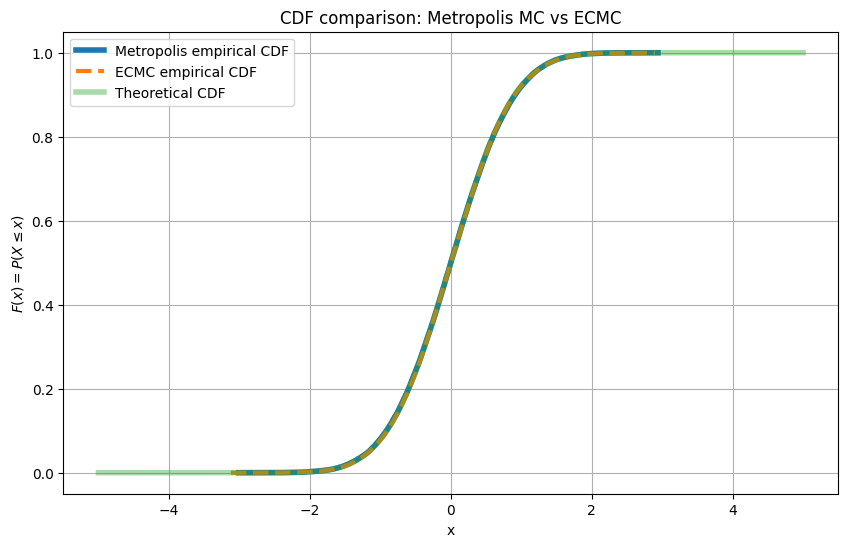

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    metropolis_x_cdf,
    metropolis_y_cdf,
    linewidth=4,
    label="Metropolis empirical CDF"
)

plt.plot(
    ecmc_x_cdf,
    ecmc_y_cdf,
    linewidth=3,
    linestyle="--",
    label="ECMC empirical CDF"
)

plt.plot(
    x_grid,
    theory_cdf,
    linewidth=4,
    alpha=0.4,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("CDF comparison: Metropolis MC vs ECMC")
plt.grid()
plt.legend()
plt.show()

## Double-Well Potential

The second comparison uses the double-well potential

$$
U(x)=-\frac{a}{2}x^2+\frac{b}{4}x^4.
$$

In [12]:
def U_double(x, a=2.0, b=1.0):
    """
    Calculate the double-well potential energy function.

    Args:
        x (float): The position at which to evaluate the potential.
        a (float, optional): The coefficient for the quadratic term. Defaults to 2.0.
        b (float, optional): The coefficient for the quartic term. Defaults to 1.0.

    Returns:
        float: The potential energy at position x.
    """
    return -(a / 2) * x**2 + (b / 4) * x**4

def dU_double(x, a=2.0, b=1.0):
    """
    Calculate the derivative of the double-well potential energy function.

    Args:
        x (float): The position at which to evaluate the derivative.
        a (float, optional): The coefficient for the quadratic term. Defaults to 2.0.
        b (float, optional): The coefficient for the quartic term. Defaults to 1.0.

    Returns:
        float: The derivative of the potential energy at position x.
    """
    return -a*x + b*x**3

In [13]:
a = 2.0
b = 1.0
temperature = 1.0

left_minimum = -np.sqrt(a / b)
right_minimum = np.sqrt(a / b)

barrier_position = 0.0

left_well_depth = U_double(left_minimum, a, b)
right_well_depth = U_double(right_minimum, a, b)
barrier_height = U_double(barrier_position, a, b)

barrier_from_well = barrier_height - left_well_depth

print(f"Left minimum: x = {left_minimum:.3f}")
print(f"Right minimum: x = {right_minimum:.3f}")
print(f"Barrier position: x = {barrier_position:.3f}")
print(f"Potential at each minimum: U = {left_well_depth:.3f}")
print(f"Barrier height: U = {barrier_height:.3f}")
print(f"Energy barrier from well to centre: barrier difference = {barrier_from_well:.3f}")

Left minimum: x = -1.414
Right minimum: x = 1.414
Barrier position: x = 0.000
Potential at each minimum: U = -1.000
Barrier height: U = 0.000
Energy barrier from well to centre: barrier difference = 1.000


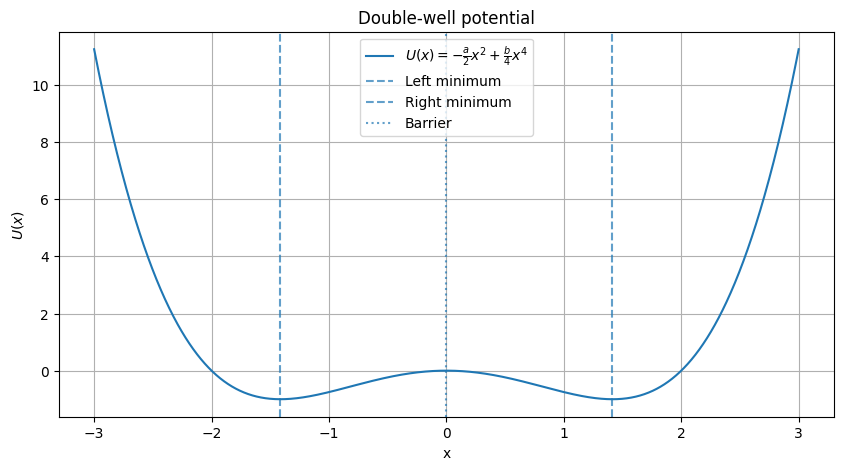

In [14]:
x_grid_double = np.linspace(-3, 3, 2000)

plt.figure(figsize=(10, 5))

plt.plot(
    x_grid_double,
    U_double(x_grid_double, a, b),
    label=r"$U(x) = -\frac{a}{2}x^2 + \frac{b}{4}x^4$"
)

plt.axvline(left_minimum, linestyle="--", alpha=0.7, label="Left minimum")
plt.axvline(right_minimum, linestyle="--", alpha=0.7, label="Right minimum")
plt.axvline(barrier_position, linestyle=":", alpha=0.7, label="Barrier")

plt.xlabel("x")
plt.ylabel(r"$U(x)$")
plt.title("Double-well potential")
plt.grid()
plt.legend()
plt.show()

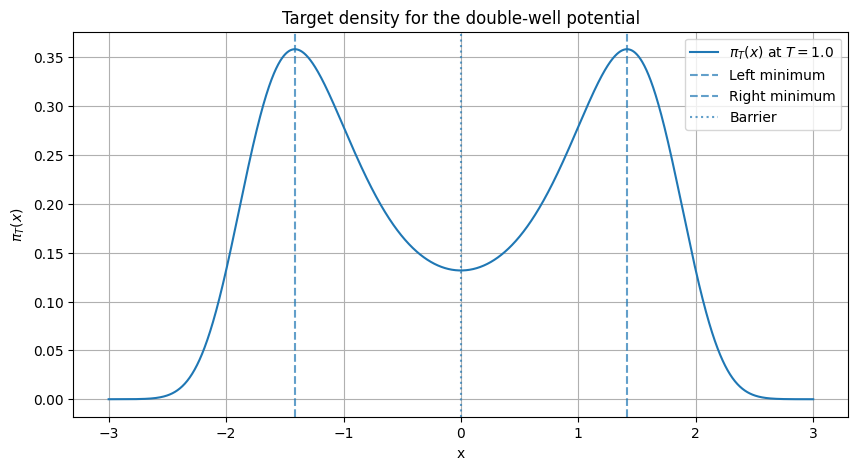

In [15]:
double_density = target_distribution(
    x_grid_double,
    lambda x: U_double(x, a, b),
    temperature
)

plt.figure(figsize=(10, 5))

plt.plot(
    x_grid_double,
    double_density,
    label=fr"$\pi_T(x)$ at $T={temperature}$"
)

plt.axvline(left_minimum, linestyle="--", alpha=0.7, label="Left minimum")
plt.axvline(right_minimum, linestyle="--", alpha=0.7, label="Right minimum")
plt.axvline(barrier_position, linestyle=":", alpha=0.7, label="Barrier")

plt.xlabel("x")
plt.ylabel(r"$\pi_T(x)$")
plt.title("Target density for the double-well potential")
plt.grid()
plt.legend()
plt.show()

### Double-Well Metropolis Sampling

Apply the Metropolis algorithm to the double-well potential.

In [16]:
double_potential = lambda x: U_double(x, a, b)

temperature = 1.0
initial_x = 0.0
burn_in = 1_000
num_samples = 10**5
num_steps = burn_in + num_samples
proposal_width = 1.0

metropolis_double_trajectory, metropolis_double_acceptance_rate = run_metropolis(
    initial_x=initial_x,
    num_steps=num_steps,
    proposal_width=proposal_width,
    temperature=temperature,
    potential_func=double_potential,
    rng=rng
)

print(f"Double-well Metropolis acceptance rate: {metropolis_double_acceptance_rate:.2%}")

Double-well Metropolis acceptance rate: 85.99%


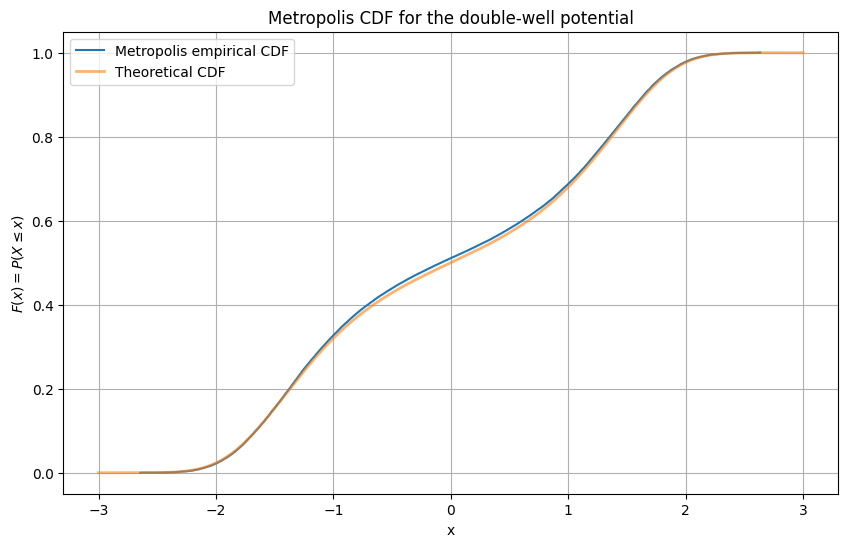

In [17]:
metropolis_double_samples = metropolis_double_trajectory[burn_in + 1:]

metropolis_double_x_cdf, metropolis_double_y_cdf = empirical_cdf(
    metropolis_double_samples
)

x_grid_double = np.linspace(-3, 3, 4000)

theory_double_cdf = theoretical_cdf(
    x_grid_double,
    double_potential,
    temperature
)

plt.figure(figsize=(10, 6))

plt.plot(
    metropolis_double_x_cdf,
    metropolis_double_y_cdf,
    label="Metropolis empirical CDF"
)

plt.plot(
    x_grid_double,
    theory_double_cdf,
    linewidth=2,
    alpha=0.6,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("Metropolis CDF for the double-well potential")
plt.grid()
plt.legend()
plt.show()

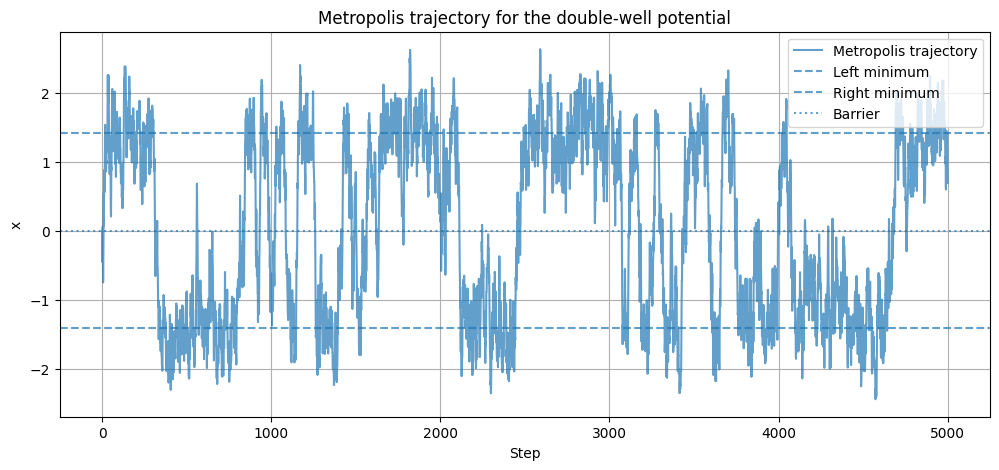

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(metropolis_double_trajectory[:5_000], alpha=0.7, label="Metropolis trajectory")
plt.axhline(left_minimum, linestyle="--", alpha=0.7, label="Left minimum")
plt.axhline(right_minimum, linestyle="--", alpha=0.7, label="Right minimum")
plt.axhline(barrier_position, linestyle=":", alpha=0.7, label="Barrier")

plt.xlabel("Step")
plt.ylabel("x")
plt.title("Metropolis trajectory for the double-well potential")
plt.grid()
plt.legend()
plt.show()

### Double-Well ECMC Sampling

Apply ECMC to the double-well potential by calculating the turning points and event distances.

In [19]:
def next_turning_point_double_well(x_current, velocity, a, b, tolerance=1e-12):
    """
    Finds the next turning point for a double well potential.

    Args:
        x_current (float): The current position.
        velocity (float): The current velocity.
        a (float): The coefficient for the quadratic term.
        b (float): The coefficient for the quartic term.
        tolerance (float, optional): The tolerance for floating-point comparisons. Defaults to 1e-12.

    Returns:
        float or None: The position of the next turning point, or None if no such point exists.
    """
    minimum_position = np.sqrt(a / b)

    turning_points = np.array([
        -minimum_position,
        0.0,
        minimum_position
    ])

    if velocity > 0:
        points_ahead = turning_points[turning_points > x_current + tolerance]

        if len(points_ahead) == 0:
            return None

        return points_ahead[0]

    else:
        points_ahead = turning_points[turning_points < x_current - tolerance]

        if len(points_ahead) == 0:
            return None

        return points_ahead[-1]

In [20]:
def solve_distance_to_target_potential(x_start, velocity, target_potential, potential_func, max_distance=None, tolerance=1e-12, max_iterations=100):
    """
    Solve for the distance to the target potential using a bisection method.

    Args:
        x_start (float): The starting position.
        velocity (float): The velocity.
        target_potential (float): The target potential.
        potential_func (callable): The potential function.
        max_distance (float, optional): The maximum distance to consider. Defaults to None.
        tolerance (float, optional): The tolerance for floating-point comparisons. Defaults to 1e-12.
        max_iterations (int, optional): The maximum number of iterations. Defaults to 100.

    Raises:
        RuntimeError: If the event distance cannot be bracketed.

    Returns:
        float: The distance to the target potential.
    """             
    left_distance = 0.0

    if max_distance is None:
        right_distance = 1.0

        while potential_func(x_start + velocity * right_distance) < target_potential:
            right_distance *= 2.0

            if right_distance > 10**5:
                raise RuntimeError("Could not bracket the event distance.")

    else:
        right_distance = max_distance

    for _ in range(max_iterations):

        middle_distance = 0.5 * (left_distance + right_distance)
        middle_position = x_start + velocity * middle_distance
        middle_potential = potential_func(middle_position)

        if middle_potential < target_potential:
            left_distance = middle_distance
        else:
            right_distance = middle_distance

        if right_distance - left_distance < tolerance:
            break

    return 0.5 * (left_distance + right_distance)

In [21]:
def distance_to_next_event_double_well(x_current, velocity, temperature, a, b, rng, tolerance=1e-12):
    """
    Calculate the distance to the next event in a double-well potential.

    Args:
        x_current (float): The current position.
        velocity (float): The velocity.
        temperature (float): The temperature.
        a (float): The coefficient for the quadratic term.
        b (float): The coefficient for the quartic term.
        rng (numpy.random.Generator): The random number generator.
        tolerance (float, optional): The tolerance for floating-point comparisons. Defaults to 1e-12.

    Raises:
        RuntimeError: If the event distance cannot be bracketed.

    Returns:
        float: The distance to the next event.
    """
    potential_func = lambda x: U_double(x, a, b)

    uphill_energy = rng.exponential(scale=temperature)

    total_distance = 0.0
    current_x = x_current

    while True:

        next_turning_point = next_turning_point_double_well(
            current_x,
            velocity,
            a,
            b,
            tolerance=tolerance
        )

        if next_turning_point is None:
            test_x = current_x + velocity
        else:
            test_x = 0.5 * (current_x + next_turning_point)

        moving_uphill = velocity * dU_double(test_x, a, b) > 0

        if not moving_uphill:

            if next_turning_point is None:
                raise RuntimeError("Unexpected downhill direction with no turning point ahead.")

            distance_to_turning_point = abs(next_turning_point - current_x)

            total_distance += distance_to_turning_point
            current_x = next_turning_point

        else:

            current_potential = potential_func(current_x)

            if next_turning_point is None:

                target_potential = current_potential + uphill_energy

                event_distance = solve_distance_to_target_potential(
                    x_start=current_x,
                    velocity=velocity,
                    target_potential=target_potential,
                    potential_func=potential_func,
                    max_distance=None,
                    tolerance=tolerance
                )

                return total_distance + event_distance

            else:

                turning_point_potential = potential_func(next_turning_point)
                available_uphill_energy = turning_point_potential - current_potential

                if uphill_energy <= available_uphill_energy + tolerance:

                    target_potential = current_potential + uphill_energy
                    max_distance = abs(next_turning_point - current_x)

                    event_distance = solve_distance_to_target_potential(
                        x_start=current_x,
                        velocity=velocity,
                        target_potential=target_potential,
                        potential_func=potential_func,
                        max_distance=max_distance,
                        tolerance=tolerance
                    )

                    return total_distance + event_distance

                else:

                    uphill_energy -= available_uphill_energy

                    distance_to_turning_point = abs(next_turning_point - current_x)

                    total_distance += distance_to_turning_point
                    current_x = next_turning_point

In [22]:
def run_ecmc_double_well(initial_x, num_burn_in_steps, num_samples, distance_between_samples, temperature, a, b, rng):
    """
    Run the Event-Chain Monte Carlo (ECMC) algorithm for a double-well potential.

    Args:
        initial_x (float): The initial position.
        num_burn_in_steps (int): The number of burn-in steps.
        num_samples (int): The number of samples to generate.
        distance_between_samples (float): The distance between samples.
        temperature (float): The temperature.
        a (float): The coefficient for the quadratic term.
        b (float): The coefficient for the quartic term.
        rng (numpy.random.Generator): The random number generator.

    Returns:
        numpy.ndarray: An array containing the potential and position trajectories.
    """
    current_x = initial_x

    num_iterations = num_burn_in_steps + num_samples

    potential_trajectory = np.empty(num_iterations)
    position_trajectory = np.empty(num_iterations)

    num_events = 0

    for iteration in range(num_iterations):

        velocity = rng.choice([-1, 1])

        distance_remaining = distance_between_samples

        while distance_remaining > 0:

            distance_to_event = distance_to_next_event_double_well(
                current_x,
                velocity,
                temperature,
                a,
                b,
                rng
            )

            if distance_to_event <= distance_remaining:

                current_x += velocity * distance_to_event

                distance_remaining -= distance_to_event

                velocity *= -1

                num_events += 1

            else:

                current_x += velocity * distance_remaining

                distance_remaining = 0

        potential_trajectory[iteration] = U_double(current_x, a, b)
        position_trajectory[iteration] = current_x

    print(f"Number of double-well ECMC events: {num_events}")

    return np.array([potential_trajectory, position_trajectory])

In [23]:
num_burn_in_steps = 1_000
num_samples = 10**5
distance_between_samples = 1.0
initial_x = 0.0
temperature = 1.0

ecmc_double_trajectory = run_ecmc_double_well(
    initial_x=initial_x,
    num_burn_in_steps=num_burn_in_steps,
    num_samples=num_samples,
    distance_between_samples=distance_between_samples,
    temperature=temperature,
    a=a,
    b=b,
    rng=rng
)

ecmc_double_potential_samples = ecmc_double_trajectory[0, num_burn_in_steps:]
ecmc_double_position_samples = ecmc_double_trajectory[1, num_burn_in_steps:]

Number of double-well ECMC events: 58886


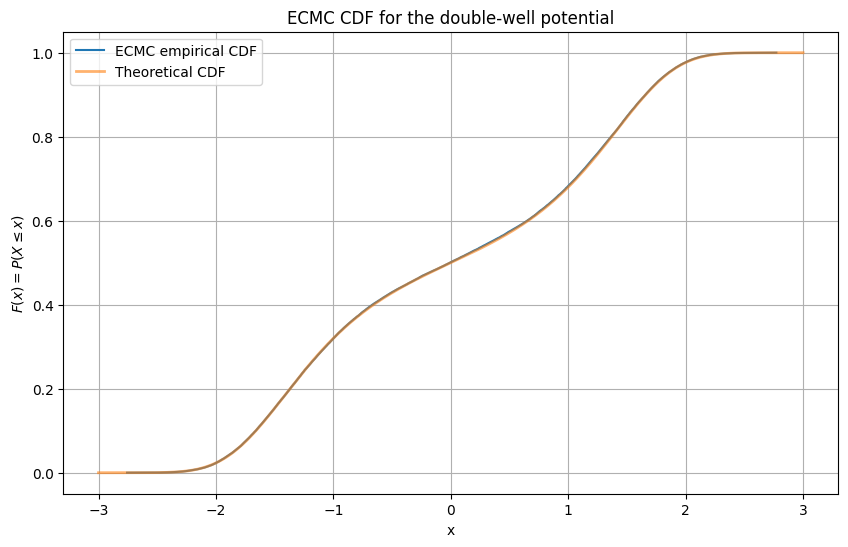

In [24]:
ecmc_double_x_cdf, ecmc_double_y_cdf = empirical_cdf(
    ecmc_double_position_samples
)

x_grid_double = np.linspace(-3, 3, 4000)

theory_double_cdf = theoretical_cdf(
    x_grid_double,
    double_potential,
    temperature
)

plt.figure(figsize=(10, 6))

plt.plot(
    ecmc_double_x_cdf,
    ecmc_double_y_cdf,
    label="ECMC empirical CDF"
)

plt.plot(
    x_grid_double,
    theory_double_cdf,
    linewidth=2,
    alpha=0.6,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("ECMC CDF for the double-well potential")
plt.grid()
plt.legend()
plt.show()

### Double-Well Comparison

Compare the CDFs and trajectories produced by Metropolis and ECMC.

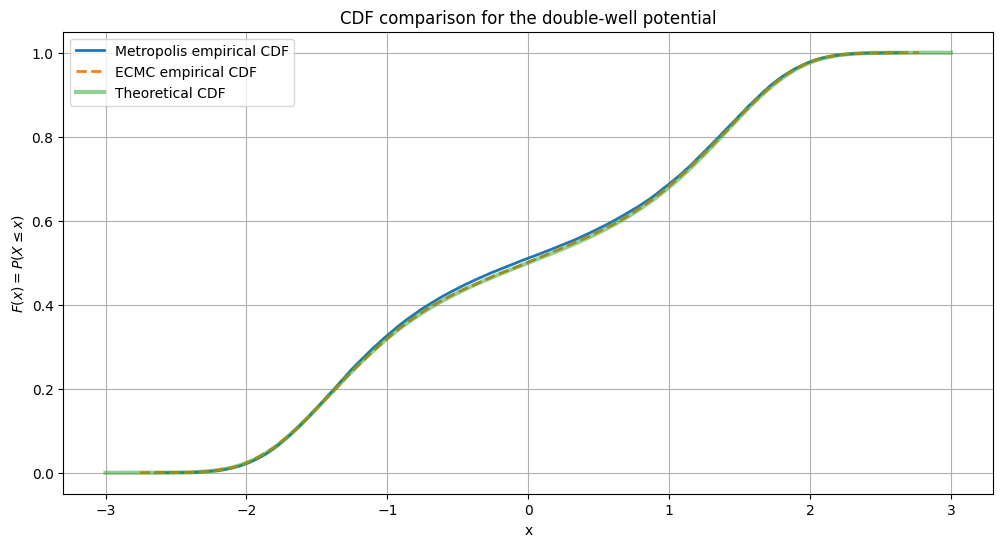

In [25]:
plt.figure(figsize=(12, 6))

plt.plot(
    metropolis_double_x_cdf,
    metropolis_double_y_cdf,
    linewidth=2,
    label="Metropolis empirical CDF"
)

plt.plot(
    ecmc_double_x_cdf,
    ecmc_double_y_cdf,
    linewidth=2,
    linestyle="--",
    label="ECMC empirical CDF"
)

plt.plot(
    x_grid_double,
    theory_double_cdf,
    linewidth=3,
    alpha=0.5,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("CDF comparison for the double-well potential")
plt.grid()
plt.legend()
plt.show()

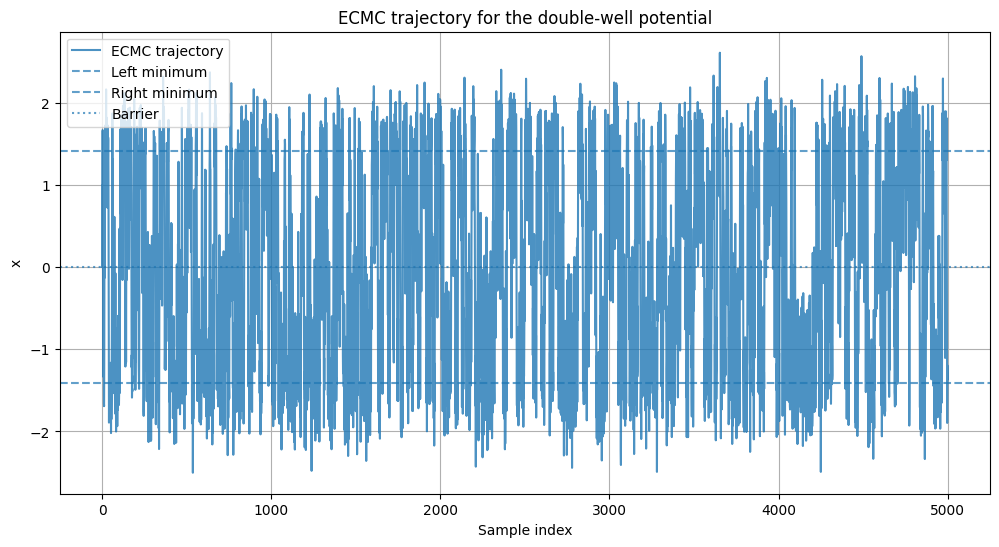

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(ecmc_double_trajectory[1][:5_000], alpha=0.8, label="ECMC trajectory")
plt.axhline(left_minimum, linestyle="--", alpha=0.7, label="Left minimum")
plt.axhline(right_minimum, linestyle="--", alpha=0.7, label="Right minimum")
plt.axhline(barrier_position, linestyle=":", alpha=0.7, label="Barrier")

plt.xlabel("Sample index")
plt.ylabel("x")
plt.title("ECMC trajectory for the double-well potential")
plt.grid()
plt.legend()
plt.show()

## ECMC Using Poisson Thinning

Use Poisson thinning to generate and accept candidate ECMC events from an upper bound on the event rate.

In [27]:
def event_rate_double_well(x, velocity, temperature, a, b):
    """
    Calculate the event rate for a double-well potential.

    Args:
        x (float): The current position.
        velocity (float): The current velocity.
        temperature (float): The temperature.
        a (float): The parameter a.
        b (float): The parameter b.

    Returns:
        float: The event rate.
    """
    return max(0.0, velocity * dU_double(x, a, b) / temperature)

def upper_bound_event_rate_double_well(x_start, velocity, max_distance, temperature, a, b, safety_factor=1.000001):
    """
    Calculate an upper bound for the event rate in a double-well potential.

    Args:
        x_start (float): The starting position.
        velocity (float): The velocity.
        max_distance (float): The maximum distance to consider.
        temperature (float): The temperature.
        a (float): The parameter a.
        b (float): The parameter b.
        safety_factor (float, optional): A safety factor to ensure the upper bound is valid. Defaults to 1.000001.

    Returns:
        float: The upper bound for the event rate.
    """
    x_end = x_start + velocity * max_distance

    x_low = min(x_start, x_end)
    x_high = max(x_start, x_end)

    # Candidate points include endpoints.
    candidate_points = [x_low, x_high]

    # For U'(x) = -a x + b x^3, the derivative of U' has roots
    # at x = +-sqrt(a / (3b)).
    critical = np.sqrt(a / (3*b))

    for point in [-critical, critical]:
        if x_low <= point <= x_high:
            candidate_points.append(point)

    rates = [
        event_rate_double_well(x, velocity, temperature, a, b)
        for x in candidate_points
    ]

    return safety_factor * max(rates)

def distance_to_next_event_double_well_thinning(x_current, velocity, max_distance, temperature, a, b, rng):
    """
    Calculate the distance to the next event in a double-well potential using thinning.

    Args:
        x_current (float): The current position.
        velocity (float): The velocity.
        max_distance (float): The maximum distance to consider.
        temperature (float): The temperature.
        a (float): The parameter a.
        b (float): The parameter b.
        rng (numpy.random.Generator): A random number generator.

    Returns:
        float: The distance to the next event, or None if no event occurs within the maximum distance.
    """
    rate_bound = upper_bound_event_rate_double_well(
        x_start=x_current,
        velocity=velocity,
        max_distance=max_distance,
        temperature=temperature,
        a=a,
        b=b
    )

    if rate_bound <= 0.0:
        return None

    traveled_distance = 0.0

    while traveled_distance < max_distance:

        # Candidate event from a homogeneous Poisson process with rate M.
        candidate_step = rng.exponential(scale=1.0 / rate_bound)
        traveled_distance += candidate_step

        if traveled_distance > max_distance:
            return None

        candidate_x = x_current + velocity * traveled_distance

        true_rate = event_rate_double_well(
            candidate_x,
            velocity,
            temperature,
            a,
            b
        )

        acceptance_probability = min(1.0, true_rate / rate_bound)

        if rng.random() < acceptance_probability:
            return traveled_distance

    return None

def run_ecmc_double_well_thinning(initial_x, num_burn_in_steps, num_samples, distance_between_samples, temperature, a, b, rng):
    """
    Run the Event-Chain Monte Carlo (ECMC) algorithm for a double-well potential using thinning.

    Args:
        initial_x (float): The initial position.
        num_burn_in_steps (int): The number of burn-in steps.
        num_samples (int): The number of samples to generate.
        distance_between_samples (float): The distance between samples.
        temperature (float): The temperature.
        a (float): The parameter a.
        b (float): The parameter b.
        rng (numpy.random.Generator): A random number generator.
        
    Returns:
        np.ndarray: An array containing the potential and position trajectories.
    """
    current_x = initial_x

    num_iterations = num_burn_in_steps + num_samples

    potential_trajectory = np.empty(num_iterations)
    position_trajectory = np.empty(num_iterations)

    num_events = 0

    for iteration in range(num_iterations):

        velocity = rng.choice([-1, 1])
        distance_remaining = distance_between_samples

        while distance_remaining > 0:

            distance_to_event = distance_to_next_event_double_well_thinning(
                x_current=current_x,
                velocity=velocity,
                max_distance=distance_remaining,
                temperature=temperature,
                a=a,
                b=b,
                rng=rng
            )

            if distance_to_event is None:
                current_x += velocity * distance_remaining
                distance_remaining = 0

            else:
                current_x += velocity * distance_to_event
                distance_remaining -= distance_to_event

                velocity *= -1
                num_events += 1

        potential_trajectory[iteration] = U_double(current_x, a, b)
        position_trajectory[iteration] = current_x

    print(f"Number of accepted ECMC events: {num_events}")

    return np.array([potential_trajectory, position_trajectory])

In [28]:
temperature = 1.0
num_burn_in_steps = 1_000
num_samples = 10**5
distance_between_samples = 1.0
initial_x = 0.0

ecmc_double_thinning_trajectory = run_ecmc_double_well_thinning(
    initial_x=initial_x,
    num_burn_in_steps=num_burn_in_steps,
    num_samples=num_samples,
    distance_between_samples=distance_between_samples,
    temperature=temperature,
    a=a,
    b=b,
    rng=rng
)

ecmc_double_thinning_samples = ecmc_double_thinning_trajectory[1, num_burn_in_steps:]

Number of accepted ECMC events: 59254


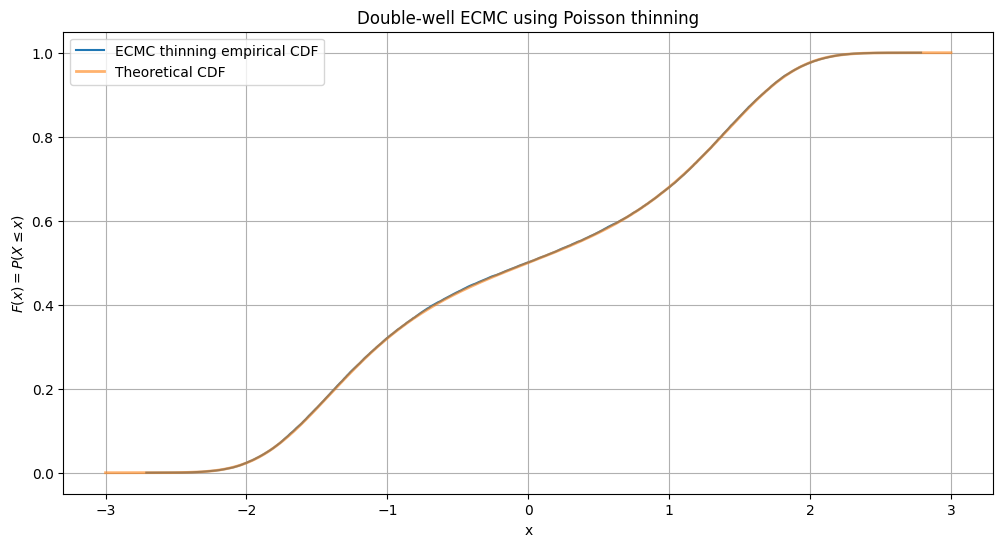

In [29]:
ecmc_double_thinning_x_cdf, ecmc_double_thinning_y_cdf = empirical_cdf(
    ecmc_double_thinning_samples
)

x_grid_double = np.linspace(-3, 3, 4000)

theory_double_cdf = theoretical_cdf(
    x_grid_double,
    double_potential,
    temperature
)

plt.figure(figsize=(12, 6))

plt.plot(
    ecmc_double_thinning_x_cdf,
    ecmc_double_thinning_y_cdf,
    label="ECMC thinning empirical CDF"
)

plt.plot(
    x_grid_double,
    theory_double_cdf,
    linewidth=2,
    alpha=0.6,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("Double-well ECMC using Poisson thinning")
plt.grid()
plt.legend()
plt.show()

## Temperature Experiments

Compare Metropolis and ECMC across a range of temperatures.

In [30]:
def run_double_well_temperature_experiment(temperature, a, b, num_burn_in_steps, num_samples, distance_between_samples, metropolis_proposal_width, initial_x, seed):
    """
    Run a temperature experiment for the double-well potential using both Metropolis and ECMC methods.

    Args:
        temperature (float): The temperature at which to run the experiment.
        a (float): The parameter a.
        b (float): The parameter b.
        num_burn_in_steps (int): The number of burn-in steps.
        num_samples (int): The number of samples to generate.
        distance_between_samples (float): The distance between samples.
        metropolis_proposal_width (float): The width of the Metropolis proposal distribution.
        initial_x (float): The initial position.
        seed (int): The random seed.

    Returns:
        dict: A dictionary containing the results of the experiment.
    """
    # Use a separate random number generator for this temperature.
    # This makes each temperature result reproducible on its own.
    local_rng = np.random.default_rng(seed)

    double_potential = lambda x: U_double(x, a, b)

    # Run Metropolis.
    metropolis_trajectory, metropolis_acceptance_rate = run_metropolis(
        initial_x=initial_x,
        num_steps=num_burn_in_steps + num_samples,
        proposal_width=metropolis_proposal_width,
        temperature=temperature,
        potential_func=double_potential,
        rng=local_rng
    )

    metropolis_samples = metropolis_trajectory[num_burn_in_steps + 1:]

    # Run ECMC with Poisson thinning.
    ecmc_trajectory = run_ecmc_double_well_thinning(
        initial_x=initial_x,
        num_burn_in_steps=num_burn_in_steps,
        num_samples=num_samples,
        distance_between_samples=distance_between_samples,
        temperature=temperature,
        a=a,
        b=b,
        rng=local_rng
    )

    ecmc_samples = ecmc_trajectory[1, num_burn_in_steps:]

    # CDFs.
    metropolis_x_cdf, metropolis_y_cdf = empirical_cdf(metropolis_samples)
    ecmc_x_cdf, ecmc_y_cdf = empirical_cdf(ecmc_samples)

    x_grid = np.linspace(-3, 3, 4000)

    theory_cdf = theoretical_cdf(
        x_grid,
        double_potential,
        temperature
    )


    return {
        "temperature": temperature,
        "metropolis_trajectory": metropolis_trajectory,
        "metropolis_samples": metropolis_samples,
        "metropolis_acceptance_rate": metropolis_acceptance_rate,
        "metropolis_x_cdf": metropolis_x_cdf,
        "metropolis_y_cdf": metropolis_y_cdf,
        "ecmc_trajectory": ecmc_trajectory,
        "ecmc_samples": ecmc_samples,
        "ecmc_x_cdf": ecmc_x_cdf,
        "ecmc_y_cdf": ecmc_y_cdf,
        "x_grid": x_grid,
        "theory_cdf": theory_cdf
    }

### Running the Temperature Experiments

Run both algorithms at each temperature and store their samples and the Metropolis acceptance rate.

In [31]:
temperatures = [
    1.2,
    1.0,
    0.8,
    0.7,
    0.6,
    0.5,
    0.4,
    0.3,
    0.2,
    0.1
]

results = {}
records = []

for index, temp in enumerate(temperatures):

    print(f"Running temperature T = {temp}")

    result = run_double_well_temperature_experiment(
        temperature=temp,
        a=a,
        b=b,
        num_burn_in_steps=1_000,
        num_samples=10**5,
        distance_between_samples=1.0,
        metropolis_proposal_width=1.0,
        initial_x=0.0,
        seed=42 + index
    )

    results[temp] = result

    records.append({
        "Temperature": temp,
        "Metropolis Acceptance (%)": (
            100 * result["metropolis_acceptance_rate"]
        )
    })

df = pd.DataFrame(
    records,
    columns=[
        "Temperature",
        "Metropolis Acceptance (%)"
    ]
)

print(df.to_string(index=False))

Running temperature T = 1.2
Number of accepted ECMC events: 52591
Running temperature T = 1.0
Number of accepted ECMC events: 58938
Running temperature T = 0.8
Number of accepted ECMC events: 68352
Running temperature T = 0.7
Number of accepted ECMC events: 74862
Running temperature T = 0.6
Number of accepted ECMC events: 83536
Running temperature T = 0.5
Number of accepted ECMC events: 94000
Running temperature T = 0.4
Number of accepted ECMC events: 110439
Running temperature T = 0.3
Number of accepted ECMC events: 133067
Running temperature T = 0.2
Number of accepted ECMC events: 170583
Running temperature T = 0.1
Number of accepted ECMC events: 249687
 Temperature  Metropolis Acceptance (%)
         1.2                  87.258416
         1.0                  85.408911
         0.8                  83.680198
         0.7                  82.198020
         0.6                  80.466337
         0.5                  77.270297
         0.4                  74.404950
         0.3    

### CDF Comparison Across Temperatures

Compare the empirical and theoretical CDFs at each temperature.

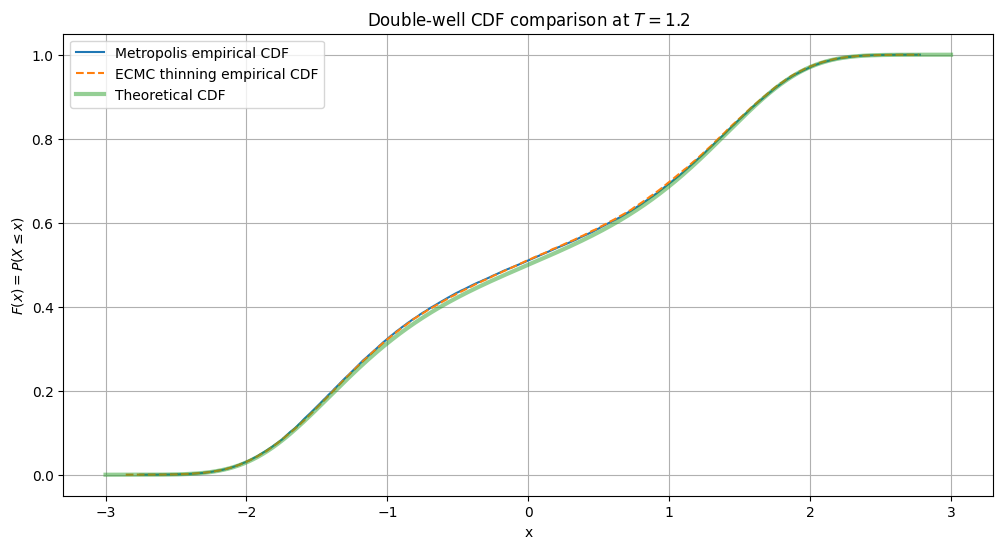

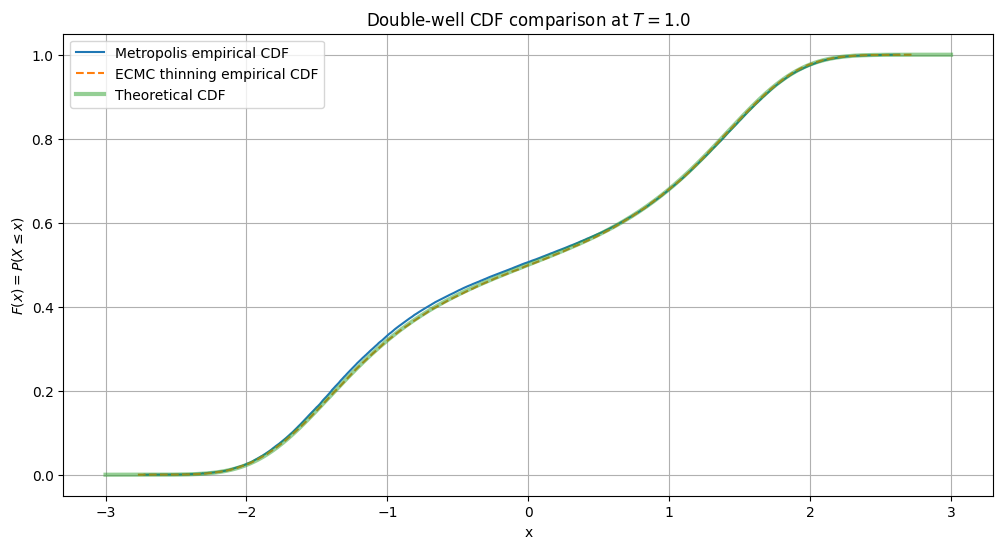

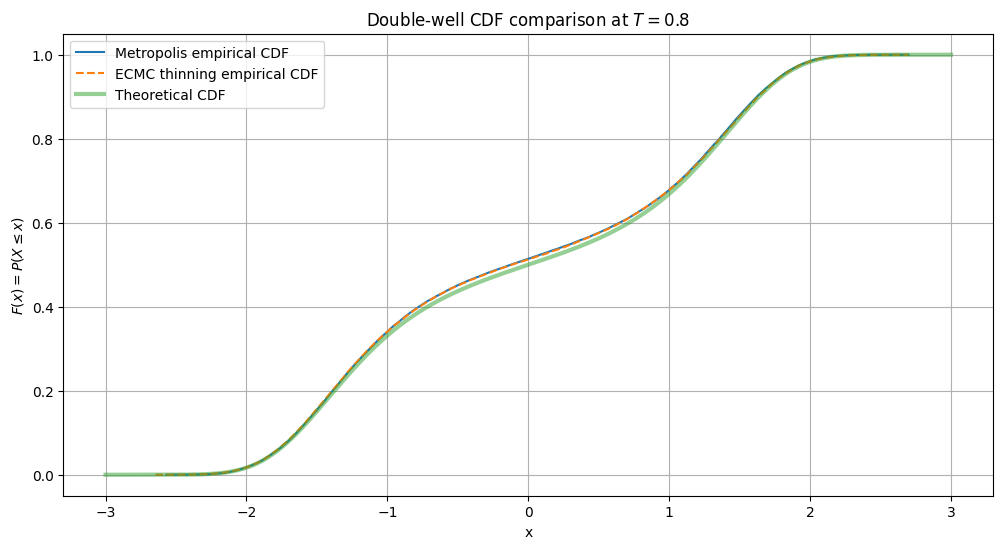

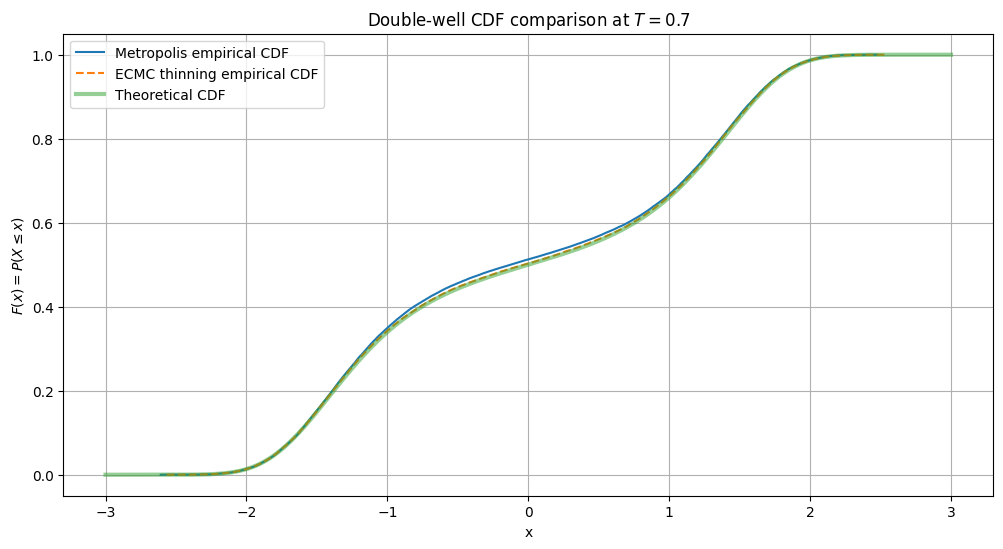

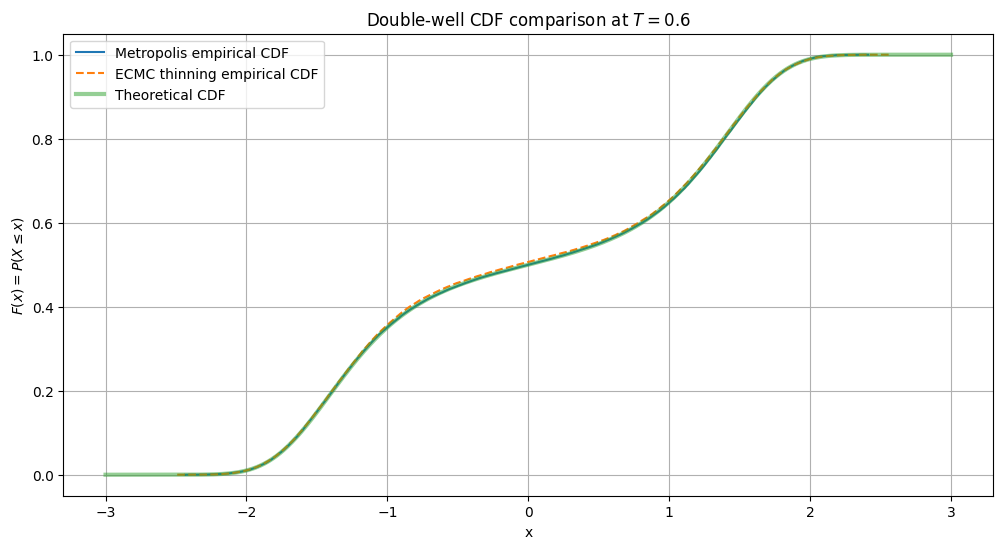

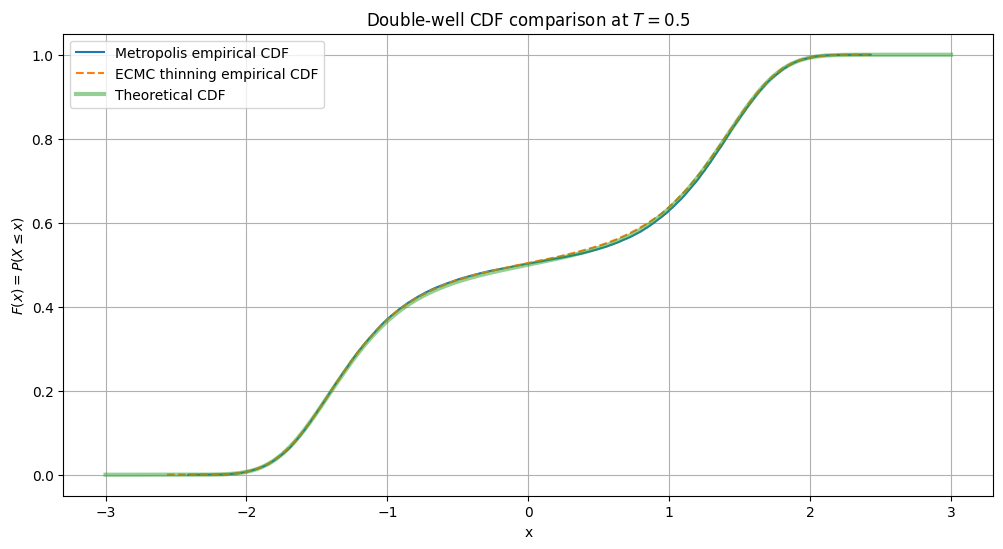

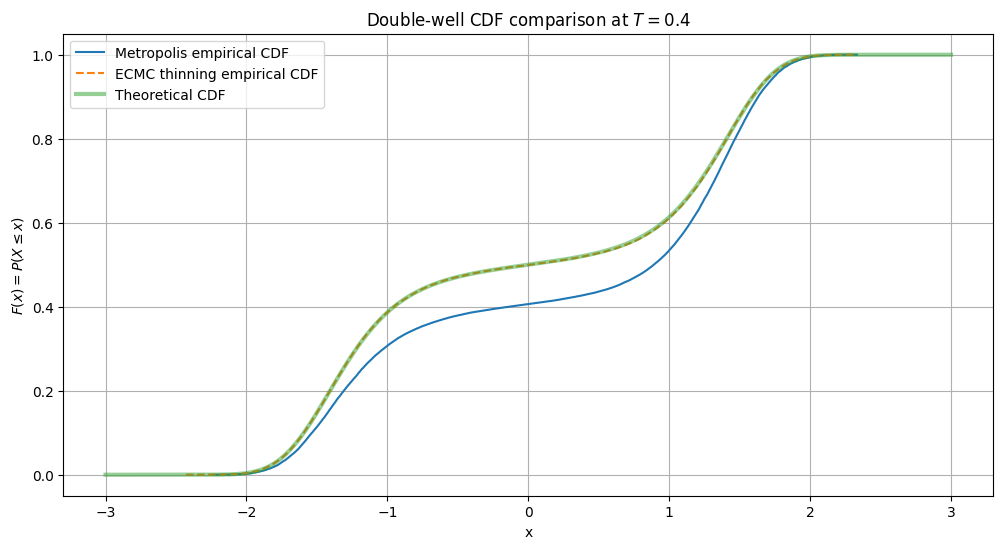

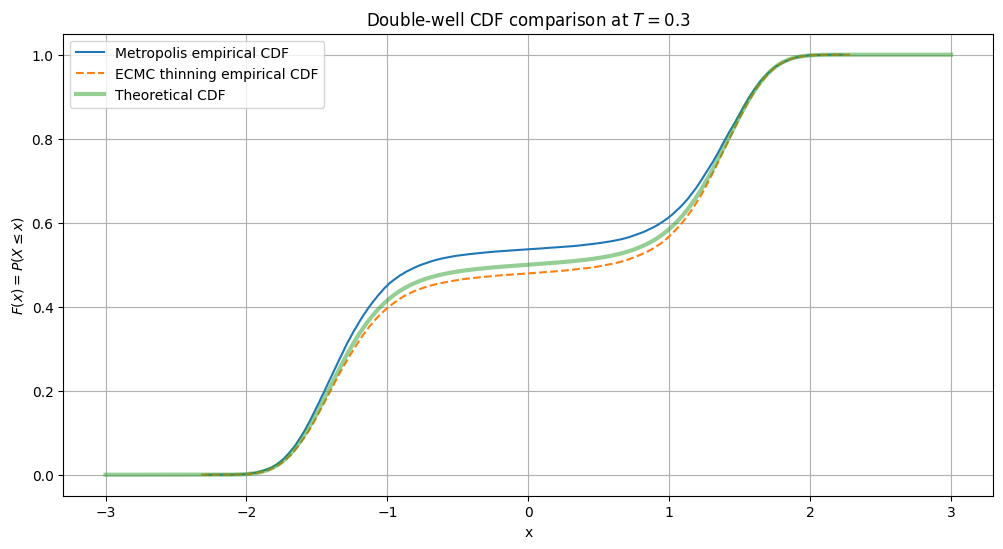

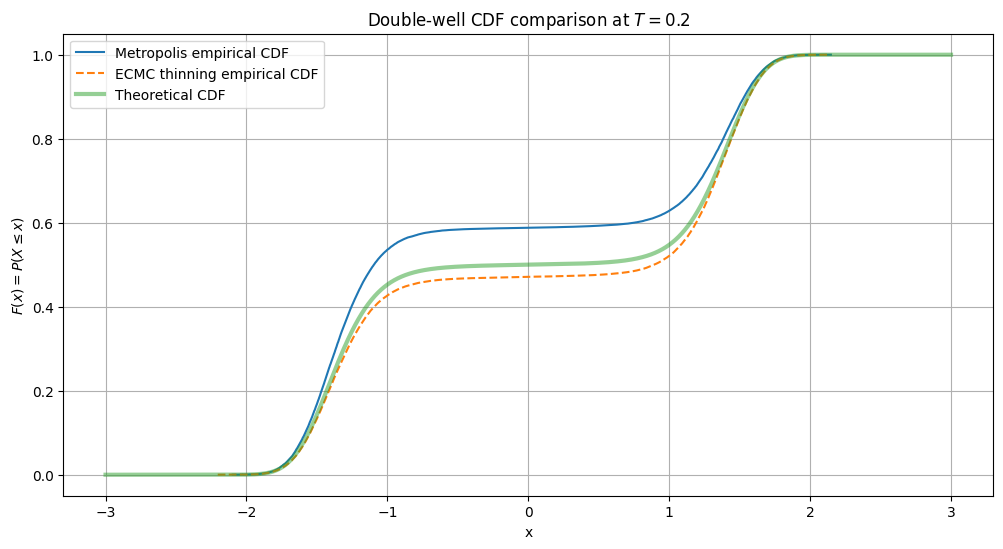

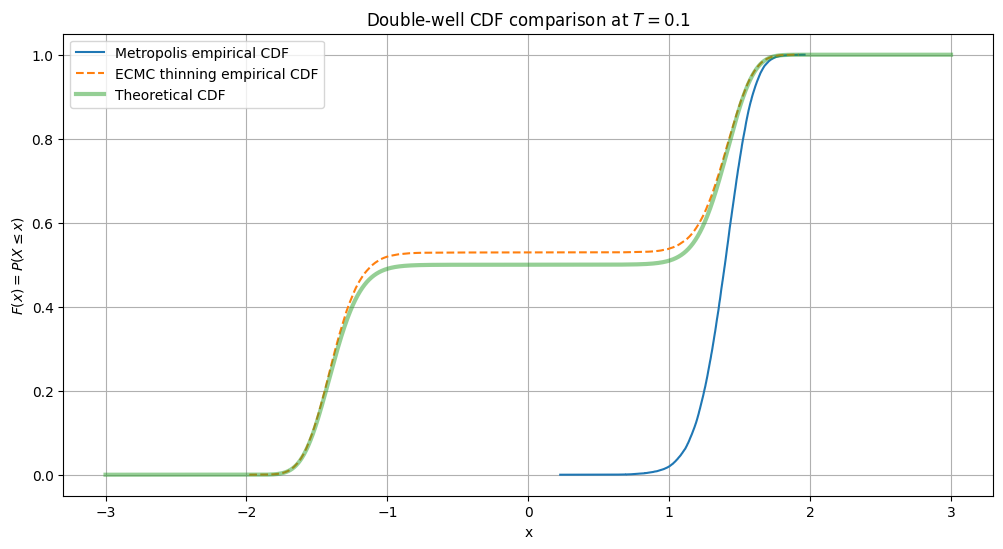

In [32]:
for temp in temperatures:

    result = results[temp]

    plt.figure(figsize=(12, 6))

    plt.plot(
        result["metropolis_x_cdf"],
        result["metropolis_y_cdf"],
        label="Metropolis empirical CDF"
    )

    plt.plot(
        result["ecmc_x_cdf"],
        result["ecmc_y_cdf"],
        linestyle="--",
        label="ECMC thinning empirical CDF"
    )

    plt.plot(
        result["x_grid"],
        result["theory_cdf"],
        linewidth=3,
        alpha=0.5,
        label="Theoretical CDF"
    )

    plt.xlabel("x")
    plt.ylabel(r"$F(x) = P(X \leq x)$")
    plt.title(fr"Double-well CDF comparison at $T={temp}$")
    plt.grid()
    plt.legend()
    plt.show()

### Trajectory Comparison Across Temperatures

Examine how frequently each algorithm moves between the two wells.

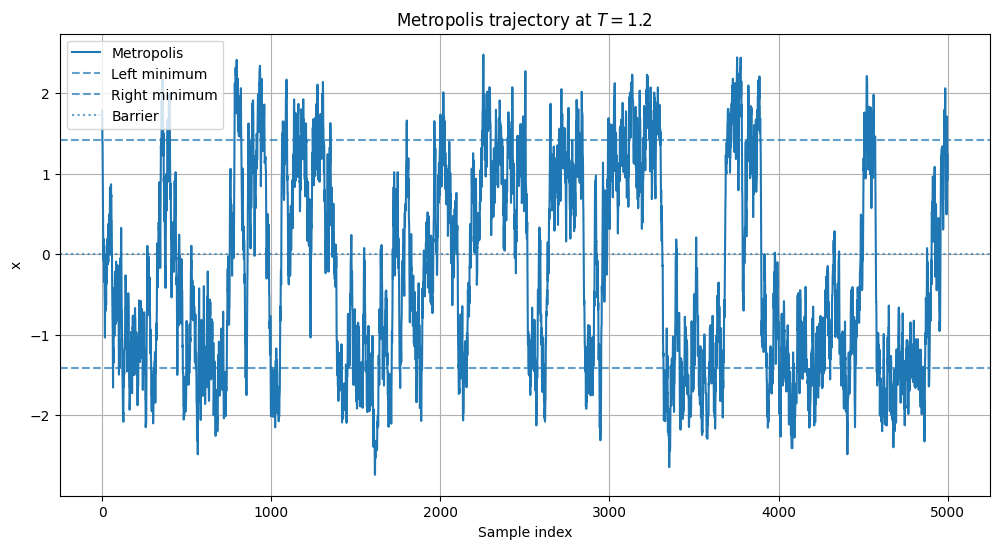

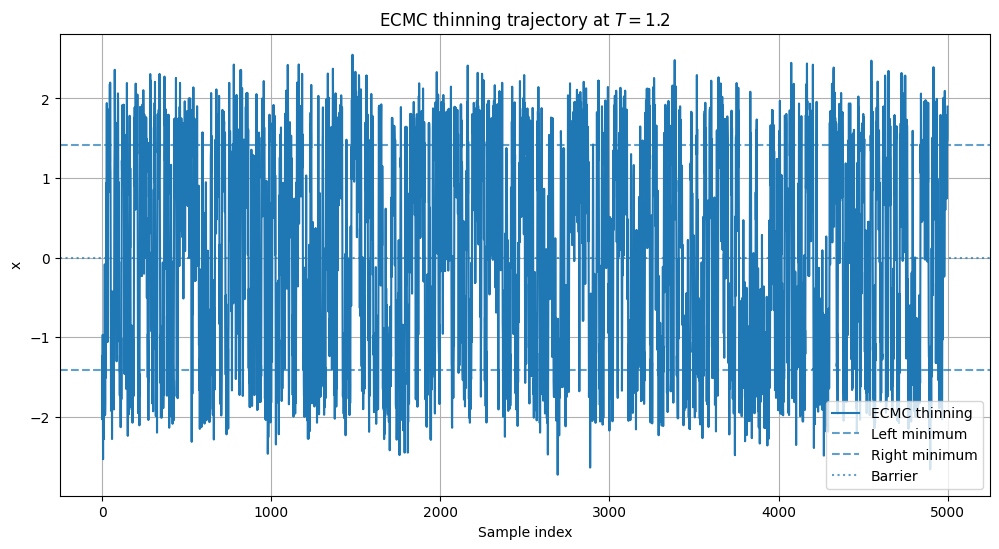

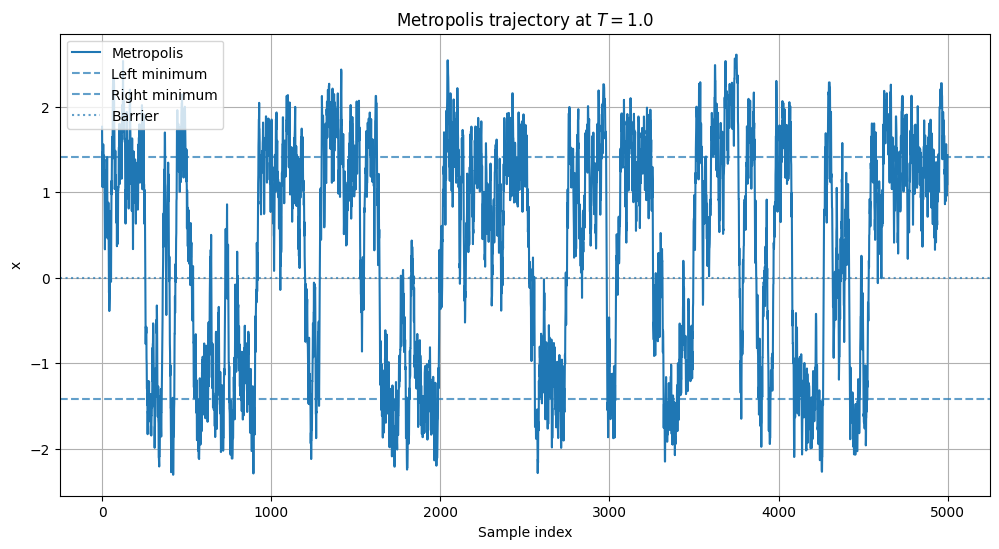

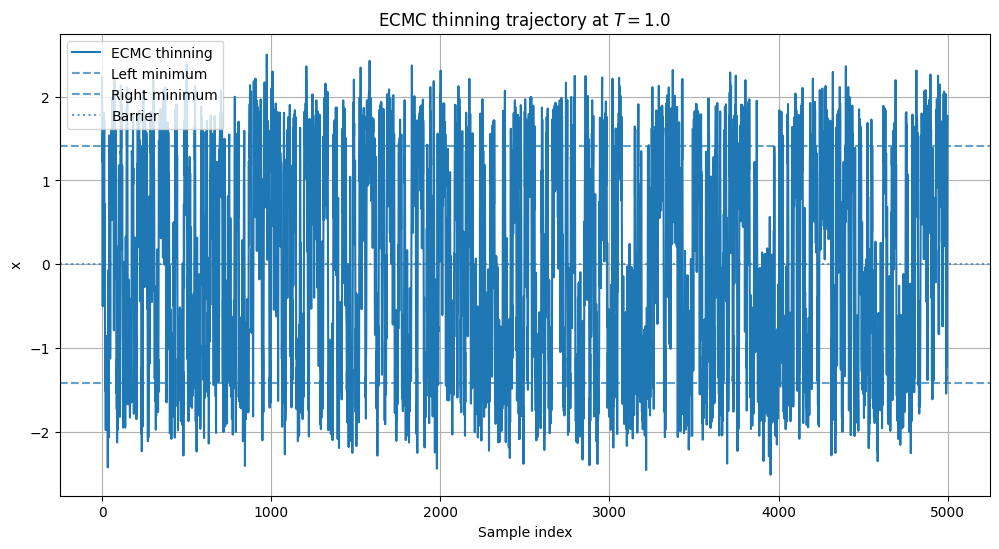

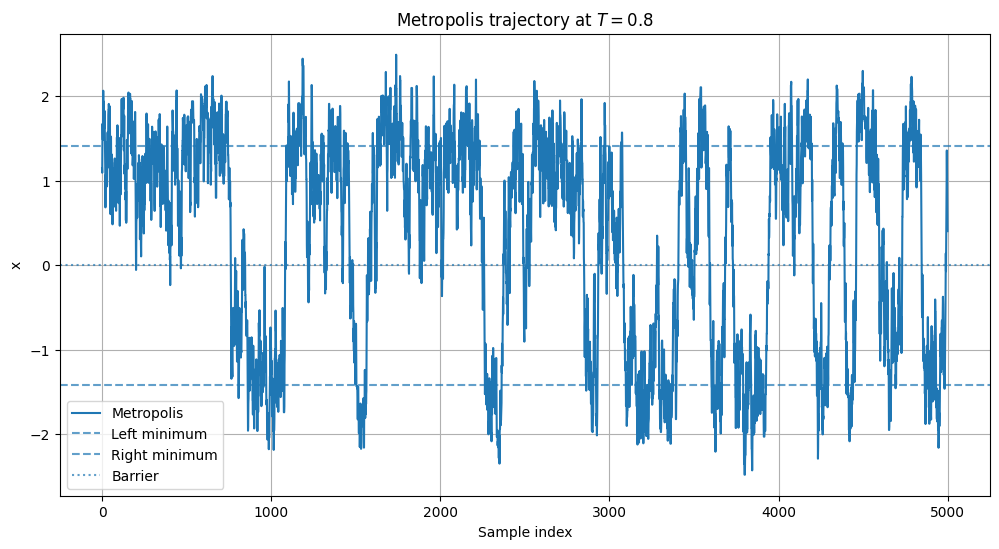

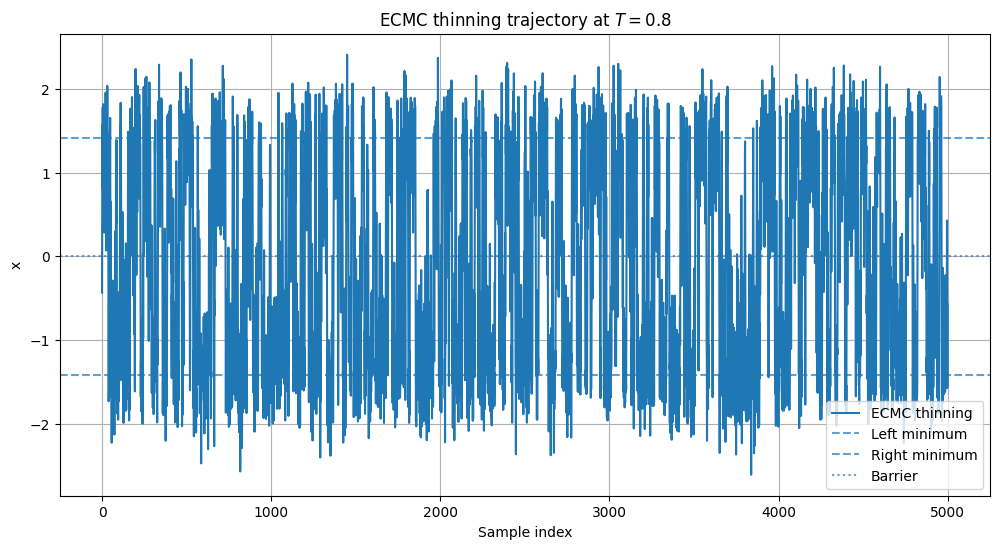

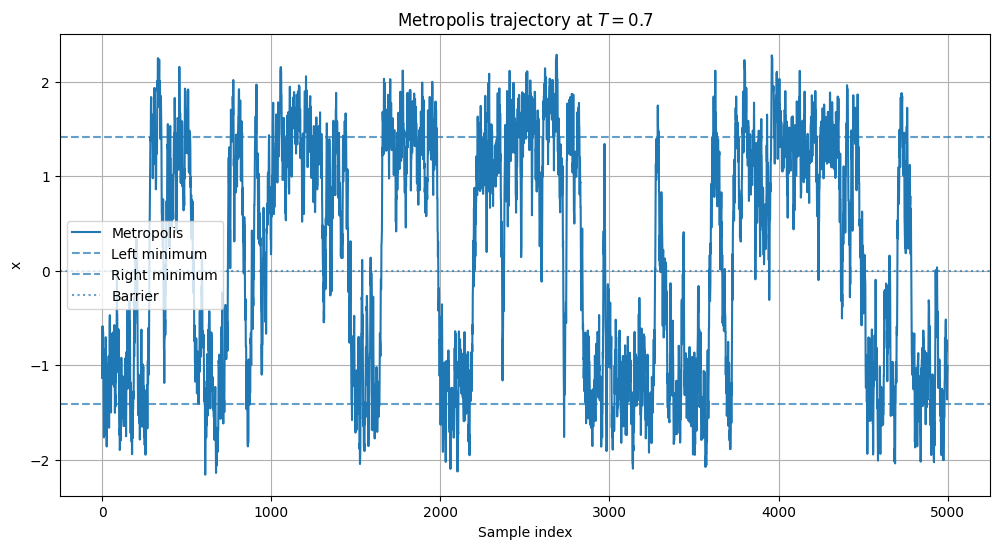

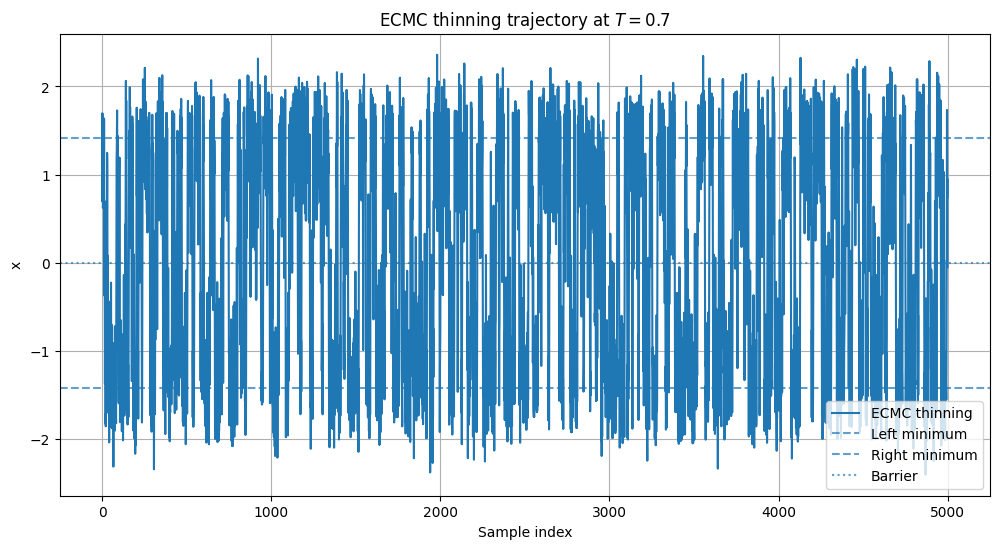

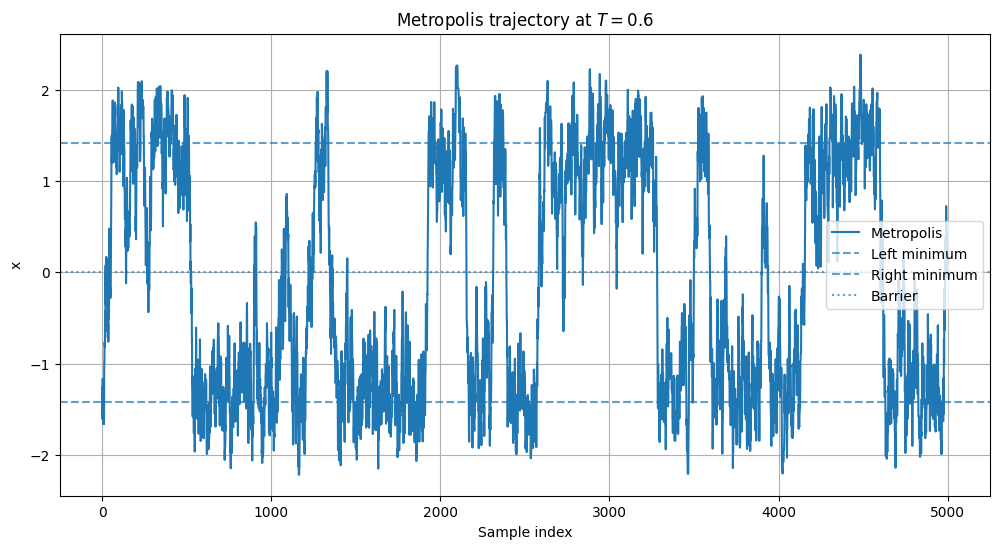

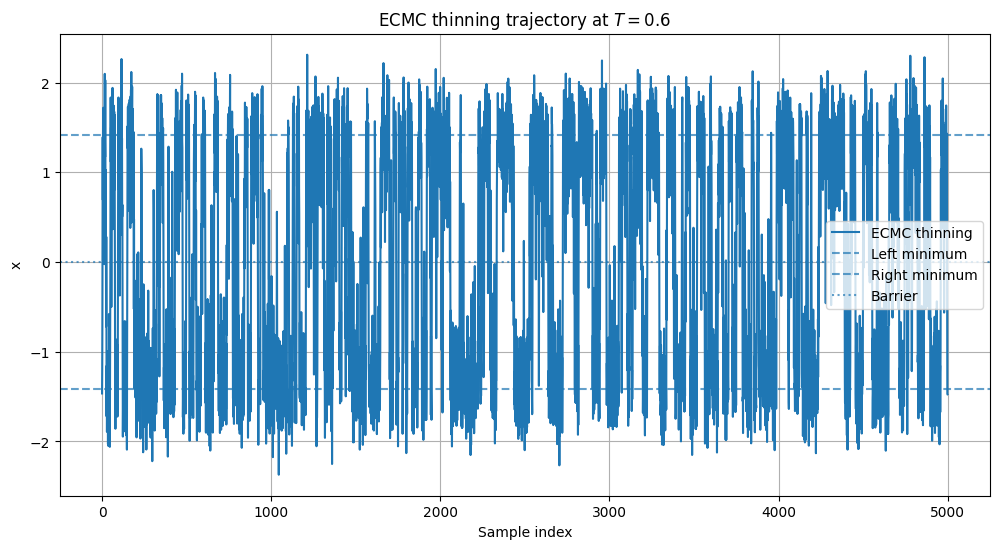

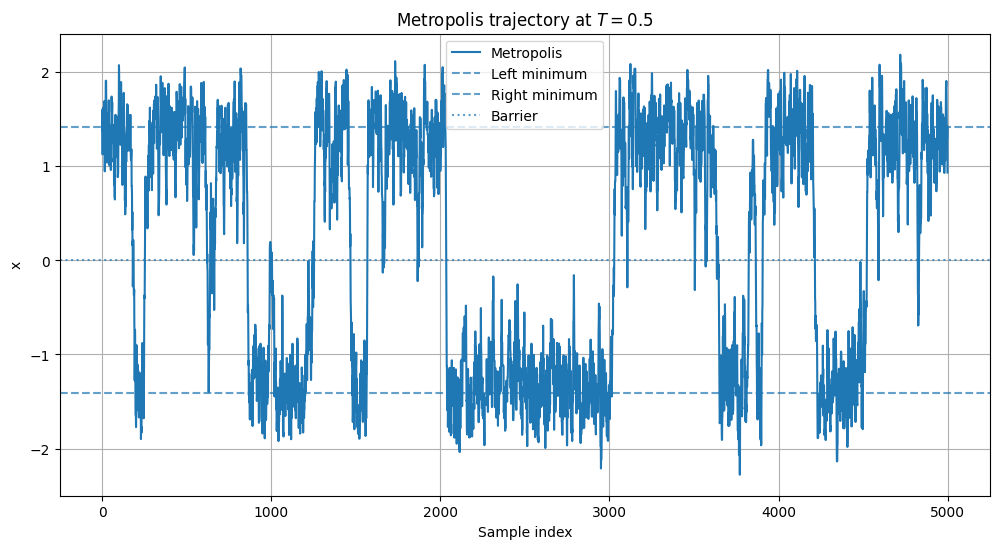

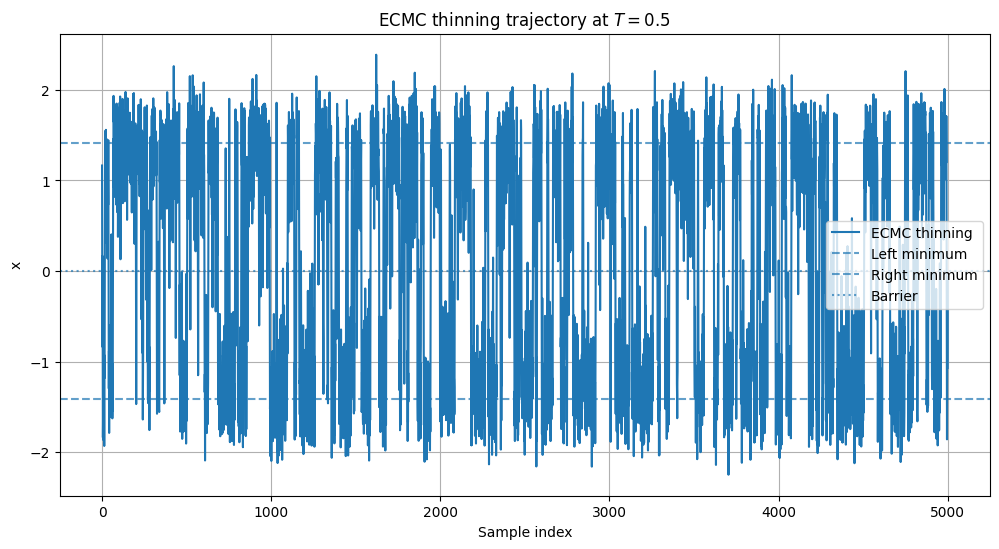

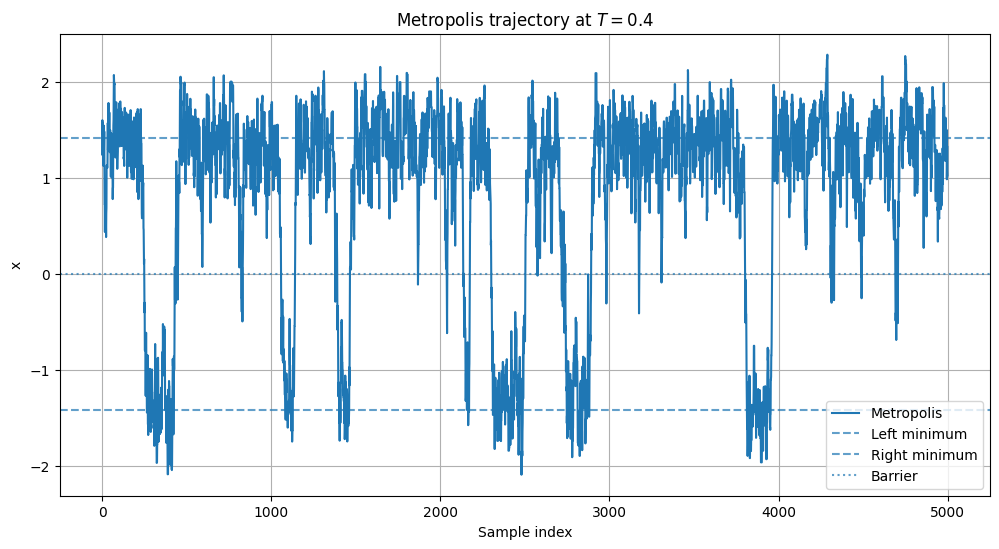

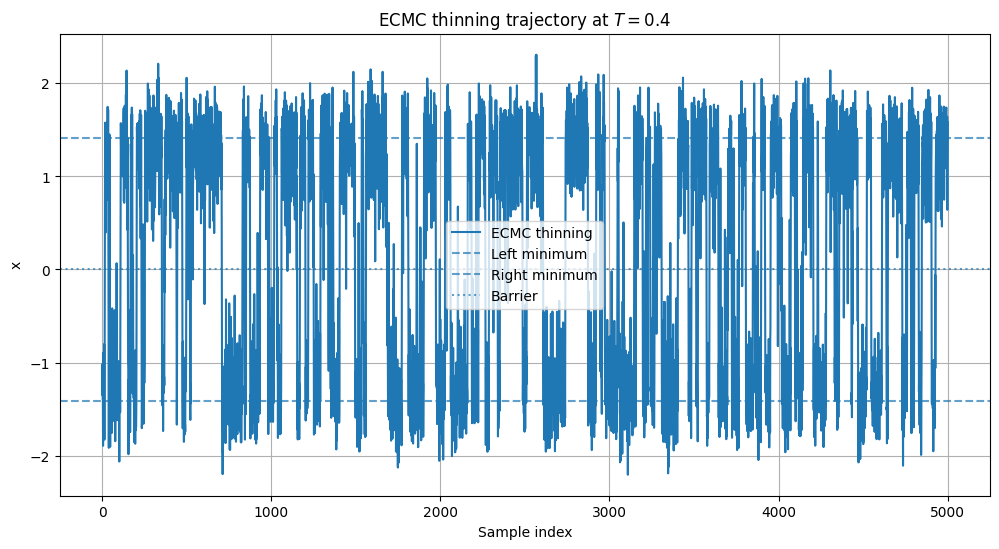

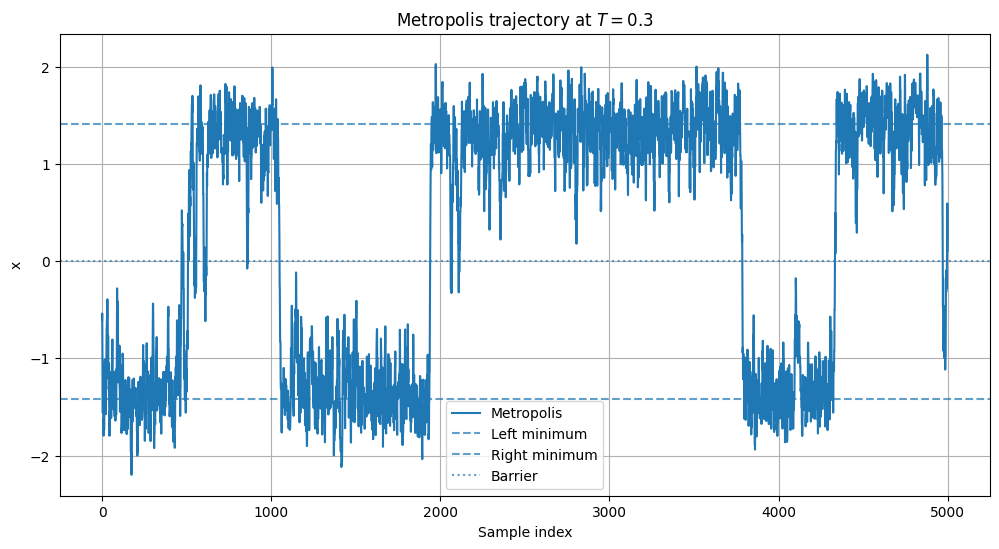

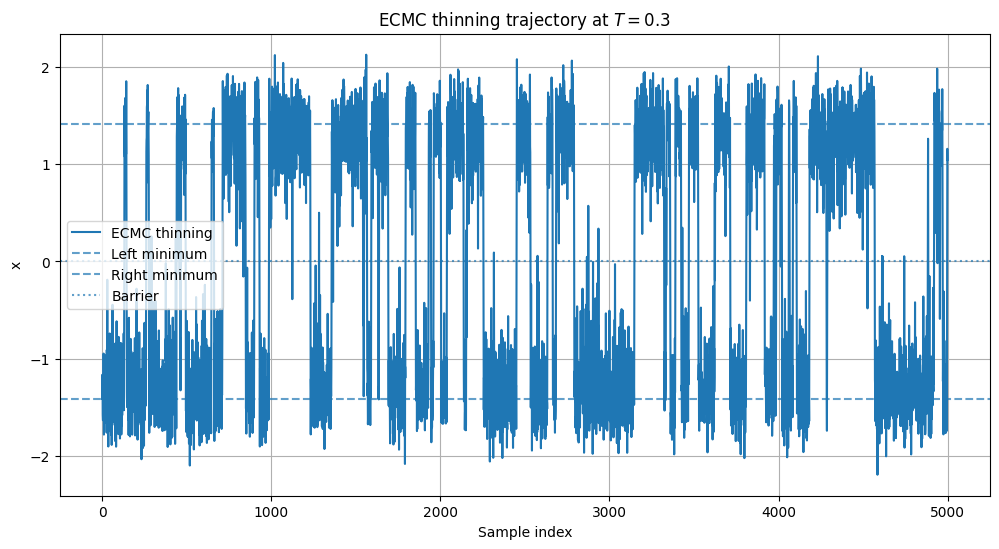

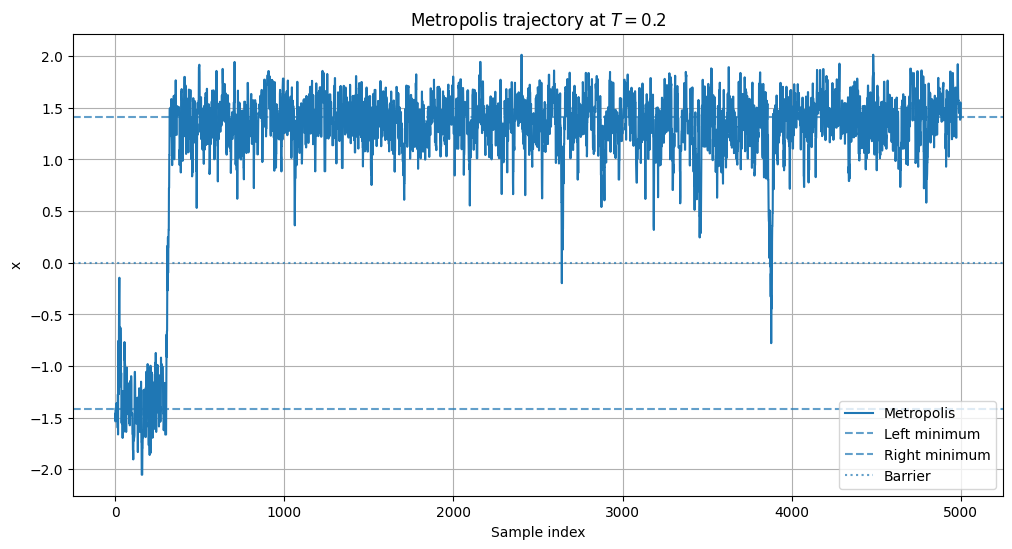

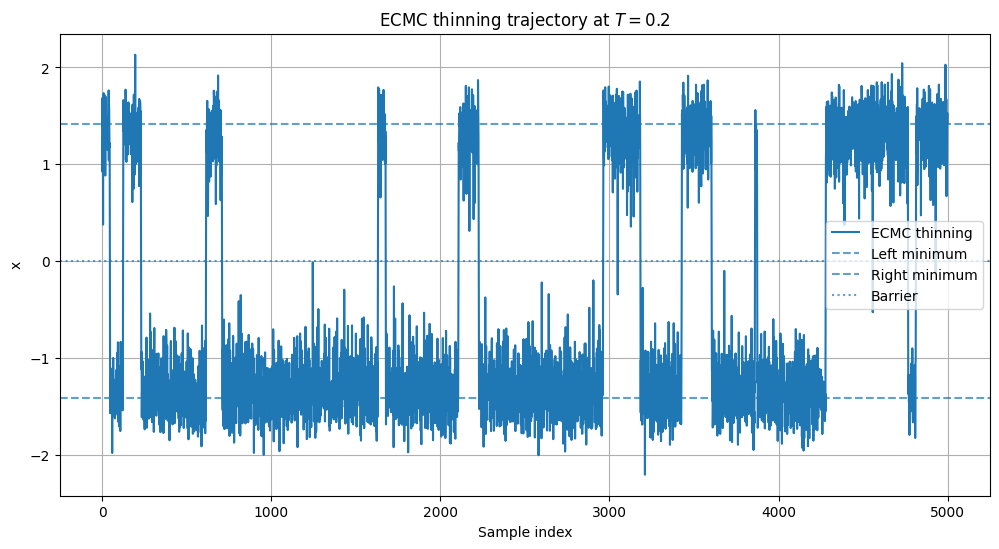

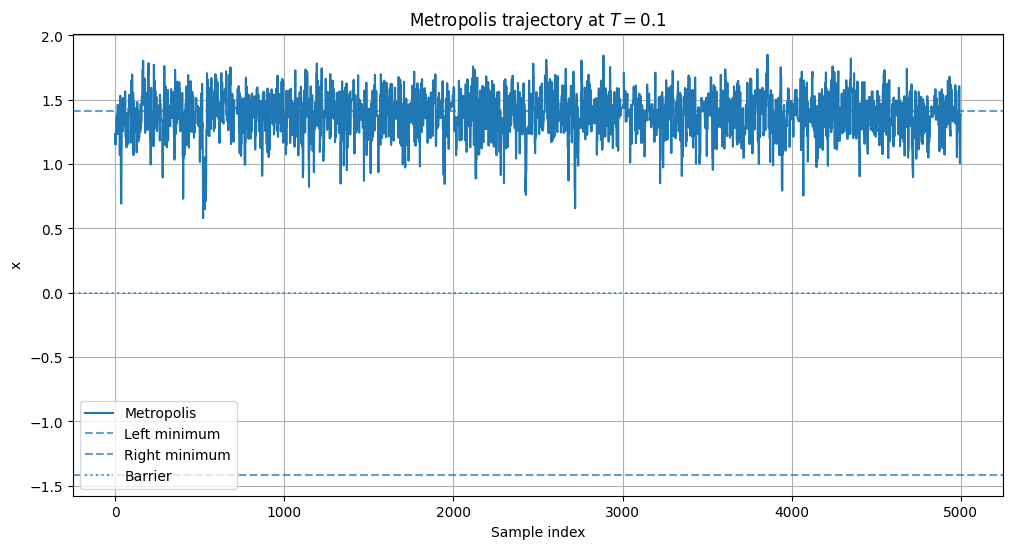

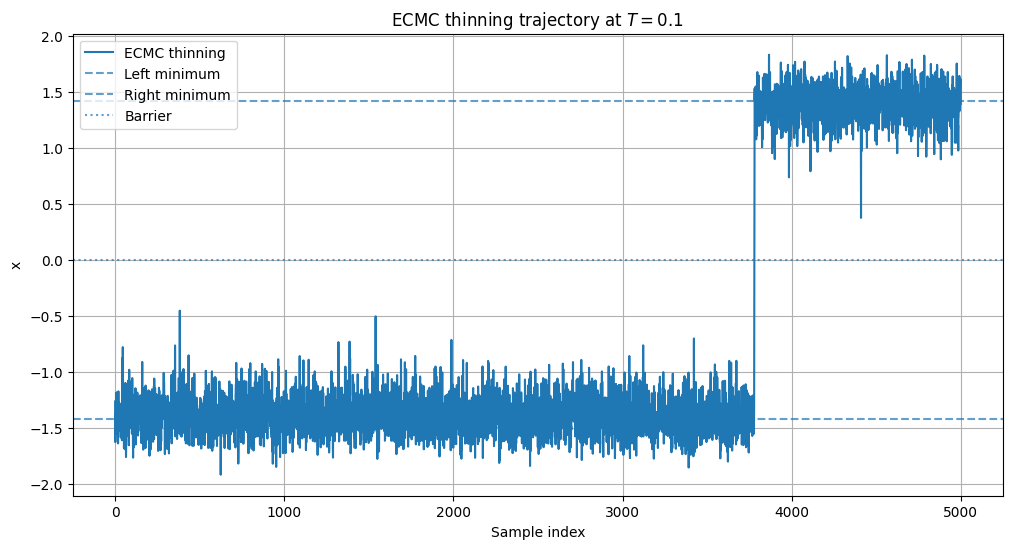

In [33]:
num_points_to_plot = 5000

for temp in temperatures:

    result = results[temp]

    plt.figure(figsize=(12, 6))

    plt.plot(
        result["metropolis_samples"][:num_points_to_plot],
        label="Metropolis"
    )

    plt.axhline(left_minimum, linestyle="--", alpha=0.7, label="Left minimum")
    plt.axhline(right_minimum, linestyle="--", alpha=0.7, label="Right minimum")
    plt.axhline(barrier_position, linestyle=":", alpha=0.7, label="Barrier")

    plt.xlabel("Sample index")
    plt.ylabel("x")
    plt.title(fr"Metropolis trajectory at $T={temp}$")
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 6))

    plt.plot(
        result["ecmc_samples"][:num_points_to_plot],
        label="ECMC thinning"
    )

    plt.axhline(left_minimum, linestyle="--", alpha=0.7, label="Left minimum")
    plt.axhline(right_minimum, linestyle="--", alpha=0.7, label="Right minimum")
    plt.axhline(barrier_position, linestyle=":", alpha=0.7, label="Barrier")

    plt.xlabel("Sample index")
    plt.ylabel("x")
    plt.title(fr"ECMC thinning trajectory at $T={temp}$")
    plt.grid()
    plt.legend()
    plt.show()

### Tempering Framework

In [34]:
def partition_function_trapezoid(beta, potential_func, x_grid):
    """
    Approximate the partition function using the trapezoidal rule.

    Args:
        beta (float): The inverse temperature.
        potential_func (callable): The potential energy function.
        x_grid (np.ndarray): Grid used for numerical integration.

    Returns:
        float: The approximate partition function.
    """
    unnormalised_density = np.exp(
        -beta * potential_func(x_grid)
    )

    partition_value = np.trapezoid(
        unnormalised_density,
        x_grid
    )

    return partition_value

In [35]:
tempering_temperatures = np.array(temperatures, dtype=float)
tempering_betas = 1.0 / tempering_temperatures

x_grid_tempering = np.linspace(-5, 5, 20_001)

partition_functions = np.array([
    partition_function_trapezoid(
        beta=beta,
        potential_func=double_potential,
        x_grid=x_grid_tempering
    )
    for beta in tempering_betas
])

tempering_log_weights = -np.log(partition_functions)

marginal_check = (
    partition_functions
    * np.exp(tempering_log_weights)
)

In [36]:
weights_df = pd.DataFrame({
    "Temperature": tempering_temperatures,
    "Beta": tempering_betas,
    "Z(beta)": partition_functions,
    "g(beta)": tempering_log_weights,
    "Marginal Check": marginal_check
})

print(weights_df.to_string(index=False))

 Temperature      Beta      Z(beta)   g(beta)  Marginal Check
         1.2  0.833333     6.908404 -1.932739             1.0
         1.0  1.000000     7.587482 -2.026500             1.0
         0.8  1.250000     8.832934 -2.178487             1.0
         0.7  1.428571     9.911448 -2.293690             1.0
         0.6  1.666667    11.639229 -2.454381             1.0
         0.5  2.000000    14.743640 -2.690812             1.0
         0.4  2.500000    21.453897 -3.065906             1.0
         0.3  3.333333    41.782270 -3.732472             1.0
         0.2  5.000000   175.058853 -5.165122             1.0
         0.1 10.000000 17834.508537 -9.788891             1.0


In [37]:
def propose_temperature_index(current_index, num_temperatures, rng):
    """
    Propose a new temperature index for simulated tempering.

    Args:
        current_index (int): The current temperature index.
        num_temperatures (int): The total number of temperatures.
        rng (numpy.random.Generator): A random number generator.

    Returns:
        int: The proposed temperature index.
    """
    if current_index == 0:
        return 1

    if current_index == num_temperatures - 1:
        return num_temperatures - 2

    return current_index + rng.choice([-1, 1])

In [38]:
def temperature_proposal_probability(current_index, proposed_index, num_temperatures):
    """
    Calculate the probability of proposing a new temperature index for simulated tempering.

    Args:
        current_index (int): The current temperature index.
        proposed_index (int): The proposed temperature index.
        num_temperatures (int): The total number of temperatures.

    Returns:
        float: The probability of proposing the new temperature index.
    """
    if abs(proposed_index - current_index) != 1:
        return 0.0

    if current_index == 0:
        return 1.0

    if current_index == num_temperatures - 1:
        return 1.0

    return 0.5

In [39]:
def simulated_tempering_temperature_step(x_current, current_index, betas, log_weights, potential_func, rng):
    """
    Perform a single temperature step in simulated tempering.

    Args:
        x_current (float): The current position in the state space.
        current_index (int): The current temperature index.
        betas (list): The list of inverse temperatures.
        log_weights (list): The log weights for each temperature.
        potential_func (callable): The potential function.
        rng (numpy.random.Generator): A random number generator.

    Returns:
        tuple: The new temperature index, a boolean indicating if the move was accepted, and the acceptance probability.
    """
    num_temperatures = len(betas)

    proposed_index = propose_temperature_index(
        current_index,
        num_temperatures,
        rng
    )

    q_forward = temperature_proposal_probability(
        current_index,
        proposed_index,
        num_temperatures
    )

    q_reverse = temperature_proposal_probability(
        proposed_index,
        current_index,
        num_temperatures
    )

    beta_current = betas[current_index]
    beta_proposed = betas[proposed_index]

    g_current = log_weights[current_index]
    g_proposed = log_weights[proposed_index]

    energy = potential_func(x_current)

    log_acceptance_ratio = (
        -(beta_proposed - beta_current) * energy
        + (g_proposed - g_current)
        + np.log(q_reverse / q_forward)
    )

    acceptance_probability = np.exp(
        min(0.0, log_acceptance_ratio)
    )

    if rng.random() < acceptance_probability:
        return proposed_index, True, acceptance_probability

    return current_index, False, acceptance_probability

In [40]:
def simulated_tempering_step(x_current, current_index, betas, log_weights, metropolis_proposal_width, potential_func, rng):
    """
    Perform a single step of simulated tempering, which includes both a position update and a temperature update.

    Args:
        x_current (float): The current position.
        current_index (int): The index of the current temperature.
        betas (numpy.ndarray): The inverse temperatures.
        log_weights (numpy.ndarray): The log weights for each temperature.
        metropolis_proposal_width (float): The width of the Metropolis proposal distribution.
        potential_func (callable): The potential energy function.

        rng (numpy.random.Generator): The random number generator.

    Returns:
        tuple: A tuple containing the new position, new temperature index, and acceptance information.
    """
    current_temperature = 1.0 / betas[current_index]

    # Update the position at the current temperature.
    x_new, position_accepted = metropolis_step(
        x_current=x_current,
        proposal_width=metropolis_proposal_width,
        temperature=current_temperature,
        potential_func=potential_func,
        rng=rng
    )

    # Attempt to update the temperature at the new position.
    new_index, temperature_accepted, temperature_acceptance_probability = (
        simulated_tempering_temperature_step(
            x_current=x_new,
            current_index=current_index,
            betas=betas,
            log_weights=log_weights,
            potential_func=potential_func,
            rng=rng
        )
    )

    return x_new, new_index, position_accepted, temperature_accepted, temperature_acceptance_probability

In [41]:
def run_simulated_tempering(initial_x, initial_index, num_steps, betas, log_weights, metropolis_proposal_width, potential_func, rng):
    """
    Run reversible simulated tempering.

    Args:
        initial_x (float): Initial position.
        initial_index (int): Initial inverse-temperature index.
        num_steps (int): Number of simulated-tempering steps.
        betas (np.ndarray): Available inverse temperatures.
        log_weights (np.ndarray): Precomputed tempering log weights.
        metropolis_proposal_width (float): Width of the position proposal.
        potential_func (callable): Potential energy function.
        rng (numpy.random.Generator): Random number generator.

    Returns:
        dict: Position and temperature trajectories and acceptance rates.
    """
    current_x = initial_x
    current_index = initial_index

    position_trajectory = np.empty(num_steps)
    temperature_index_trajectory = np.empty(
        num_steps,
        dtype=int
    )

    accepted_position_moves = 0
    accepted_temperature_moves = 0

    for step in range(num_steps):

        (
            current_x,
            current_index,
            position_accepted,
            temperature_accepted,
            _
        ) = simulated_tempering_step(
            x_current=current_x,
            current_index=current_index,
            betas=betas,
            log_weights=log_weights,
            metropolis_proposal_width=metropolis_proposal_width,
            potential_func=potential_func,
            rng=rng
        )

        position_trajectory[step] = current_x
        temperature_index_trajectory[step] = current_index

        if position_accepted:
            accepted_position_moves += 1

        if temperature_accepted:
            accepted_temperature_moves += 1

    position_acceptance_rate = (
        accepted_position_moves / num_steps
    )

    temperature_acceptance_rate = (
        accepted_temperature_moves / num_steps
    )

    return {
        "position_trajectory": position_trajectory,
        "temperature_index_trajectory": temperature_index_trajectory,
        "position_acceptance_rate": position_acceptance_rate,
        "temperature_acceptance_rate": temperature_acceptance_rate
    }

In [42]:
tempering_rng = np.random.default_rng(seed=42)

num_burn_in_steps_tempering = 1_000
num_tempering_samples = 10**7
num_tempering_steps = num_burn_in_steps_tempering + num_tempering_samples

initial_temperature_index = len(tempering_betas) - 1

tempering_results = run_simulated_tempering(
    left_minimum, initial_temperature_index, num_tempering_steps, tempering_betas,
    tempering_log_weights, 1.0, double_potential, tempering_rng
)

tempering_position_samples = tempering_results["position_trajectory"][num_burn_in_steps_tempering:]
tempering_temperature_indices = tempering_results["temperature_index_trajectory"][num_burn_in_steps_tempering:]
tempering_temperature_samples = tempering_temperatures[tempering_temperature_indices]

print(f"Position acceptance rate: {100 * tempering_results['position_acceptance_rate']:.2f}%")
print(f"Temperature acceptance rate: {100 * tempering_results['temperature_acceptance_rate']:.2f}%")
print(f"Number of temperatures visited: {len(np.unique(tempering_temperature_indices))}")
print("Temperatures visited:", np.unique(tempering_temperature_samples))

Position acceptance rate: 75.03%
Temperature acceptance rate: 85.22%
Number of temperatures visited: 10
Temperatures visited: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 1.  1.2]


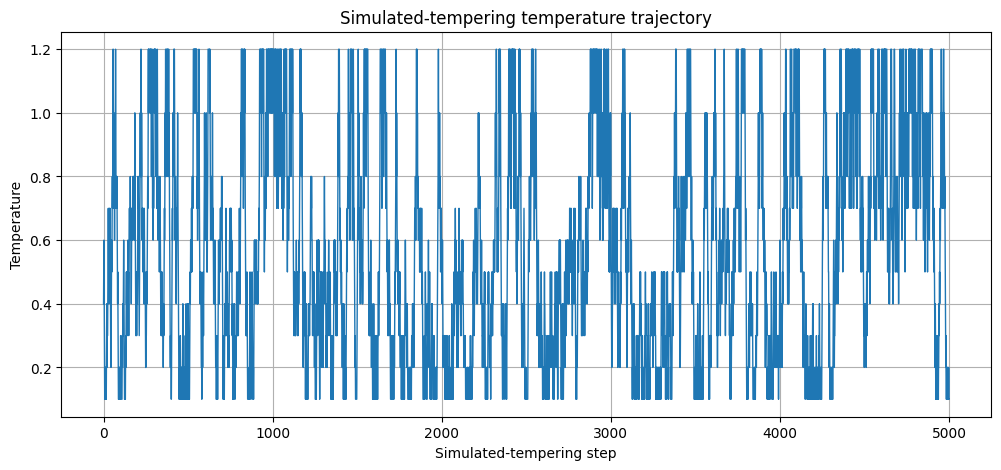

In [43]:
num_temperature_steps_to_plot = 5_000

plt.figure(figsize=(12, 5))
plt.plot(tempering_temperature_samples[:num_temperature_steps_to_plot], linewidth=1)
plt.xlabel("Simulated-tempering step")
plt.ylabel("Temperature")
plt.title("Simulated-tempering temperature trajectory")
plt.grid()
plt.show()

In [44]:
temperature_visit_counts = np.bincount(tempering_temperature_indices, minlength=len(tempering_temperatures))
temperature_visit_proportions = temperature_visit_counts / len(tempering_temperature_indices)
expected_temperature_proportion = 1.0 / len(tempering_temperatures)

temperature_visit_df = pd.DataFrame({
    "Temperature": tempering_temperatures,
    "Visits": temperature_visit_counts,
    "Visit Proportion": temperature_visit_proportions,
    "Expected Proportion": expected_temperature_proportion
})

print(temperature_visit_df.to_string(index=False))

 Temperature  Visits  Visit Proportion  Expected Proportion
         1.2 1003200          0.100320                  0.1
         1.0 1001657          0.100166                  0.1
         0.8  999860          0.099986                  0.1
         0.7  997518          0.099752                  0.1
         0.6  998605          0.099861                  0.1
         0.5 1000312          0.100031                  0.1
         0.4  999255          0.099926                  0.1
         0.3  999646          0.099965                  0.1
         0.2  999842          0.099984                  0.1
         0.1 1000105          0.100011                  0.1


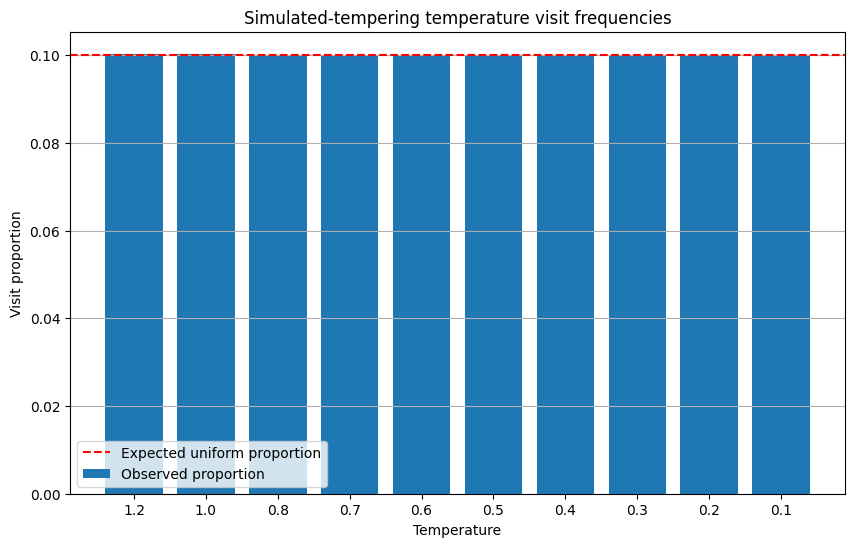

In [45]:
temperature_positions = np.arange(len(tempering_temperatures))

plt.figure(figsize=(10, 6))
plt.bar(temperature_positions, temperature_visit_proportions, label="Observed proportion")
plt.axhline(expected_temperature_proportion, color="red", linestyle="--", label="Expected uniform proportion")
plt.xticks(temperature_positions, tempering_temperatures)
plt.xlabel("Temperature")
plt.ylabel("Visit proportion")
plt.title("Simulated-tempering temperature visit frequencies")
plt.grid(axis="y")
plt.legend()
plt.show()

In [46]:
maximum_temperature_deviation = np.max(np.abs(temperature_visit_proportions - expected_temperature_proportion))

print(f"Expected proportion at each temperature: {expected_temperature_proportion:.4f}")
print(f"Maximum absolute deviation from uniformity: {maximum_temperature_deviation:.4f}")

Expected proportion at each temperature: 0.1000
Maximum absolute deviation from uniformity: 0.0003


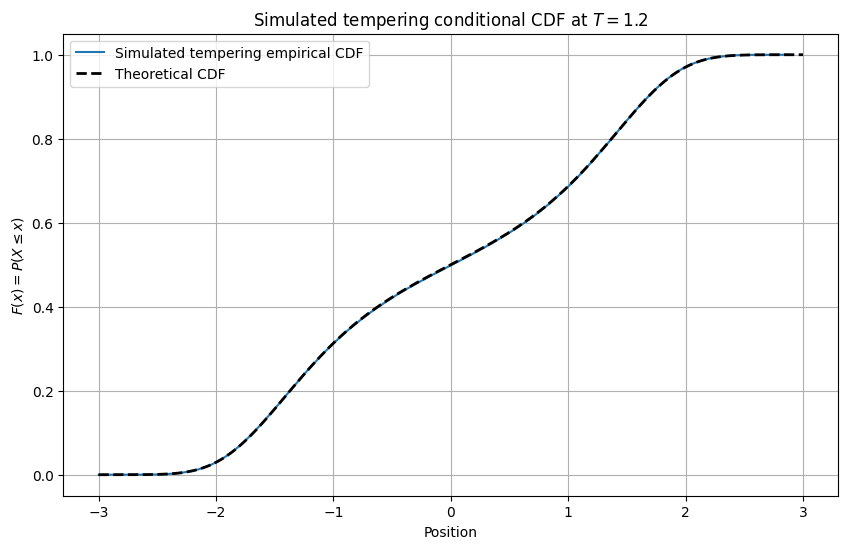

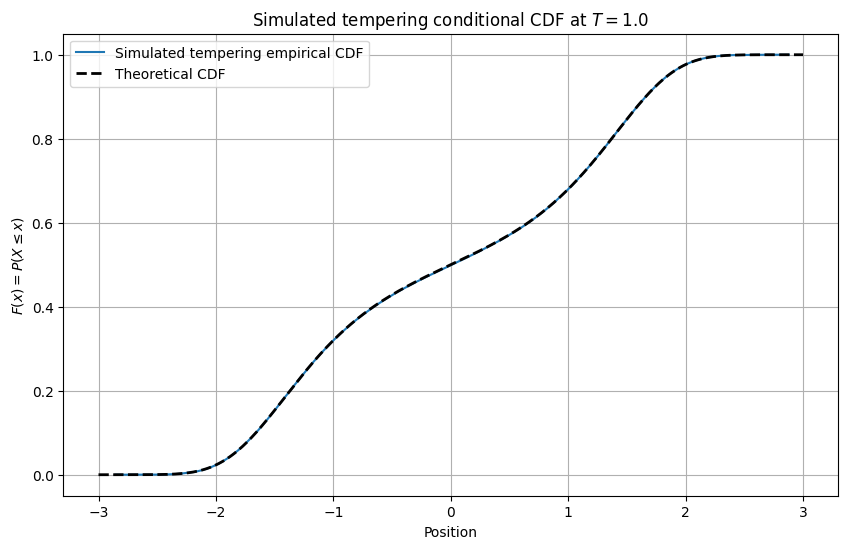

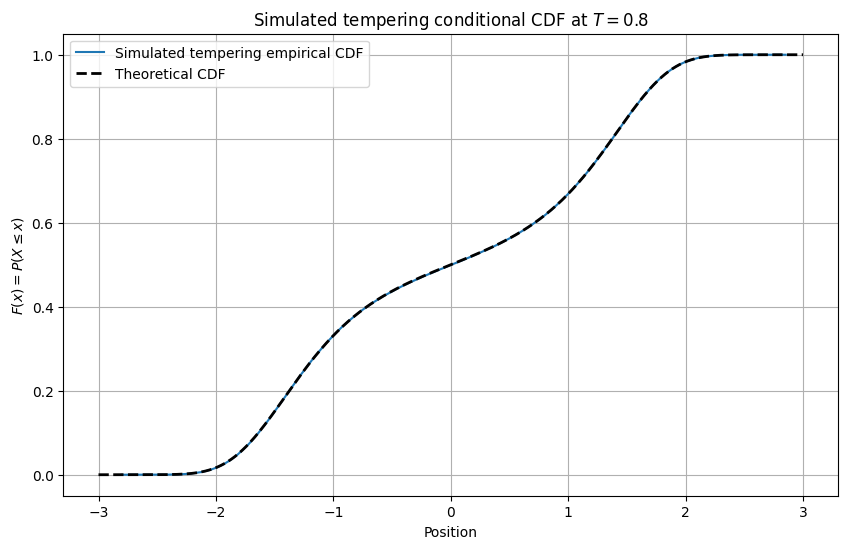

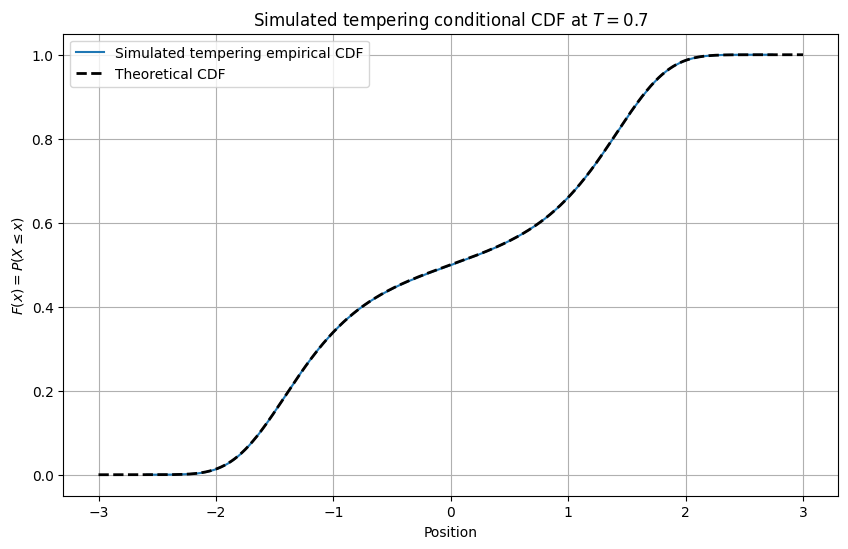

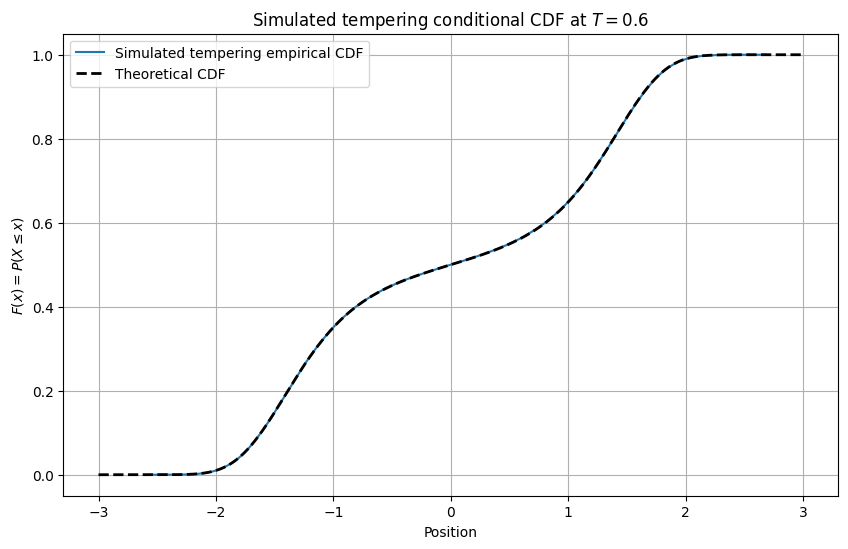

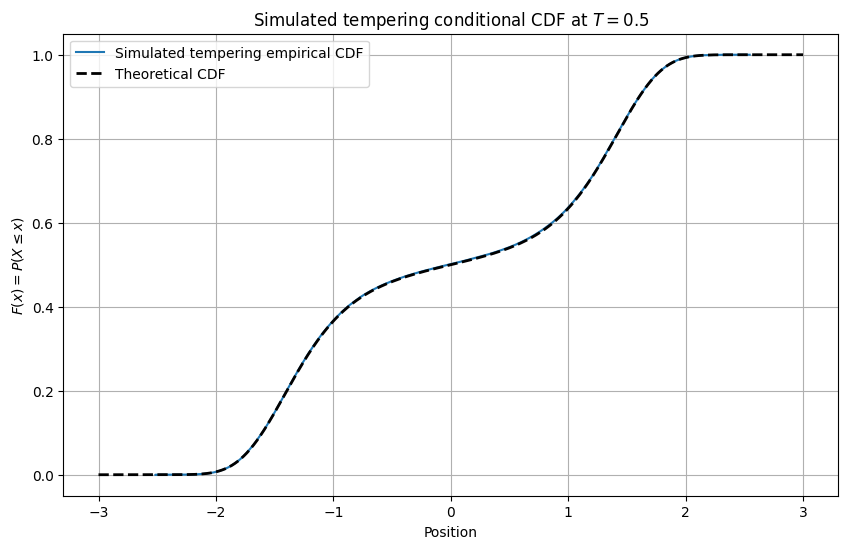

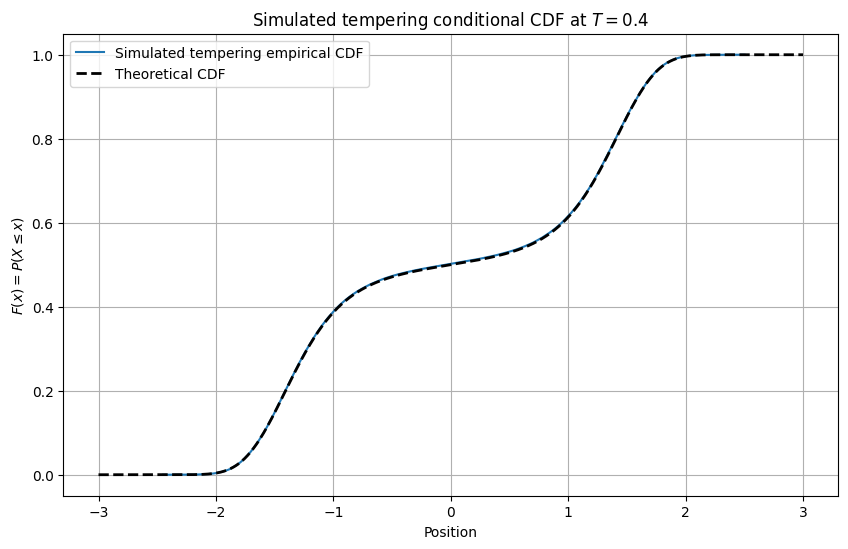

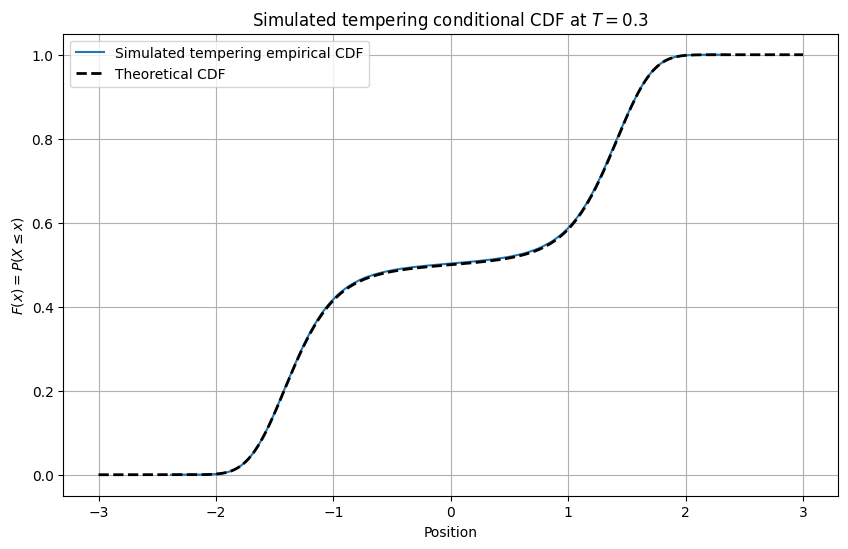

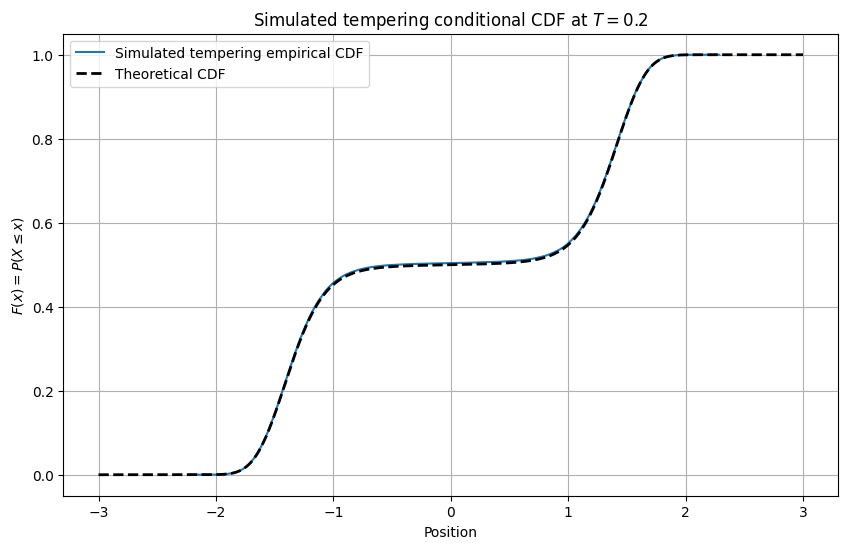

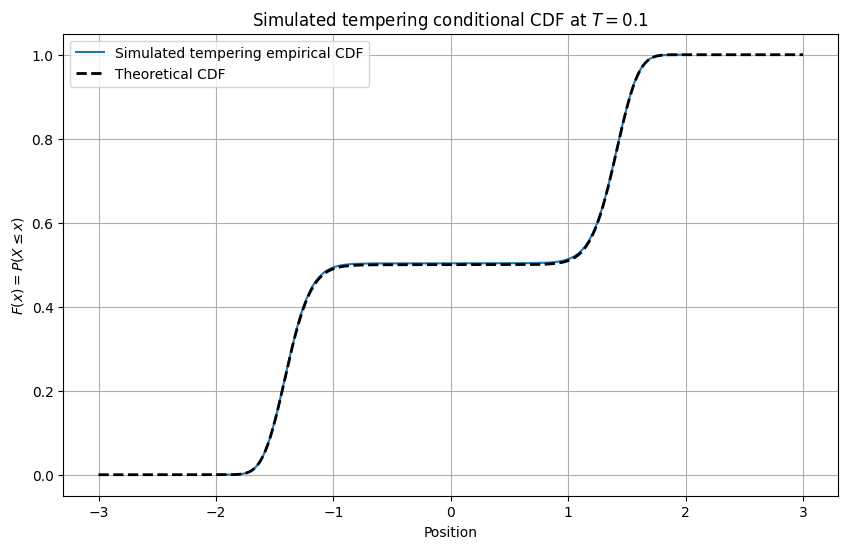

In [47]:
tempering_positions_by_temperature = {
    temperature: tempering_position_samples[
        tempering_temperature_indices == temperature_index
    ]
    for temperature_index, temperature in enumerate(tempering_temperatures)
}

x_grid_tempering_cdf = np.linspace(-3, 3, 4000)

for temperature, positions in tempering_positions_by_temperature.items():

    empirical_x_cdf, empirical_y_cdf = empirical_cdf(positions)

    theoretical_y_cdf = theoretical_cdf(
        x_grid_tempering_cdf,
        double_potential,
        temperature
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        empirical_x_cdf,
        empirical_y_cdf,
        label="Simulated tempering empirical CDF"
    )

    plt.plot(
        x_grid_tempering_cdf,
        theoretical_y_cdf,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Theoretical CDF"
    )

    plt.xlabel("Position")
    plt.ylabel(r"$F(x)=P(X\leq x)$")
    plt.title(
        fr"Simulated tempering conditional CDF at $T={temperature}$"
    )
    plt.grid()
    plt.legend()
    plt.show()

In [48]:
well_balance_records = []

for temperature, positions in tempering_positions_by_temperature.items():

    left_proportion = np.mean(positions < 0)
    right_proportion = np.mean(positions > 0)

    well_balance_records.append({
        "Temperature": temperature,
        "Number of Samples": len(positions),
        "Left-well Proportion": left_proportion,
        "Right-well Proportion": right_proportion
    })

well_balance_df = pd.DataFrame(well_balance_records)

print(well_balance_df.to_string(index=False))

overall_left_proportion = np.mean(tempering_position_samples < 0)
overall_right_proportion = np.mean(tempering_position_samples > 0)

print(f"Overall left-well proportion: {overall_left_proportion:.4f}")
print(f"Overall right-well proportion: {overall_right_proportion:.4f}")

well_labels = np.sign(tempering_position_samples)

well_switches = np.sum(
    well_labels[1:] != well_labels[:-1]
)

print(f"Number of well switches: {well_switches}")

 Temperature  Number of Samples  Left-well Proportion  Right-well Proportion
         1.2            1003200              0.498657               0.501343
         1.0            1001657              0.498889               0.501111
         0.8             999860              0.499287               0.500713
         0.7             997518              0.499095               0.500905
         0.6             998605              0.500147               0.499853
         0.5            1000312              0.501479               0.498521
         0.4             999255              0.502081               0.497919
         0.3             999646              0.502885               0.497115
         0.2             999842              0.503883               0.496117
         0.1            1000105              0.503443               0.496557
Overall left-well proportion: 0.5010
Overall right-well proportion: 0.4990
Number of well switches: 184505


## Discrete Irreversible Simulated Tempering

In [49]:
def irreversible_temperature_proposal_probability(current_index, proposed_index, epsilon, delta, num_temperatures):
    """
    Calculate the probability of proposing a new temperature index for irreversible simulated tempering.

    Args:
        current_index (int): The current temperature index.
        proposed_index (int): The proposed temperature index.
        epsilon (int): The lifting variable, either +1 or -1.
    delta (float): The strength of the irreversible bias.
        num_temperatures (int): The total number of temperatures.


    Raises:
        ValueError: If epsilon is not either +1 or -1.
        ValueError: If delta is not in the range [0, 1).

    Returns:
        float: The probability of proposing the new temperature index.
    """             
    if epsilon not in (-1, 1):
        raise ValueError("epsilon must be either +1 or -1.")

    if not 0 <= delta < 1:
        raise ValueError("delta must satisfy 0 <= delta < 1.")

    if proposed_index < 0 or proposed_index >= num_temperatures:
        return 0.0

    if abs(proposed_index - current_index) != 1:
        return 0.0

    if current_index == 0 or current_index == num_temperatures - 1:
        return 1.0

    if proposed_index == current_index + 1:
        return (1.0 + delta * epsilon) / 2.0

    return (1.0 - delta * epsilon) / 2.0

In [50]:
def propose_irreversible_temperature_index(current_index, epsilon, delta, num_temperatures, rng):
    """
    Propose a new temperature index for irreversible simulated tempering.

    Args:
        current_index (int): The current temperature index.
        epsilon (int): The lifting variable, either +1 or -1.
        delta (float): The strength of the irreversible bias.
        num_temperatures (int): The total number of temperatures.
        rng (numpy.random.Generator): The random number generator.

    Returns:
        int: The proposed temperature index.
    """
    possible_indices = [
        index for index in (current_index - 1, current_index + 1)
        if 0 <= index < num_temperatures
    ]

    proposal_probabilities = [
        irreversible_temperature_proposal_probability(
            current_index,
            proposed_index,
            epsilon,
            delta,
            num_temperatures
        )
        for proposed_index in possible_indices
    ]

    return rng.choice(possible_indices, p=proposal_probabilities)

In [51]:
def irreversible_temperature_acceptance_probability(x_current, current_index, proposed_index, epsilon, delta, betas, log_weights, potential_func):
    """
    Calculate the acceptance probability for an irreversible temperature step in simulated tempering.

    Args:
        x_current (float): The current state.
        current_index (int): The current temperature index.
        proposed_index (int): The proposed temperature index.
        epsilon (int): The lifting variable, either +1 or -1.
        delta (float): The strength of the irreversible bias.
        betas (list): The temperature schedule.
        log_weights (list): The log weights for each temperature.
        potential_func (callable): The potential function.

    Returns:
        float: The acceptance probability.
    """
    num_temperatures = len(betas)

    q_forward = irreversible_temperature_proposal_probability(current_index, proposed_index, epsilon, delta, num_temperatures)
    q_skew_reverse = irreversible_temperature_proposal_probability(proposed_index, current_index, -epsilon, delta, num_temperatures)

    beta_current = betas[current_index]
    beta_proposed = betas[proposed_index]

    g_current = log_weights[current_index]
    g_proposed = log_weights[proposed_index]

    energy = potential_func(x_current)

    log_acceptance_ratio = (
        -(beta_proposed - beta_current) * energy
        + (g_proposed - g_current)
        + np.log(q_skew_reverse / q_forward)
    )

    return np.exp(min(0.0, log_acceptance_ratio))

In [52]:
def irreversible_temperature_move_probability(x_current, current_index, epsilon, delta, betas, log_weights, potential_func):
    """
    Calculate the overall move probability for an irreversible temperature step in simulated tempering.

    Args:
        x_current (float): The current state.
        current_index (int): The index of the current temperature.
        epsilon (int): The lifting variable, either +1 or -1.
        delta (float): The strength of the irreversible bias.
        betas (list): The temperature schedule.
        log_weights (list): The log weights for each temperature.
        potential_func (callable): The potential function.

    Returns:
        float: The move probability.
    """
    num_temperatures = len(betas)

    possible_indices = [
        index for index in (current_index - 1, current_index + 1)
        if 0 <= index < num_temperatures
    ]

    move_probability = 0.0

    for proposed_index in possible_indices:
        proposal_probability = irreversible_temperature_proposal_probability(
            current_index,
            proposed_index,
            epsilon,
            delta,
            num_temperatures
        )

        acceptance_probability = irreversible_temperature_acceptance_probability(
            x_current,
            current_index,
            proposed_index,
            epsilon,
            delta,
            betas,
            log_weights,
            potential_func
        )

        move_probability += proposal_probability * acceptance_probability

    return move_probability

In [53]:
def irreversible_temperature_flip_numerator(x_current, current_index, epsilon, delta, betas, log_weights, potential_func):
    """
    Calculate the numerator for the acceptance probability of an irreversible temperature flip.

    Args:
        x_current (float): The current state.
        current_index (int): The index of the current temperature.
        epsilon (int): The lifting variable, either +1 or -1.
        delta (float): The strength of the irreversible bias.
        betas (list): The temperature schedule.
        log_weights (list): The log weights for each temperature.
        potential_func (callable): The potential function.

    Returns:
        float: The numerator for the acceptance probability.
    """ 
    current_move_probability = irreversible_temperature_move_probability(
        x_current,
        current_index,
        epsilon,
        delta,
        betas,
        log_weights,
        potential_func
    )

    opposite_move_probability = irreversible_temperature_move_probability(
        x_current,
        current_index,
        -epsilon,
        delta,
        betas,
        log_weights,
        potential_func
    )

    return max(0.0, opposite_move_probability - current_move_probability)

In [54]:
def irreversible_temperature_flip_probability(x_current, current_index, epsilon, delta, betas, log_weights, potential_func):
    """
    Calculate the probability of an irreversible temperature flip in simulated tempering.

    Args:
        x_current (float): The current state.
        current_index (int): The index of the current temperature.
        epsilon (int): The lifting variable, either +1 or -1.
        delta (float): The strength of the irreversible bias.
        betas (list): The temperature schedule.
        log_weights (list): The log weights for each temperature.
        potential_func (callable): The potential function.

    Returns:
        float: The probability of the irreversible temperature flip.
    """
    move_probability = irreversible_temperature_move_probability(
        x_current,
        current_index,
        epsilon,
        delta,
        betas,
        log_weights,
        potential_func
    )

    rejection_probability = 1.0 - move_probability

    if rejection_probability == 0.0:
        return 0.0

    flip_numerator = irreversible_temperature_flip_numerator(
        x_current,
        current_index,
        epsilon,
        delta,
        betas,
        log_weights,
        potential_func
    )

    return flip_numerator / rejection_probability

In [55]:
def irreversible_simulated_tempering_temperature_step(x_current, current_index, epsilon, delta, betas, log_weights, potential_func, rng):
    """
    Perform a single step of irreversible simulated tempering.

    Args:
        x_current (float): The current state.
        current_index (int): The index of the current temperature.
        epsilon (int): The lifting variable, either +1 or -1.
        delta (float): The strength of the irreversible bias.
        betas (list): The temperature schedule.
        log_weights (list): The log weights for each temperature.
        potential_func (callable): The potential function.
        rng (numpy.random.Generator): The random number generator.

    Returns:
        tuple: A tuple containing the new temperature index, the updated epsilon, and acceptance/flip flags.
    """ 
    num_temperatures = len(betas)

    proposed_index = propose_irreversible_temperature_index(
        current_index,
        epsilon,
        delta,
        num_temperatures,
        rng
    )

    acceptance_probability = irreversible_temperature_acceptance_probability(
        x_current,
        current_index,
        proposed_index,
        epsilon,
        delta,
        betas,
        log_weights,
        potential_func
    )

    if rng.random() < acceptance_probability:
        return proposed_index, epsilon, True, False, acceptance_probability, 0.0

    flip_probability = irreversible_temperature_flip_probability(
        x_current,
        current_index,
        epsilon,
        delta,
        betas,
        log_weights,
        potential_func
    )

    if rng.random() < flip_probability:
        return current_index, -epsilon, False, True, acceptance_probability, flip_probability

    return current_index, epsilon, False, False, acceptance_probability, flip_probability

In [56]:
def irreversible_simulated_tempering_step(x_current, current_index, epsilon, delta, betas, log_weights, metropolis_proposal_width, potential_func, rng):
    """
    Perform a single step of irreversible simulated tempering.

    Args:
        x_current (float): The current state.
        current_index (int): The index of the current temperature.
        epsilon (int): The lifting variable, either +1 or -1.
        delta (float): The strength of the irreversible bias.
        betas (list): The temperatures.
        log_weights (list): The log weights for each temperature.
        metropolis_proposal_width (float): The width of the Metropolis proposal.
        potential_func (callable): The potential function.
        rng (numpy.random.Generator): The random number generator.

    Returns:
        tuple: A tuple containing the new state, new temperature index, new epsilon value, position acceptance status, temperature acceptance status, epsilon flip status, temperature acceptance probability, and epsilon flip probability.
    """
    current_temperature = 1.0 / betas[current_index]

    x_new, position_accepted = metropolis_step(
        x_current=x_current,
        proposal_width=metropolis_proposal_width,
        temperature=current_temperature,
        potential_func=potential_func,
        rng=rng
    )

    (
        new_index,
        new_epsilon,
        temperature_accepted,
        epsilon_flipped,
        temperature_acceptance_probability,
        epsilon_flip_probability
    ) = irreversible_simulated_tempering_temperature_step(
        x_new,
        current_index,
        epsilon,
        delta,
        betas,
        log_weights,
        potential_func,
        rng
    )

    return (
        x_new,
        new_index,
        new_epsilon,
        position_accepted,
        temperature_accepted,
        epsilon_flipped,
        temperature_acceptance_probability,
        epsilon_flip_probability
    )

In [57]:
def run_irreversible_simulated_tempering(initial_x, initial_index, initial_epsilon, delta, num_steps, betas, log_weights, metropolis_proposal_width, potential_func, rng):
    """
    Run irreversible simulated tempering.

    Args:
        initial_x (float): The initial state.
        initial_index (int): The initial temperature index.
        initial_epsilon (int): The initial epsilon value.
        delta (float): The strength of the irreversible bias.
        num_steps (int): The number of steps to run.
        betas (list): The temperatures.
        log_weights (list): The log weights for each temperature.
        metropolis_proposal_width (float): The width of the Metropolis proposal.
        potential_func (callable): The potential function.
        rng (numpy.random.Generator): The random number generator.

    Returns:
        dict: A dictionary containing the trajectories and acceptance rates.
    """
    current_x = initial_x
    current_index = initial_index
    current_epsilon = initial_epsilon

    position_trajectory = np.empty(num_steps)
    temperature_index_trajectory = np.empty(num_steps, dtype=int)
    epsilon_trajectory = np.empty(num_steps, dtype=int)

    accepted_position_moves = 0
    accepted_temperature_moves = 0
    epsilon_flips = 0

    for step in range(num_steps):
        (
            current_x,
            current_index,
            current_epsilon,
            position_accepted,
            temperature_accepted,
            epsilon_flipped,
            _,
            _
        ) = irreversible_simulated_tempering_step(
            current_x,
            current_index,
            current_epsilon,
            delta,
            betas,
            log_weights,
            metropolis_proposal_width,
            potential_func,
            rng
        )

        position_trajectory[step] = current_x
        temperature_index_trajectory[step] = current_index
        epsilon_trajectory[step] = current_epsilon

        if position_accepted:
            accepted_position_moves += 1

        if temperature_accepted:
            accepted_temperature_moves += 1

        if epsilon_flipped:
            epsilon_flips += 1

    return {
        "position_trajectory": position_trajectory,
        "temperature_index_trajectory": temperature_index_trajectory,
        "epsilon_trajectory": epsilon_trajectory,
        "position_acceptance_rate": accepted_position_moves / num_steps,
        "temperature_acceptance_rate": accepted_temperature_moves / num_steps,
        "epsilon_flip_rate": epsilon_flips / num_steps
    }

In [58]:
irreversible_rng = np.random.default_rng(seed=42)

irreversible_delta = 0.8
num_burn_in_steps_irreversible = 1_000
num_irreversible_samples = 10**7
num_irreversible_steps = num_burn_in_steps_irreversible + num_irreversible_samples

initial_irreversible_temperature_index = len(tempering_betas) - 1
initial_epsilon = -1

irreversible_tempering_results = run_irreversible_simulated_tempering(
    left_minimum,
    initial_irreversible_temperature_index,
    initial_epsilon,
    irreversible_delta,
    num_irreversible_steps,
    tempering_betas,
    tempering_log_weights,
    1.0,
    double_potential,
    irreversible_rng
)

irreversible_position_samples = irreversible_tempering_results["position_trajectory"][num_burn_in_steps_irreversible:]
irreversible_temperature_indices = irreversible_tempering_results["temperature_index_trajectory"][num_burn_in_steps_irreversible:]
irreversible_epsilon_samples = irreversible_tempering_results["epsilon_trajectory"][num_burn_in_steps_irreversible:]
irreversible_temperature_samples = tempering_temperatures[irreversible_temperature_indices]

print(f"Position acceptance rate: {100 * irreversible_tempering_results['position_acceptance_rate']:.2f}%")
print(f"Temperature acceptance rate: {100 * irreversible_tempering_results['temperature_acceptance_rate']:.2f}%")
print(f"Epsilon flip rate: {100 * irreversible_tempering_results['epsilon_flip_rate']:.2f}%")
print(f"Number of temperatures visited: {len(np.unique(irreversible_temperature_indices))}")
print("Temperatures visited:", np.unique(irreversible_temperature_samples))
print("Epsilon values visited:", np.unique(irreversible_epsilon_samples))

Position acceptance rate: 75.03%
Temperature acceptance rate: 84.61%
Epsilon flip rate: 11.12%
Number of temperatures visited: 10
Temperatures visited: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 1.  1.2]
Epsilon values visited: [-1  1]


In [59]:
irreversible_temperature_visit_counts = np.bincount(
    irreversible_temperature_indices,
    minlength=len(tempering_temperatures)
)

irreversible_temperature_visit_proportions = (
    irreversible_temperature_visit_counts
    / len(irreversible_temperature_indices)
)

expected_temperature_proportion = 1.0 / len(tempering_temperatures)

irreversible_temperature_visit_df = pd.DataFrame({
    "Temperature": tempering_temperatures,
    "Visits": irreversible_temperature_visit_counts,
    "Visit Proportion": irreversible_temperature_visit_proportions,
    "Expected Proportion": expected_temperature_proportion
})

maximum_irreversible_temperature_deviation = np.max(
    np.abs(
        irreversible_temperature_visit_proportions
        - expected_temperature_proportion
    )
)

print(irreversible_temperature_visit_df.to_string(index=False))
print(f"Expected proportion at each temperature: {expected_temperature_proportion:.4f}")
print(f"Maximum absolute deviation from uniformity: {maximum_irreversible_temperature_deviation:.4f}")

 Temperature  Visits  Visit Proportion  Expected Proportion
         1.2  999969          0.099997                  0.1
         1.0  999326          0.099933                  0.1
         0.8  999419          0.099942                  0.1
         0.7  999676          0.099968                  0.1
         0.6  999981          0.099998                  0.1
         0.5 1000129          0.100013                  0.1
         0.4 1000590          0.100059                  0.1
         0.3 1000676          0.100068                  0.1
         0.2  999988          0.099999                  0.1
         0.1 1000246          0.100025                  0.1
Expected proportion at each temperature: 0.1000
Maximum absolute deviation from uniformity: 0.0001


In [60]:
irreversible_epsilon_balance_records = []

for temperature_index, temperature in enumerate(tempering_temperatures):
    temperature_mask = irreversible_temperature_indices == temperature_index
    epsilon_values_at_temperature = irreversible_epsilon_samples[temperature_mask]

    negative_epsilon_proportion = np.mean(epsilon_values_at_temperature == -1)
    positive_epsilon_proportion = np.mean(epsilon_values_at_temperature == 1)

    irreversible_epsilon_balance_records.append({
        "Temperature": temperature,
        "Epsilon -1 Proportion": negative_epsilon_proportion,
        "Epsilon +1 Proportion": positive_epsilon_proportion
    })

irreversible_epsilon_balance_df = pd.DataFrame(irreversible_epsilon_balance_records)

overall_negative_epsilon_proportion = np.mean(irreversible_epsilon_samples == -1)
overall_positive_epsilon_proportion = np.mean(irreversible_epsilon_samples == 1)

print(irreversible_epsilon_balance_df.to_string(index=False))
print(f"Overall epsilon -1 proportion: {overall_negative_epsilon_proportion:.4f}")
print(f"Overall epsilon +1 proportion: {overall_positive_epsilon_proportion:.4f}")

 Temperature  Epsilon -1 Proportion  Epsilon +1 Proportion
         1.2               0.499863               0.500137
         1.0               0.499705               0.500295
         0.8               0.499729               0.500271
         0.7               0.500228               0.499772
         0.6               0.500146               0.499854
         0.5               0.499924               0.500076
         0.4               0.499805               0.500195
         0.3               0.499965               0.500035
         0.2               0.500172               0.499828
         0.1               0.500471               0.499529
Overall epsilon -1 proportion: 0.5000
Overall epsilon +1 proportion: 0.5000


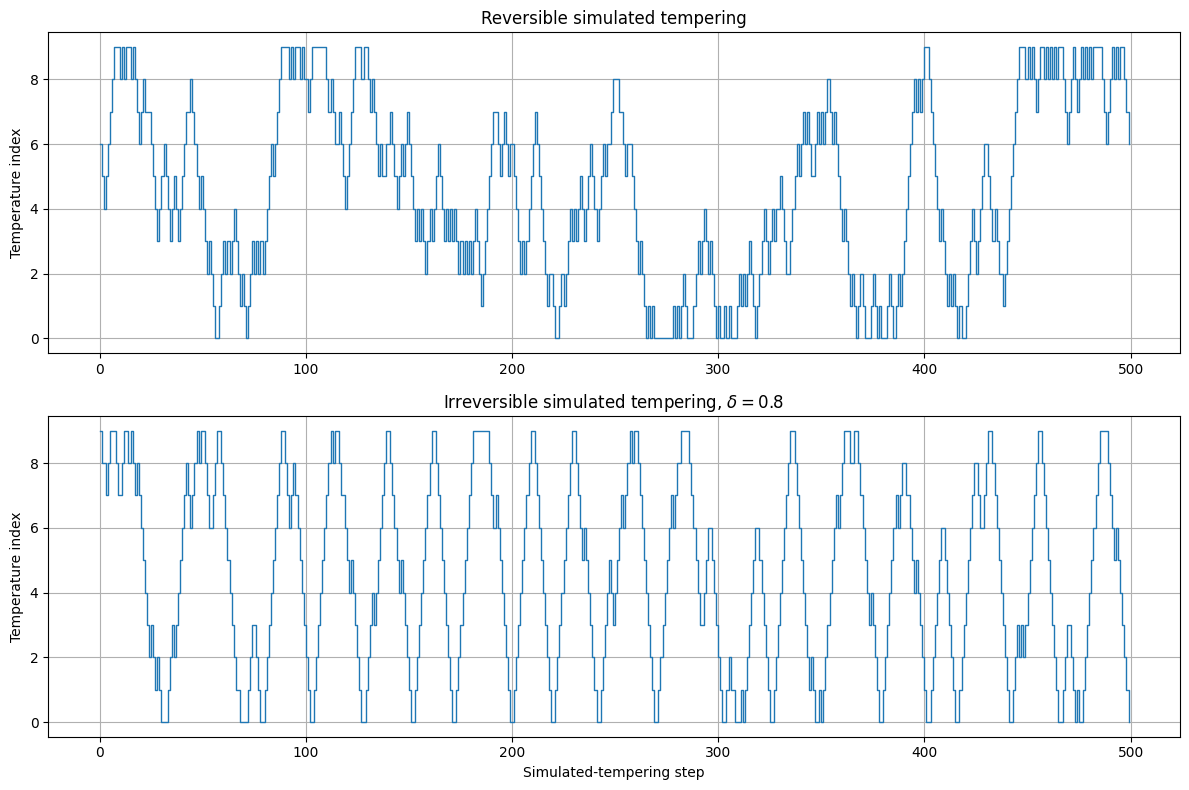

In [61]:
num_temperature_steps_to_compare = 500

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(
    tempering_temperature_indices[:num_temperature_steps_to_compare],
    linewidth=1,
    drawstyle="steps-post"
)

axes[0].set_ylabel("Temperature index")
axes[0].set_title("Reversible simulated tempering")
axes[0].grid()

axes[1].plot(
    irreversible_temperature_indices[:num_temperature_steps_to_compare],
    linewidth=1,
    drawstyle="steps-post"
)

axes[1].set_xlabel("Simulated-tempering step")
axes[1].set_ylabel("Temperature index")
axes[1].set_title(
    fr"Irreversible simulated tempering, $\delta={irreversible_delta}$"
)
axes[1].grid()

plt.tight_layout()
plt.show()

In [62]:
def temperature_round_trip_times(temperature_indices, num_temperatures):
    """
    Calculate the round-trip times for a sequence of temperature indices.

    Args:
        temperature_indices (int): A sequence of temperature indices.
        num_temperatures (int): The number of temperatures.

    Returns:
        np.ndarray: An array of round-trip times.
    """
    lower_index = 0
    upper_index = num_temperatures - 1

    starting_endpoint = None
    opposite_endpoint_reached = False
    starting_step = None

    round_trip_times = []

    for step, temperature_index in enumerate(temperature_indices):
        if starting_endpoint is None:
            if temperature_index in (lower_index, upper_index):
                starting_endpoint = temperature_index
                starting_step = step

        elif not opposite_endpoint_reached:
            opposite_endpoint = (
                upper_index
                if starting_endpoint == lower_index
                else lower_index
            )

            if temperature_index == opposite_endpoint:
                opposite_endpoint_reached = True

        elif temperature_index == starting_endpoint:
            round_trip_times.append(step - starting_step)
            starting_step = step
            opposite_endpoint_reached = False

    return np.array(round_trip_times)

In [63]:
num_round_trip_comparison_steps = min(
    len(tempering_temperature_indices),
    len(irreversible_temperature_indices)
)

reversible_round_trip_times = temperature_round_trip_times(
    tempering_temperature_indices[:num_round_trip_comparison_steps],
    len(tempering_temperatures)
)

irreversible_round_trip_times = temperature_round_trip_times(
    irreversible_temperature_indices[:num_round_trip_comparison_steps],
    len(tempering_temperatures)
)

print(f"Number of steps compared: {num_round_trip_comparison_steps}")
print(f"Reversible completed round trips: {len(reversible_round_trip_times)}")
print(f"Irreversible completed round trips: {len(irreversible_round_trip_times)}")
print(f"Reversible mean round-trip time: {np.mean(reversible_round_trip_times):.2f} steps")
print(f"Irreversible mean round-trip time: {np.mean(irreversible_round_trip_times):.2f} steps")
print(f"Reversible median round-trip time: {np.median(reversible_round_trip_times):.2f} steps")
print(f"Irreversible median round-trip time: {np.median(irreversible_round_trip_times):.2f} steps")
print(f"Round-trip speed-up: {np.mean(reversible_round_trip_times) / np.mean(irreversible_round_trip_times):.2f}x")

Number of steps compared: 10000000
Reversible completed round trips: 50348
Irreversible completed round trips: 233927
Reversible mean round-trip time: 198.62 steps
Irreversible mean round-trip time: 42.75 steps
Reversible median round-trip time: 173.00 steps
Irreversible median round-trip time: 36.00 steps
Round-trip speed-up: 4.65x


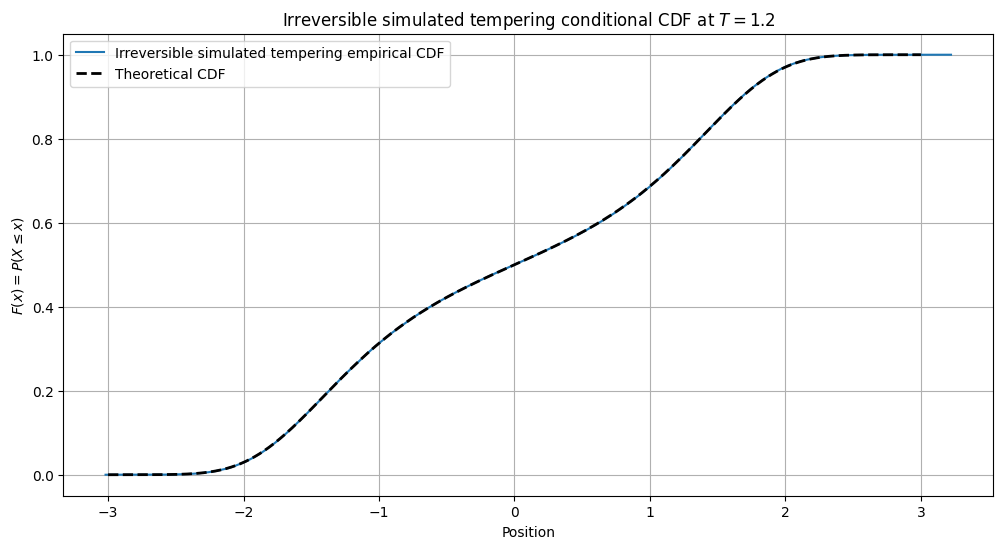

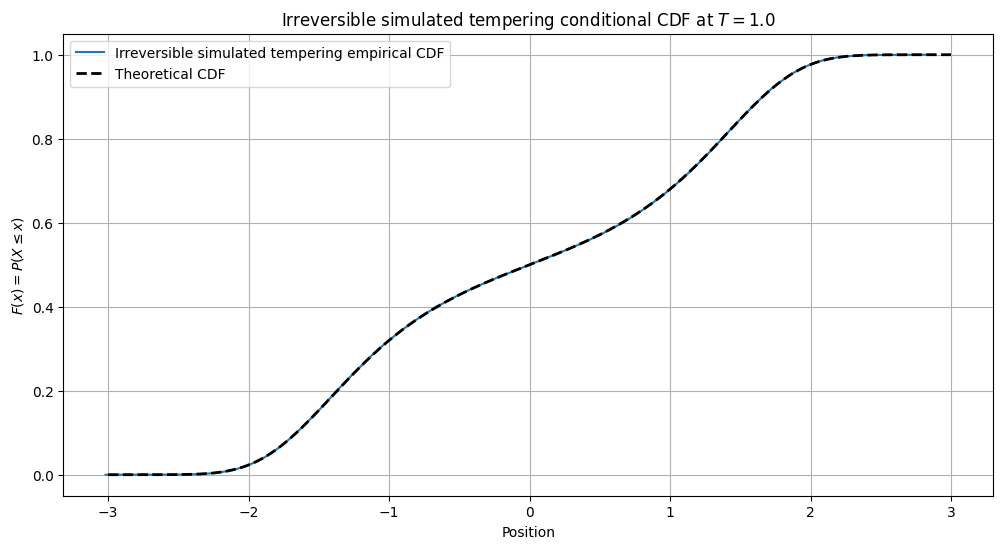

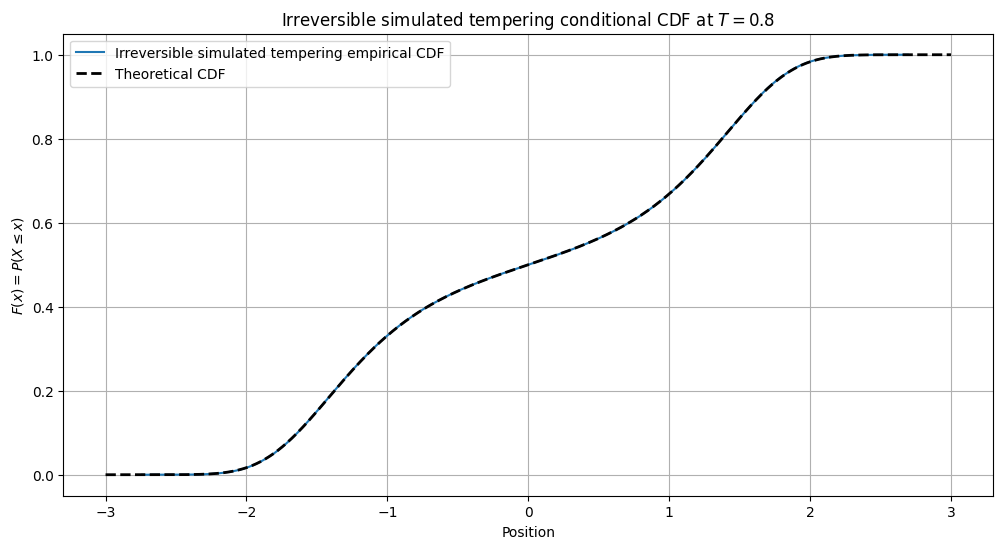

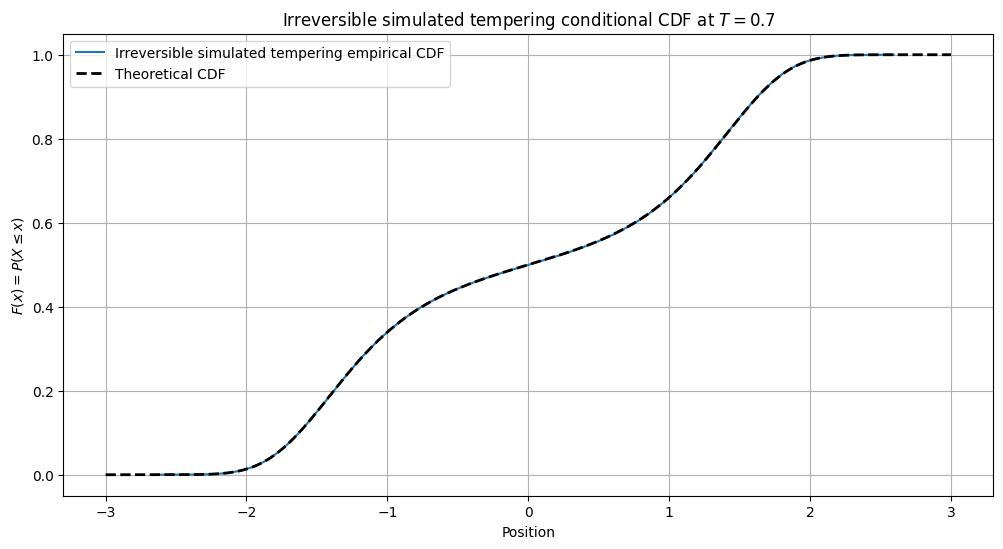

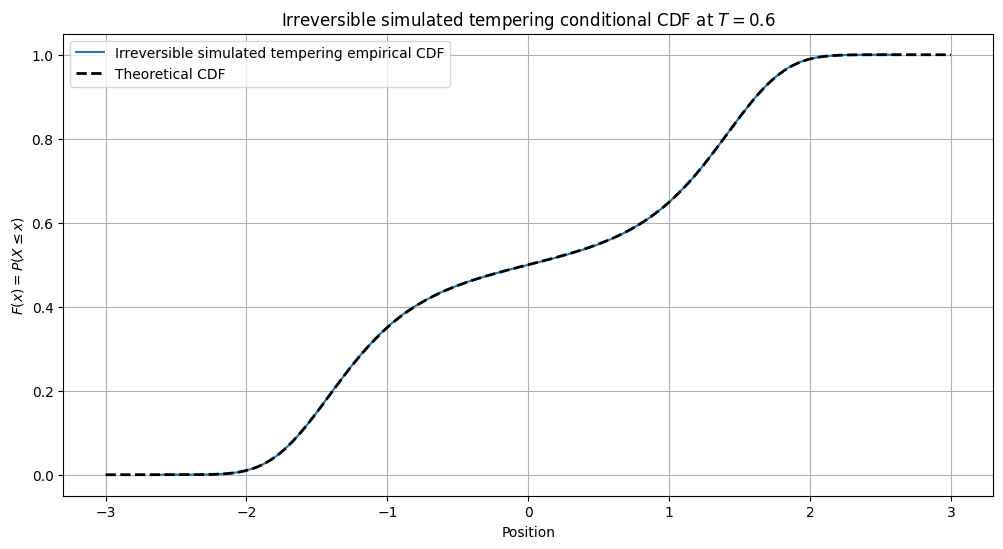

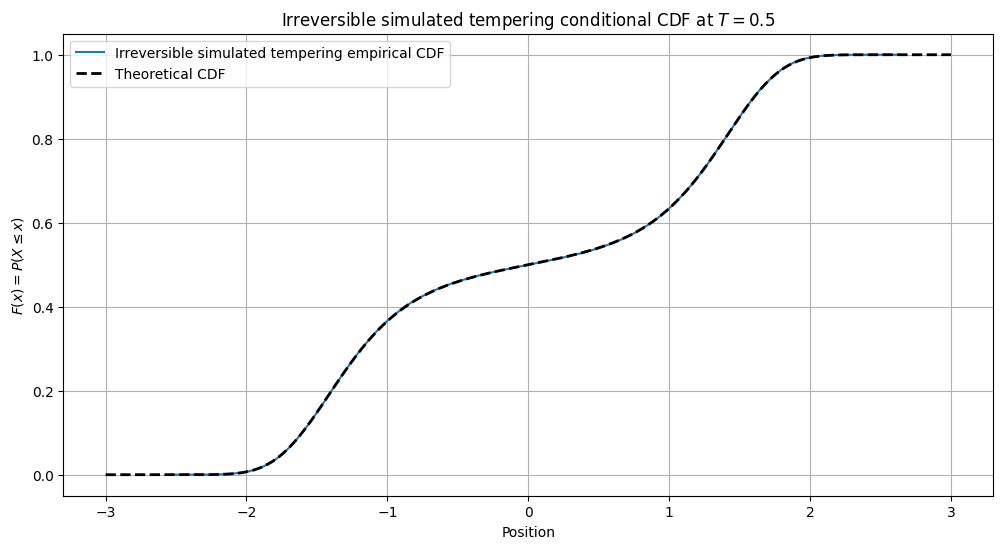

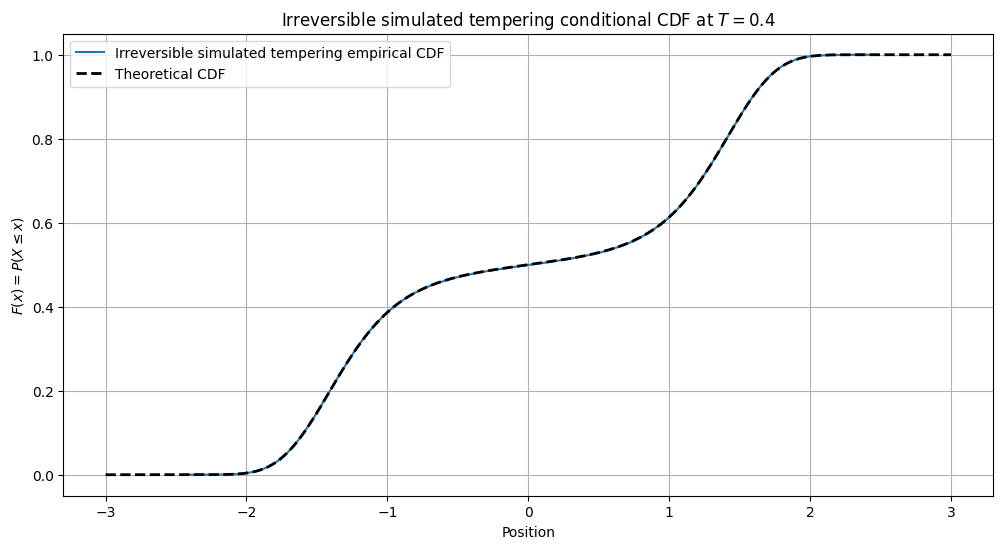

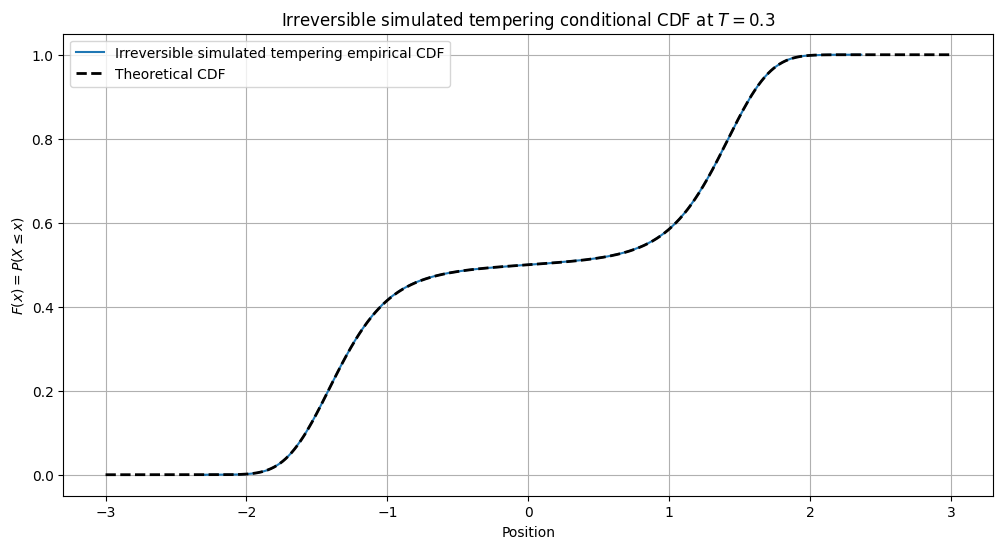

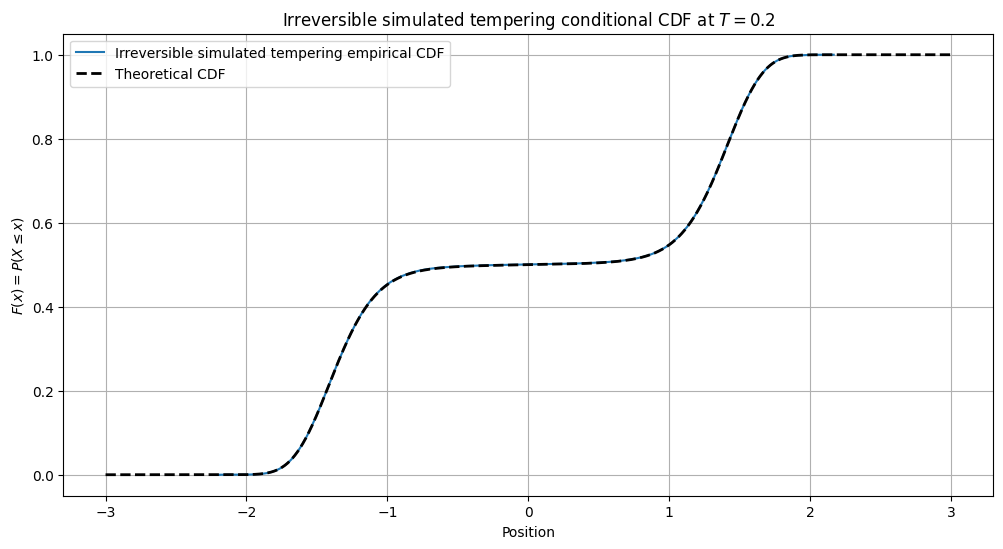

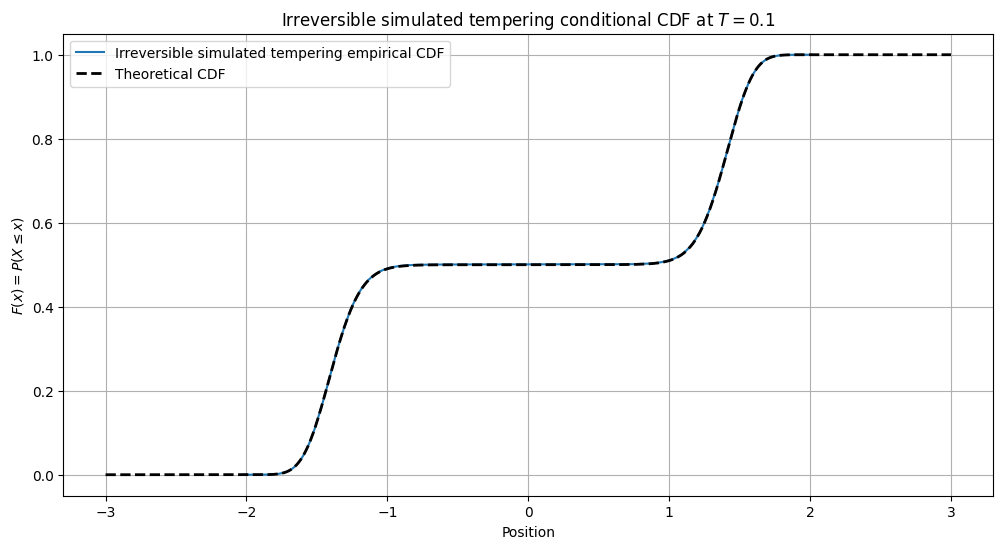

In [64]:
irreversible_positions_by_temperature = {
    temperature: irreversible_position_samples[
        irreversible_temperature_indices == temperature_index
    ]
    for temperature_index, temperature in enumerate(tempering_temperatures)
}

for temperature, positions in irreversible_positions_by_temperature.items():
    empirical_x_cdf, empirical_y_cdf = empirical_cdf(positions)

    theoretical_y_cdf = theoretical_cdf(
        x_grid_tempering_cdf,
        double_potential,
        temperature
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        empirical_x_cdf,
        empirical_y_cdf,
        label="Irreversible simulated tempering empirical CDF"
    )

    plt.plot(
        x_grid_tempering_cdf,
        theoretical_y_cdf,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Theoretical CDF"
    )

    plt.xlabel("Position")
    plt.ylabel(r"$F(x)=P(X\leq x)$")
    plt.title(
        fr"Irreversible simulated tempering conditional CDF at $T={temperature}$"
    )
    plt.grid()
    plt.legend()
    plt.show()

## Temperature-Augmented ECMC

In [65]:
def choose_augmented_velocity(rng):
    """
    Choose an augmented velocity uniformly at random.

    Args:
        rng (numpy.random.Generator): A random number generator.

    Returns:
        tuple: The inverse-temperature velocity and position velocity.
    """
    possible_velocities = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1)
    ]

    velocity_index = rng.integers(len(possible_velocities))

    v_beta, velocity = possible_velocities[velocity_index]

    return v_beta, velocity

In [66]:
def initialise_augmented_state(beta_min, beta_max, initial_x, rng):
    """
    Initialise the position, inverse temperature and augmented velocity.

    Args:
        beta_min (float): The minimum inverse temperature.
        beta_max (float): The maximum inverse temperature.
        initial_x (float): The initial position.
        rng (numpy.random.Generator): A random number generator.

    Returns:
        tuple: The initial position, inverse temperature,
        inverse-temperature velocity and position velocity.
    """
    x_current = initial_x
    beta_current = rng.uniform(beta_min, beta_max)

    v_beta, velocity = choose_augmented_velocity(rng)

    return x_current, beta_current, v_beta, velocity

In [67]:
temperature_values = np.asarray(temperatures)

temperature_buffer_fraction = 0.25

# Add a buffer above the largest target temperature.
beta_min = 1.0 / (
    (1.0 + temperature_buffer_fraction)
    * np.max(temperature_values)
)

beta_max = 1.0 / np.min(
    temperature_values
)

beta_speed = 1.0

initial_x = left_minimum

x_current, beta_current, v_beta, velocity = (
    initialise_augmented_state(
        beta_min=beta_min,
        beta_max=beta_max,
        initial_x=initial_x,
        rng=rng
    )
)

print(f"Initial position: {x_current:.4f}")
print(f"Initial inverse temperature: {beta_current:.4f}")
print(f"Inverse-temperature velocity: {v_beta}")
print(f"Position velocity: {velocity}")

Initial position: -1.4142
Initial inverse temperature: 9.5481
Inverse-temperature velocity: 1
Position velocity: 0


In [68]:
def distance_to_beta_boundary(beta_current, v_beta, beta_min, beta_max):
    """
    Calculate the distance to the next inverse-temperature boundary.

    Args:
        beta_current (float): The current inverse temperature.
        v_beta (int): The inverse-temperature velocity.
        beta_min (float): The minimum inverse temperature.
        beta_max (float): The maximum inverse temperature.

    Returns:
        float: The distance to the next inverse-temperature boundary.
    """
    if v_beta == 1:
        return beta_max - beta_current

    if v_beta == -1:
        return beta_current - beta_min

    return np.inf

In [69]:
def thermal_average_energy(beta, potential_func, x_grid):
    """
    Calculate the thermal average of the potential energy.

    Args:
        beta (float): The inverse temperature.
        potential_func (callable): The potential energy function.
        x_grid (np.ndarray): The position grid used for integration.

    Returns:
        float: The thermal average of the potential energy.
    """
    temperature = 1.0 / beta

    density = target_distribution(
        x_grid,
        potential_func,
        temperature
    )

    mean_energy = np.trapezoid(
        potential_func(x_grid) * density,
        x_grid
    )

    return mean_energy

In [70]:
def build_thermal_average_energy_interpolator(beta_min, beta_max, num_beta_points, potential_func, x_grid):
    """
    Precompute the thermal average energy on a beta grid and construct a linear interpolator.

    Args:
        beta_min (float): Minimum inverse temperature.
        beta_max (float): Maximum inverse temperature.
        num_beta_points (int): Number of grid points.
        potential_func (callable): Potential energy function.
        x_grid (np.ndarray): Position grid used for numerical integration.
        
    Raises:
        ValueError: If beta_min is not in [beta_min, beta_max].

    Returns:
        tuple: Beta grid, thermal-average values and interpolation function.
    """
    beta_grid = np.linspace(
        beta_min,
        beta_max,
        num_beta_points
    )

    mean_energy_grid = np.array([
        thermal_average_energy(
            beta=beta,
            potential_func=potential_func,
            x_grid=x_grid
        )
        for beta in beta_grid
    ])

    def mean_energy_func(beta):
        """
        Interpolate the thermal average energy at a given inverse temperature.

        Args:
            beta (float or numpy.ndarray): The inverse temperature(s) at which to interpolate.

        Raises:
            ValueError: If the inverse temperature is outside the valid range.

        Returns:
            float or numpy.ndarray: The interpolated thermal average energy.
        """
        beta_values = np.asarray(beta, dtype=float)

        if np.any(beta_values < beta_min) or np.any(beta_values > beta_max):
            raise ValueError(
                "beta must lie inside [beta_min, beta_max]."
            )

        interpolated_values = np.interp(
            beta_values,
            beta_grid,
            mean_energy_grid
        )

        if beta_values.ndim == 0:
            return float(interpolated_values)

        return interpolated_values

    return beta_grid, mean_energy_grid, mean_energy_func


(
    mean_energy_beta_grid,
    mean_energy_values,
    mean_energy_func
) = build_thermal_average_energy_interpolator(
    beta_min=beta_min,
    beta_max=beta_max,
    num_beta_points=1_001,
    potential_func=double_potential,
    x_grid=x_grid_tempering
)

In [71]:
beta_midpoints = 0.5 * (
    mean_energy_beta_grid[:-1]
    + mean_energy_beta_grid[1:]
)

validation_indices = np.linspace(
    0,
    len(beta_midpoints) - 1,
    25,
    dtype=int
)

validation_betas = beta_midpoints[validation_indices]

direct_mean_energies = np.array([
    thermal_average_energy(
        beta=beta,
        potential_func=double_potential,
        x_grid=x_grid_tempering
    )
    for beta in validation_betas
])

interpolated_mean_energies = mean_energy_func(
    validation_betas
)

maximum_interpolation_error = np.max(
    np.abs(
        direct_mean_energies
        - interpolated_mean_energies
    )
)

# The thermal average should decrease as beta increases.
assert np.all(np.diff(mean_energy_values) <= 1e-12)

# Check that the interpolation is sufficiently accurate.
assert maximum_interpolation_error < 1e-4

print(
    "Maximum thermal-average interpolation error: "
    f"{maximum_interpolation_error:.8f}"
)

Maximum thermal-average interpolation error: 0.00001139


In [72]:
# v_beta = 0 
def position_event_rate(x_current, beta_current, v_x, potential_derivative_func):
    """
    Calculate the event rate for position motion in the augmented state space.

    Args:
        x_current (float): The current position.
        beta_current (float): The current inverse temperature.
        v_x (int): The position velocity.
        potential_derivative_func (callable): The derivative of the potential function.
        
    Returns:
        float: The position event rate.
    """
    potential_gradient = potential_derivative_func(x_current)

    event_rate = beta_current * max(
        0.0,
        v_x * potential_gradient
    )

    return event_rate

# v_x = 0
def inverse_temperature_event_rate(x_current, beta_current, v_beta, beta_speed, potential_func, mean_energy_func):
    """
    Calculate the inverse-temperature event rate.

    Args:
        x_current (float): Current position.
        beta_current (float): Current inverse temperature.
        v_beta (int): Inverse-temperature velocity.
        beta_speed (float): Speed of inverse-temperature changes.
        potential_func (callable): Potential energy function.
        mean_energy_func (callable): Interpolated thermal-average function.

    Raises:
        ValueError: If beta_speed is not positive.

    Returns:
        float: Inverse-temperature event rate.
    """
    if beta_speed <= 0:
        raise ValueError(
            "beta_speed must be positive."
        )

    energy_current = potential_func(
        x_current
    )

    mean_energy = mean_energy_func(
        beta_current
    )

    event_rate = beta_speed * max(
        0.0,
        v_beta
        * (
            energy_current
            - mean_energy
        )
    )

    return event_rate

In [73]:
def dominating_inverse_temperature_event_rate(x_current, v_beta, beta_min, beta_max, beta_speed, potential_func, mean_energy_func):
    """
    Calculate the dominating event rate for inverse-temperature motion.

    Args:
        x_current (float): The current position.
        v_beta (int): The inverse-temperature velocity, either +1 or -1.
        beta_min (float): The minimum inverse temperature.
        beta_max (float): The maximum inverse temperature.
        beta_speed (float): Speed of inverse-temperature changes.
        potential_func (callable): The potential energy function.
        mean_energy_func (callable): The interpolated thermal-average function.

    Raises:
        ValueError: If v_beta is not either +1 or -1.

    Returns:
        float: The dominating inverse-temperature event rate.
    """         
    if v_beta == 1:
        bounding_beta = beta_max

    elif v_beta == -1:
        bounding_beta = beta_min

    else:
        raise ValueError("v_beta must be either +1 or -1.")

    dominating_rate = (
        inverse_temperature_event_rate(
            x_current=x_current,
            beta_current=bounding_beta,
            v_beta=v_beta,
            beta_speed=beta_speed,
            potential_func=potential_func,
            mean_energy_func=mean_energy_func
        )
    )

    return dominating_rate

In [74]:
beta_check_grid = np.linspace(
    beta_min,
    beta_max,
    1_001
)

x_check_grid = np.linspace(
    -3.0,
    3.0,
    61
)

validation_beta_speed = 1.0

number_of_positive_bounds = 0

for x_test in x_check_grid:

    for v_beta_test in (-1, 1):

        calculated_rates = np.array([
            inverse_temperature_event_rate(
                x_current=x_test,
                beta_current=beta,
                v_beta=v_beta_test,
                beta_speed=validation_beta_speed,
                potential_func=double_potential,
                mean_energy_func=mean_energy_func
            )
            for beta in beta_check_grid
        ])

        dominating_rate_test = (
            dominating_inverse_temperature_event_rate(
                x_current=x_test,
                v_beta=v_beta_test,
                beta_min=beta_min,
                beta_max=beta_max,
                beta_speed=validation_beta_speed,
                potential_func=double_potential,
                mean_energy_func=mean_energy_func
            )
        )

        maximum_calculated_rate = np.max(
            calculated_rates
        )

        assert (
            maximum_calculated_rate
            <= dominating_rate_test + 1e-12
        )

        if dominating_rate_test > 0:
            number_of_positive_bounds += 1

assert number_of_positive_bounds > 0

print(
    "Inverse-temperature event-rate "
    "bound verified."
)

Inverse-temperature event-rate bound verified.


In [75]:
def sample_inverse_temperature_candidate_time(dominating_rate, rng):
    """
    Sample a candidate time for the next inverse-temperature event.

    Args:
        dominating_rate (float): The dominating event rate.
        rng (numpy.random.Generator): A random number generator.
        
    Raises:
        ValueError: If dominating_rate is negative.
    
    Returns:
        float: The sampled candidate time.
    """
    if dominating_rate < 0:
        raise ValueError("Dominating rate must be positive.")
    
    if dominating_rate == 0:
        return np.inf
    
    return rng.exponential(scale=1.0 / dominating_rate)

In [76]:
def inverse_temperature_motion_step(x_current, beta_current, v_beta, beta_min, beta_max, beta_speed, potential_func, mean_energy_func, rng):
    """
    Perform a single step of inverse-temperature motion.

    Args:
        x_current (float): The current position.
        beta_current (float): The current inverse temperature.
        v_beta (int): The inverse-temperature velocity, either +1 or -1.
        beta_min (float): The minimum inverse temperature.
        beta_max (float): The maximum inverse temperature.
        beta_speed (float): The speed of inverse-temperature changes.
        potential_func (callable): The potential energy function.
        mean_energy_func (callable): The interpolated thermal-average function.
        rng (numpy.random.Generator): A random number generator.

    Returns:
        tuple: A tuple containing the new inverse temperature and the elapsed time.
    """
    dominating_rate = (
        dominating_inverse_temperature_event_rate(
            x_current=x_current,
            v_beta=v_beta,
            beta_min=beta_min,
            beta_max=beta_max,
            beta_speed=beta_speed,
            potential_func=potential_func,
            mean_energy_func=mean_energy_func
        )
    )

    candidate_waiting_time = (
        sample_inverse_temperature_candidate_time(
            dominating_rate=dominating_rate,
            rng=rng
        )
    )

    boundary_waiting_time = (
        distance_to_beta_boundary(
            beta_current=beta_current,
            v_beta=v_beta,
            beta_min=beta_min,
            beta_max=beta_max
        )
        / beta_speed
    )

    if (
        boundary_waiting_time
        <= candidate_waiting_time
    ):

        if v_beta == 1:
            beta_new = beta_max
        else:
            beta_new = beta_min

        return {
            "beta_new": beta_new,
            "elapsed_time": (
                boundary_waiting_time
            ),
            "event_type": "boundary",
            "event_confirmed": True,
            "confirmation_probability": None
        }

    beta_new = (
        beta_current
        + v_beta
        * beta_speed
        * candidate_waiting_time
    )

    candidate_event_rate = (
        inverse_temperature_event_rate(
            x_current=x_current,
            beta_current=beta_new,
            v_beta=v_beta,
            beta_speed=beta_speed,
            potential_func=potential_func,
            mean_energy_func=mean_energy_func
        )
    )

    rate_ratio = (
        candidate_event_rate
        / dominating_rate
    )

    if rate_ratio > 1.0 + 1e-12:
        raise RuntimeError(
            "Candidate event rate exceeded "
            "the dominating rate."
        )

    confirmation_probability = min(
        1.0,
        rate_ratio
    )

    event_confirmed = (
        rng.random()
        < confirmation_probability
    )

    if event_confirmed:
        event_type = (
            "inverse_temperature_event"
        )
    else:
        event_type = "rejected_candidate"

    return {
        "beta_new": beta_new,
        "elapsed_time": (
            candidate_waiting_time
        ),
        "event_type": event_type,
        "event_confirmed": event_confirmed,
        "confirmation_probability": (
            confirmation_probability
        )
    }

In [77]:
def position_motion_step(x_current, beta_current, v_x, a, b, rng):
    """
    Advance the position coordinate until the next position event.
    The inverse temperature remains fixed during this motion.

    Args:
        x_current (float): Current position.
        beta_current (float): Current inverse temperature.
        v_x (int): Position velocity, either +1 or -1.
        a (float): Double-well quadratic coefficient.
        b (float): Double-well quartic coefficient.
        rng (numpy.random.Generator): Random number generator.

    Raises:
        ValueError: If beta_current is not positive.
        ValueError: If v_x is not either +1 or -1.

    Returns:
        dict: Updated position and event information.
    """
    if beta_current <= 0:
        raise ValueError("beta_current must be positive.")

    if v_x not in (-1, 1):
        raise ValueError("v_x must be either +1 or -1.")

    temperature_current = 1.0 / beta_current

    event_time = distance_to_next_event_double_well(
        x_current=x_current,
        velocity=v_x,
        temperature=temperature_current,
        a=a,
        b=b,
        rng=rng
    )

    x_new = (
        x_current
        + v_x * event_time
    )

    return {
        "x_new": x_new,
        "elapsed_time": event_time,
        "event_type": "position_event",
        "event_confirmed": True
    }

In [78]:
def choose_lifted_velocity(x_current, beta_current, beta_speed, potential_func, potential_derivative_func, mean_energy_func, rng):
    """
    Choose the augmented velocity following a confirmed event.

    Args:
        x_current (float): Current position.
        beta_current (float): Current inverse temperature.
        beta_speed (float): Speed of inverse-temperature changes.
        potential_func (callable): Potential energy function.
        potential_derivative_func (callable): Derivative of the potential.
        mean_energy_func (callable): Interpolated thermal-average function.
        rng (numpy.random.Generator): Random number generator.

    Raises:
        RuntimeError: If all lifting weights are zero.

    Returns:
        dict: Selected augmented velocity, weights and probabilities.
    """
    if beta_speed <= 0:
        raise ValueError(
            "beta_speed must be positive."
        )

    energy_difference = (
        potential_func(x_current)
        - mean_energy_func(beta_current)
    )

    potential_gradient = (
        potential_derivative_func(
            x_current
        )
    )

    possible_velocities = np.array([
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1)
    ])

    lifting_weights = np.array([
        beta_speed * max(
            0.0,
            -energy_difference
        ),
        beta_speed * max(
            0.0,
            energy_difference
        ),
        max(
            0.0,
            -beta_current
            * potential_gradient
        ),
        max(
            0.0,
            beta_current
            * potential_gradient
        )
    ])

    total_weight = np.sum(
        lifting_weights
    )

    if total_weight <= 0:
        raise RuntimeError(
            "All lifting weights are zero."
        )

    lifting_probabilities = (
        lifting_weights
        / total_weight
    )

    selected_index = rng.choice(
        len(possible_velocities),
        p=lifting_probabilities
    )

    v_beta_new, v_x_new = (
        possible_velocities[
            selected_index
        ]
    )

    return {
        "v_beta_new": int(v_beta_new),
        "v_x_new": int(v_x_new),
        "lifting_weights": lifting_weights,
        "lifting_probabilities": (
            lifting_probabilities
        )
    }

In [79]:
def reflect_inverse_temperature_velocity(beta_current, v_beta, beta_min, beta_max, tolerance=1e-12):
    """
    Reflect the inverse-temperature velocity at a boundary.

    Args:
        beta_current (float): Current inverse temperature.
        v_beta (int): Incoming inverse-temperature velocity.
        beta_min (float): Minimum inverse temperature.
        beta_max (float): Maximum inverse temperature.
        tolerance (float): Boundary comparison tolerance.

    Raises:
        ValueError: If the state is not moving outwards at a boundary.

    Returns:
        int: Reflected inverse-temperature velocity.
    """
    at_lower_boundary = np.isclose(
        beta_current,
        beta_min,
        atol=tolerance,
        rtol=0.0
    )

    at_upper_boundary = np.isclose(
        beta_current,
        beta_max,
        atol=tolerance,
        rtol=0.0
    )

    if at_lower_boundary and v_beta == -1:
        return 1

    if at_upper_boundary and v_beta == 1:
        return -1

    raise ValueError(
        "The state is not moving outwards at a beta boundary."
    )

In [80]:
def augmented_ecmc_event_step(
    x_current,
    beta_current,
    v_beta,
    v_x,
    beta_min,
    beta_max,
    beta_speed,
    a,
    b,
    potential_func,
    potential_derivative_func,
    mean_energy_func,
    rng
):
    """
    Perform one event step of temperature-augmented ECMC.

    Args:
        x_current (float): Current position.
        beta_current (float): Current inverse temperature.
        v_beta (int): Inverse-temperature velocity.
        v_x (int): Position velocity.
        beta_min (float): Minimum inverse temperature.
        beta_max (float): Maximum inverse temperature.
        beta_speed (float): Speed of inverse-temperature changes.
        a (float): Double-well quadratic coefficient.
        b (float): Double-well quartic coefficient.
        potential_func (callable): Potential energy function.
        potential_derivative_func (callable): Potential derivative.
        mean_energy_func (callable): Interpolated thermal-average function.
        rng (numpy.random.Generator): Random number generator.

    Raises:
        ValueError: If the augmented velocity is invalid.
        RuntimeError: If an unknown event type is returned.

    Returns:
        dict: Updated state and event information.
    """
    valid_velocities = {
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1)
    }

    if (v_beta, v_x) not in valid_velocities:
        raise ValueError(
            "The augmented velocity must have exactly "
            "one active coordinate."
        )

    # Position motion.
    if v_x != 0:

        motion_result = position_motion_step(
            x_current=x_current,
            beta_current=beta_current,
            v_x=v_x,
            a=a,
            b=b,
            rng=rng
        )

        x_new = motion_result["x_new"]
        beta_new = beta_current

        lifting_result = choose_lifted_velocity(
            x_current=x_new,
            beta_current=beta_new,
            beta_speed=beta_speed,
            potential_func=potential_func,
            potential_derivative_func=potential_derivative_func,
            mean_energy_func=mean_energy_func,
            rng=rng
        )

        return {
            "x_new": x_new,
            "beta_new": beta_new,
            "v_beta_new": lifting_result["v_beta_new"],
            "v_x_new": lifting_result["v_x_new"],
            "elapsed_time": motion_result["elapsed_time"],
            "event_type": "position_event",
            "event_confirmed": True,
            "confirmation_probability": None,
            "lifting_probabilities": (
                lifting_result["lifting_probabilities"]
            )
        }

    # Inverse-temperature motion.
    motion_result = inverse_temperature_motion_step(
        x_current=x_current,
        beta_current=beta_current,
        v_beta=v_beta,
        beta_min=beta_min,
        beta_max=beta_max,
        beta_speed=beta_speed,
        potential_func=potential_func,
        mean_energy_func=mean_energy_func,
        rng=rng
    )

    x_new = x_current
    beta_new = motion_result["beta_new"]
    event_type = motion_result["event_type"]

    # A rejected thinning candidate does not cause lifting.
    if event_type == "rejected_candidate":

        return {
            "x_new": x_new,
            "beta_new": beta_new,
            "v_beta_new": v_beta,
            "v_x_new": v_x,
            "elapsed_time": motion_result["elapsed_time"],
            "event_type": event_type,
            "event_confirmed": False,
            "confirmation_probability": (
                motion_result["confirmation_probability"]
            ),
            "lifting_probabilities": None
        }

    # Reflect at an inverse-temperature boundary.
    if event_type == "boundary":

        reflected_v_beta = (
            reflect_inverse_temperature_velocity(
                beta_current=beta_new,
                v_beta=v_beta,
                beta_min=beta_min,
                beta_max=beta_max
            )
        )

        return {
            "x_new": x_new,
            "beta_new": beta_new,
            "v_beta_new": reflected_v_beta,
            "v_x_new": 0,
            "elapsed_time": motion_result["elapsed_time"],
            "event_type": event_type,
            "event_confirmed": True,
            "confirmation_probability": None,
            "lifting_probabilities": None
        }

    # A confirmed inverse-temperature event causes lifting.
    if event_type == "inverse_temperature_event":

        lifting_result = choose_lifted_velocity(
            x_current=x_new,
            beta_current=beta_new,
            beta_speed=beta_speed,
            potential_func=potential_func,
            potential_derivative_func=potential_derivative_func,
            mean_energy_func=mean_energy_func,
            rng=rng
        )

        return {
            "x_new": x_new,
            "beta_new": beta_new,
            "v_beta_new": lifting_result["v_beta_new"],
            "v_x_new": lifting_result["v_x_new"],
            "elapsed_time": motion_result["elapsed_time"],
            "event_type": event_type,
            "event_confirmed": True,
            "confirmation_probability": (
                motion_result["confirmation_probability"]
            ),
            "lifting_probabilities": (
                lifting_result["lifting_probabilities"]
            )
        }

    raise RuntimeError(
        f"Unknown event type: {event_type}"
    )

In [81]:
def run_temperature_augmented_ecmc(
    initial_x,
    num_event_steps,
    beta_min,
    beta_max,
    beta_speed,
    a,
    b,
    potential_func,
    potential_derivative_func,
    mean_energy_func,
    rng
):
    """
    Run temperature-augmented ECMC for a fixed number of event steps.

    Args:
        initial_x (float): Initial position.
        num_event_steps (int): Number of event steps.
        beta_min (float): Minimum inverse temperature.
        beta_max (float): Maximum inverse temperature.
        beta_speed (float): Speed of inverse-temperature
        a (float): Double-well quadratic coefficient.
        b (float): Double-well quartic coefficient.
        potential_func (callable): Potential energy function.
        potential_derivative_func (callable): Potential derivative.
        mean_energy_func (callable): Interpolated thermal-average function.
        rng (numpy.random.Generator): Random number generator.

    Raises:
        ValueError: If beta_speed is not positive.
        
    Returns:
        dict: Continuous-time event trajectory and event counts.
    """
    if beta_speed <= 0:
        raise ValueError("beta_speed must be positive.")
        
    (
        current_x,
        current_beta,
        current_v_beta,
        current_v_x
    ) = initialise_augmented_state(
        beta_min=beta_min,
        beta_max=beta_max,
        initial_x=initial_x,
        rng=rng
    )

    # Prevent beta-only motion at a stationary position.
    if (
        current_v_x == 0
        and np.isclose(
            potential_derivative_func(current_x),
            0.0,
            atol=1e-12,
            rtol=0.0
        )
    ):
        current_v_beta = 0
        current_v_x = int(
            rng.choice([-1, 1])
        )

    current_time = 0.0

    event_times = np.empty(num_event_steps + 1)
    position_trajectory = np.empty(num_event_steps + 1)
    beta_trajectory = np.empty(num_event_steps + 1)

    v_beta_trajectory = np.empty(
        num_event_steps + 1
    )

    v_x_trajectory = np.empty(
        num_event_steps + 1
    )

    event_types = []
    event_confirmed = []

    event_times[0] = current_time
    position_trajectory[0] = current_x
    beta_trajectory[0] = current_beta
    v_beta_trajectory[0] = current_v_beta
    v_x_trajectory[0] = current_v_x

    for step in range(num_event_steps):

        step_result = augmented_ecmc_event_step(
            x_current=current_x,
            beta_current=current_beta,
            v_beta=current_v_beta,
            v_x=current_v_x,
            beta_min=beta_min,
            beta_max=beta_max,
            beta_speed=beta_speed,
            a=a,
            b=b,
            potential_func=potential_func,
            potential_derivative_func=(
                potential_derivative_func
            ),
            mean_energy_func=mean_energy_func,
            rng=rng
        )

        elapsed_time = step_result["elapsed_time"]

        if not np.isfinite(elapsed_time):
            raise RuntimeError(
                "The event step returned a non-finite time."
            )

        if elapsed_time < 0:
            raise RuntimeError(
                "The event step returned a negative time."
            )

        current_time += elapsed_time

        current_x = step_result["x_new"]
        current_beta = step_result["beta_new"]
        current_v_beta = step_result["v_beta_new"]
        current_v_x = step_result["v_x_new"]

        event_times[step + 1] = current_time
        position_trajectory[step + 1] = current_x
        beta_trajectory[step + 1] = current_beta
        v_beta_trajectory[step + 1] = current_v_beta
        v_x_trajectory[step + 1] = current_v_x

        event_types.append(
            step_result["event_type"]
        )

        event_confirmed.append(
            step_result["event_confirmed"]
        )

    event_types = np.array(event_types)
    event_confirmed = np.array(event_confirmed)

    unique_event_types, event_type_counts = np.unique(
        event_types,
        return_counts=True
    )

    event_counts = {
        str(event_type): int(count)
        for event_type, count in zip(
            unique_event_types,
            event_type_counts
        )
    }

    return {
        "event_times": event_times,
        "position_trajectory": position_trajectory,
        "beta_trajectory": beta_trajectory,
        "v_beta_trajectory": v_beta_trajectory,
        "v_x_trajectory": v_x_trajectory,
        "event_types": event_types,
        "event_confirmed": event_confirmed,
        "event_counts": event_counts
    }

In [82]:
num_augmented_event_steps = 10**6

maximum_effective_beta_interval = 1.0

temperature_augmented_results = {}

for index, temperature in enumerate(temperatures):

    beta_target = 1.0 / temperature

    physical_beta_interval = (
        beta_target - beta_min
    )

    if physical_beta_interval <= 0:
        raise ValueError(
            "beta_target must be greater than beta_min."
        )

    # Accelerate beta motion only when the original
    # interval is larger than the chosen maximum.
    beta_speed = max(
        1.0,
        physical_beta_interval
        / maximum_effective_beta_interval
    )

    effective_beta_interval = (
        physical_beta_interval / beta_speed
    )

    local_rng = np.random.default_rng(
        seed=42 + index
    )

    # Initialise away from a stationary point.
    initial_x_augmented = local_rng.normal(
        loc=0.0,
        scale=1.0
    )

    (
        target_beta_grid,
        target_mean_energy_values,
        target_mean_energy_func
    ) = build_thermal_average_energy_interpolator(
        beta_min=beta_min,
        beta_max=beta_target,
        num_beta_points=1_001,
        potential_func=double_potential,
        x_grid=x_grid_tempering
    )

    augmented_trajectory = (
        run_temperature_augmented_ecmc(
            initial_x=initial_x_augmented,
            num_event_steps=(
                num_augmented_event_steps
            ),
            beta_min=beta_min,
            beta_max=beta_target,
            beta_speed=beta_speed,
            a=a,
            b=b,
            potential_func=double_potential,
            potential_derivative_func=(
                lambda x: dU_double(x, a, b)
            ),
            mean_energy_func=(
                target_mean_energy_func
            ),
            rng=local_rng
        )
    )

    temperature_augmented_results[
        temperature
    ] = {
        "beta_target": beta_target,
        "beta_speed": beta_speed,
        "effective_beta_interval": (
            effective_beta_interval
        ),
        "initial_x": initial_x_augmented,
        "trajectory": augmented_trajectory
    }

    print(
        f"T={temperature:.1f}, "
        f"beta_target={beta_target:.4f}, "
        f"beta_speed={beta_speed:.4f}, "
        f"effective interval="
        f"{effective_beta_interval:.4f}, "
        f"initial_x={initial_x_augmented:.4f}, "
        f"simulated time="
        f"{augmented_trajectory['event_times'][-1]:.2f}"
    )

T=1.2, beta_target=0.8333, beta_speed=1.0000, effective interval=0.1667, initial_x=0.3047, simulated time=299802.28
T=1.0, beta_target=1.0000, beta_speed=1.0000, effective interval=0.3333, initial_x=0.2442, simulated time=531017.95
T=0.8, beta_target=1.2500, beta_speed=1.0000, effective interval=0.5833, initial_x=1.4460, simulated time=798680.14
T=0.7, beta_target=1.4286, beta_speed=1.0000, effective interval=0.7619, initial_x=-0.4579, simulated time=938084.25
T=0.6, beta_target=1.6667, beta_speed=1.0000, effective interval=1.0000, initial_x=-0.5029, simulated time=1069604.11
T=0.5, beta_target=2.0000, beta_speed=1.3333, effective interval=1.0000, initial_x=-0.6664, simulated time=997408.67
T=0.4, beta_target=2.5000, beta_speed=1.8333, effective interval=1.0000, initial_x=-0.3076, simulated time=904526.83
T=0.3, beta_target=3.3333, beta_speed=2.6667, effective interval=1.0000, initial_x=0.5707, simulated time=782382.73
T=0.2, beta_target=5.0000, beta_speed=4.3333, effective interval=1.

In [83]:
burn_in_time = 10_000

for temperature in temperatures:

    result = temperature_augmented_results[
        temperature
    ]

    beta_target = result["beta_target"]
    trajectory = result["trajectory"]

    # event_types[k] produces trajectory state k + 1.
    boundary_indices = (
        np.flatnonzero(
            trajectory["event_types"] == "boundary"
        )
        + 1
    )

    upper_boundary_indices = boundary_indices[
        np.isclose(
            trajectory["beta_trajectory"][
                boundary_indices
            ],
            beta_target,
            atol=1e-10,
            rtol=0.0
        )
    ]

    # Discard boundary visits during burn-in.
    upper_boundary_indices = upper_boundary_indices[
        trajectory["event_times"][
            upper_boundary_indices
        ]
        >= burn_in_time
    ]

    target_position_samples = (
        trajectory["position_trajectory"][
            upper_boundary_indices
        ]
    )

    target_sample_times = (
        trajectory["event_times"][
            upper_boundary_indices
        ]
    )

    result["position_samples"] = (
        target_position_samples
    )

    result["sample_times"] = target_sample_times

    print(
        f"T={temperature:.1f}: "
        f"recorded "
        f"{len(target_position_samples):,} "
        "upper-boundary samples."
    )

T=1.2: recorded 432,134 upper-boundary samples.
T=1.0: recorded 395,474 upper-boundary samples.
T=0.8: recorded 338,803 upper-boundary samples.
T=0.7: recorded 302,442 upper-boundary samples.
T=0.6: recorded 265,459 upper-boundary samples.
T=0.5: recorded 246,720 upper-boundary samples.
T=0.4: recorded 221,832 upper-boundary samples.
T=0.3: recorded 191,670 upper-boundary samples.
T=0.2: recorded 153,738 upper-boundary samples.
T=0.1: recorded 98,147 upper-boundary samples.


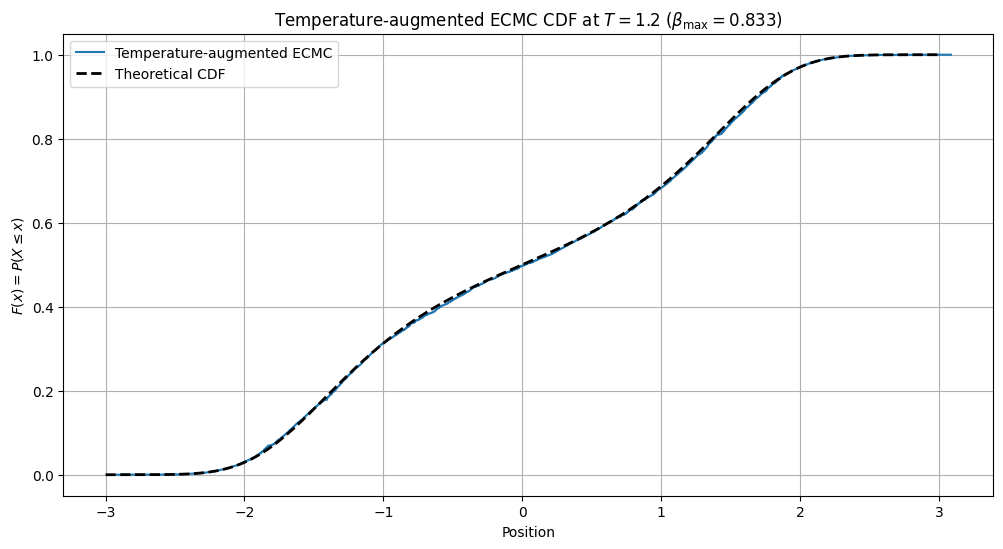

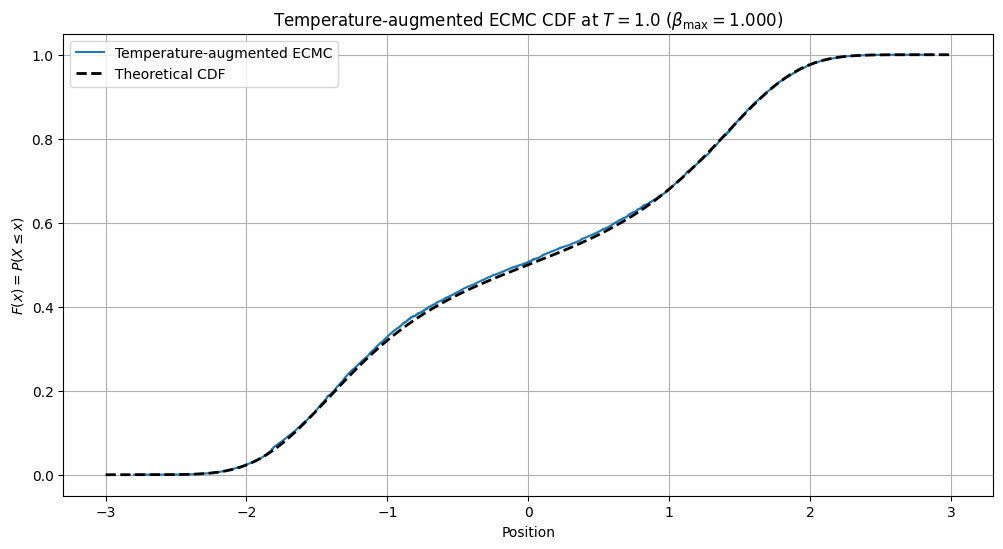

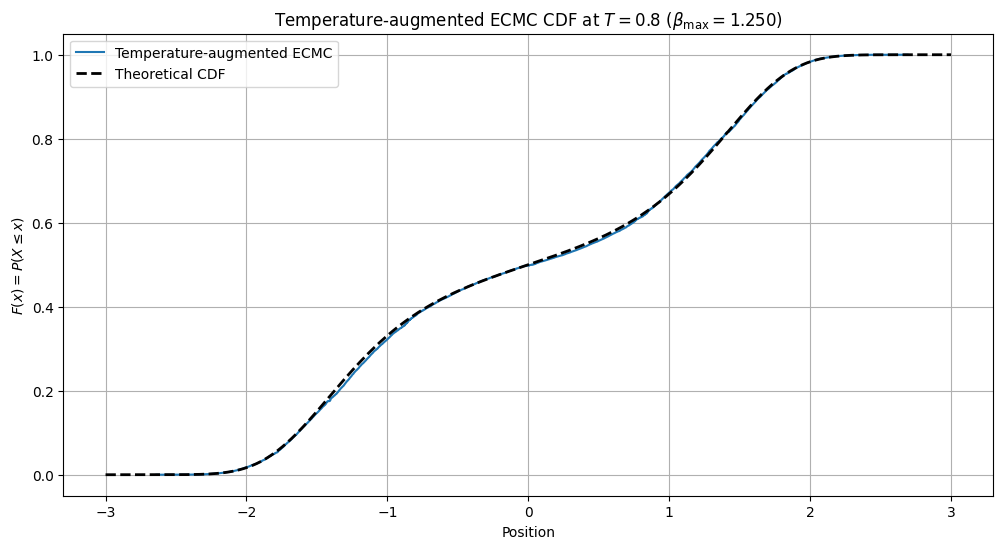

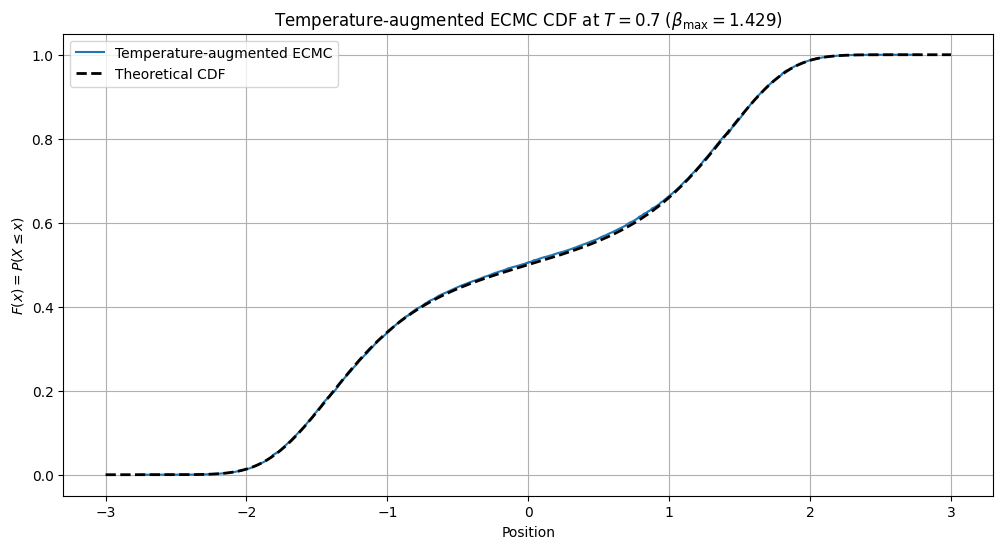

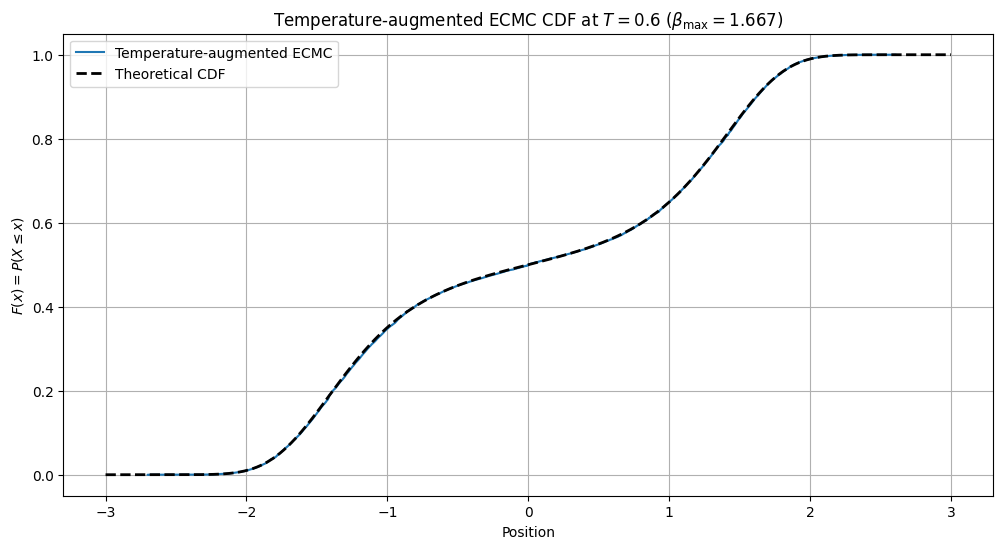

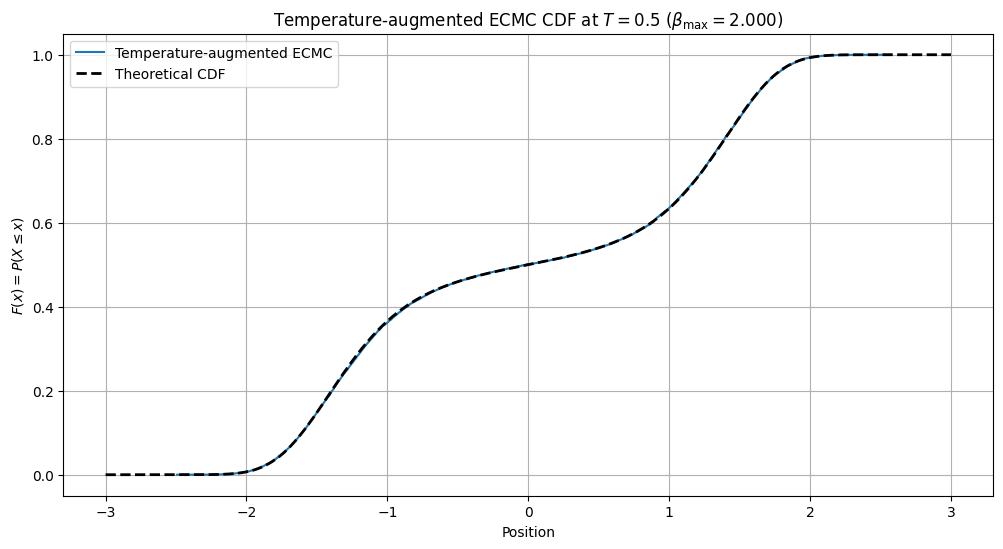

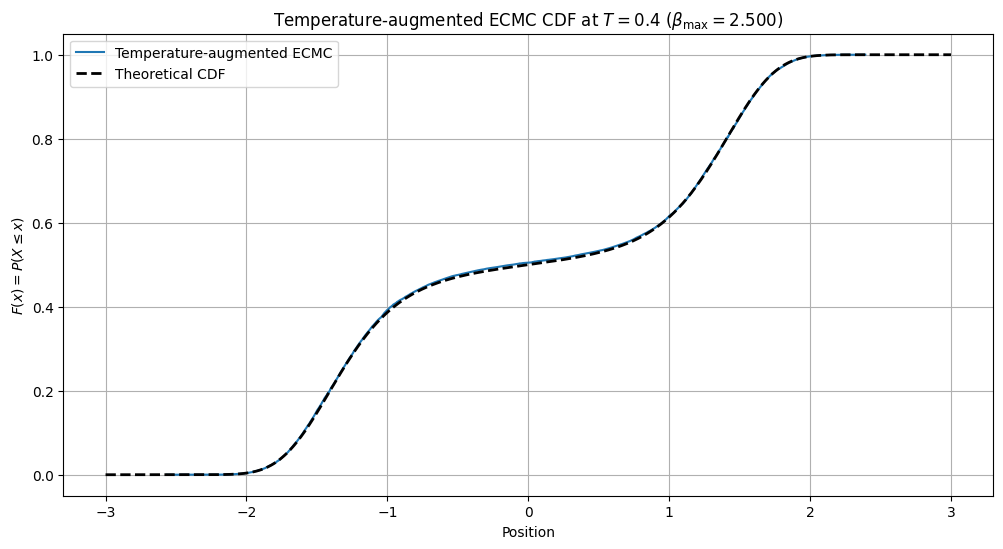

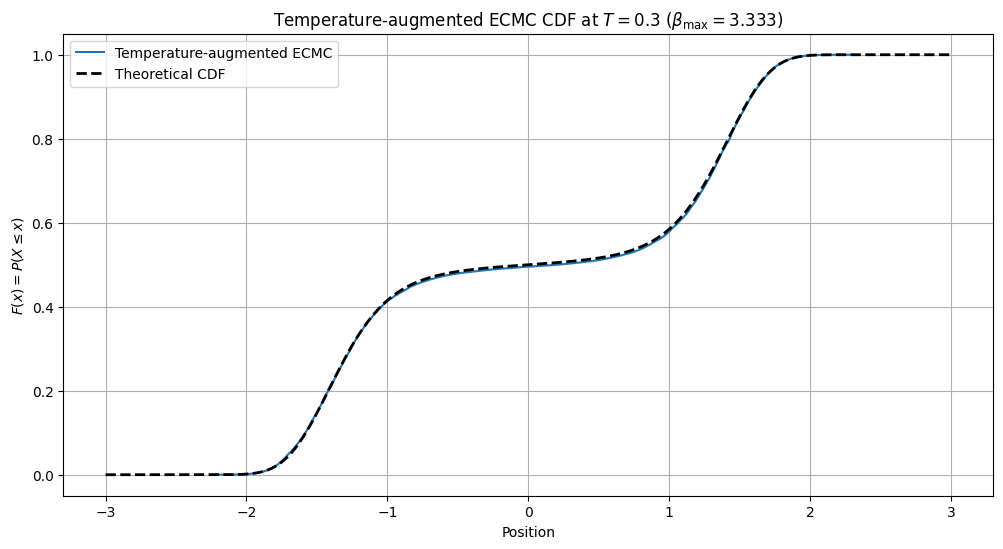

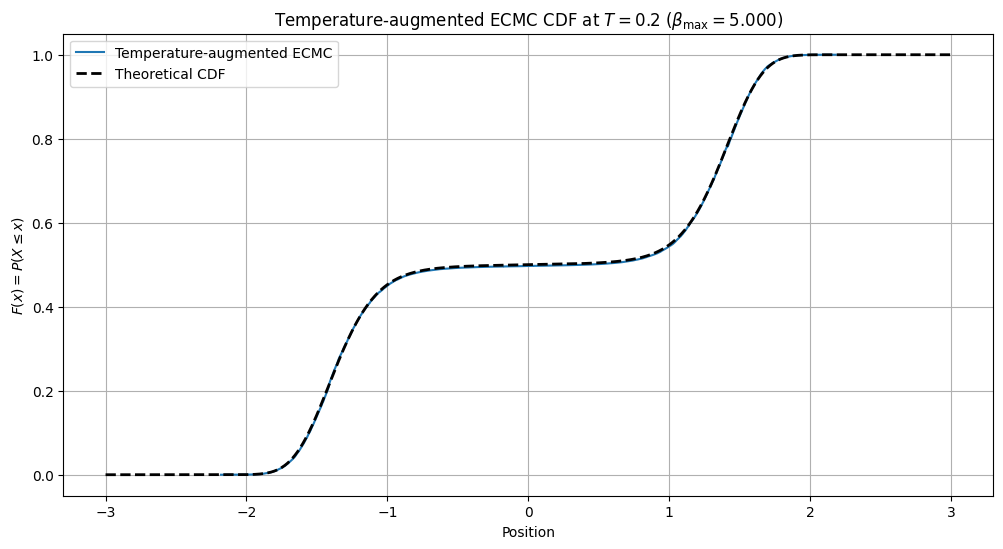

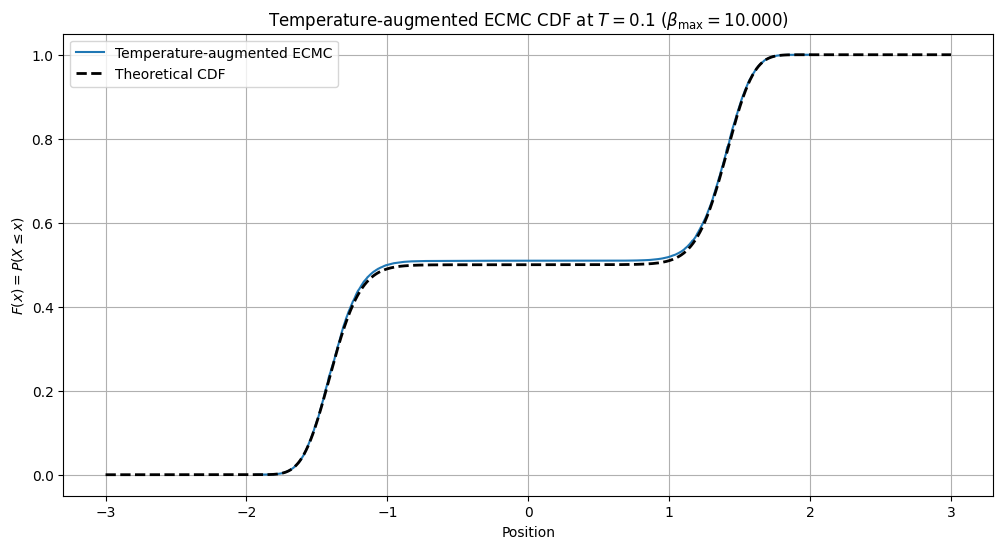

In [84]:
x_grid_augmented_cdf = np.linspace(-3, 3, 4000)

for temperature in temperatures:

    result = temperature_augmented_results[
        temperature
    ]

    beta_target = result["beta_target"]
    position_samples = result[
        "position_samples"
    ]

    if len(position_samples) == 0:
        print(
            f"No samples recorded for "
            f"T={temperature:.1f}."
        )
        continue

    (
        empirical_x_cdf,
        empirical_y_cdf
    ) = empirical_cdf(position_samples)

    theoretical_y_cdf = theoretical_cdf(
        x_grid_augmented_cdf,
        double_potential,
        temperature
    )

    result["empirical_x_cdf"] = empirical_x_cdf
    result["empirical_y_cdf"] = empirical_y_cdf
    result["theoretical_y_cdf"] = theoretical_y_cdf

    plt.figure(figsize=(12, 6))

    plt.plot(
        empirical_x_cdf,
        empirical_y_cdf,
        label="Temperature-augmented ECMC"
    )

    plt.plot(
        x_grid_augmented_cdf,
        theoretical_y_cdf,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Theoretical CDF"
    )

    plt.xlabel("Position")
    plt.ylabel(r"$F(x)=P(X\leq x)$")

    plt.title(
        "Temperature-augmented ECMC CDF "
        fr"at $T={temperature:.1f}$ "
        fr"$(\beta_{{\max}}={beta_target:.3f})$"
    )

    plt.grid()
    plt.legend()
    plt.show()

## Continuous vs Discrete Temperature Tempering

In [85]:
target_temperature = 0.1

comparison_samples = {
    "Reversible tempering": np.asarray(
        tempering_positions_by_temperature[
            target_temperature
        ]
    ),
    "Irreversible tempering": np.asarray(
        irreversible_positions_by_temperature[
            target_temperature
        ]
    ),
    "Temperature-augmented ECMC": np.asarray(
        temperature_augmented_results[
            target_temperature
        ]["position_samples"]
    )
}

maximum_common_samples = min(
    len(samples)
    for samples in comparison_samples.values()
)


sample_checkpoints = np.array([
    1_000,
    2_000,
    5_000,
    10_000,
    20_000,
    50_000,
    100_000,
    200_000
])

sample_checkpoints = sample_checkpoints[
    sample_checkpoints <= maximum_common_samples
]

sample_count_summary = pd.DataFrame({
    "Method": comparison_samples.keys(),
    "Available T=0.1 samples": [
        len(samples)
        for samples in comparison_samples.values()
    ]
})

print(sample_count_summary.to_string(index=False))
print(f"\nMaximum common sample count: {maximum_common_samples:,}")
print(f"Comparison checkpoints: {sample_checkpoints}")

                    Method  Available T=0.1 samples
      Reversible tempering                  1000105
    Irreversible tempering                  1000246
Temperature-augmented ECMC                    98147

Maximum common sample count: 98,147
Comparison checkpoints: [ 1000  2000  5000 10000 20000 50000]


In [86]:
comparison_x_grid = np.linspace(-3, 3, 4000)

target_theoretical_cdf = theoretical_cdf(
    comparison_x_grid,
    double_potential,
    target_temperature
)

cdf_convergence_records = []

for method, samples in comparison_samples.items():

    for num_samples in sample_checkpoints:

        checkpoint_samples = samples[:num_samples]

        empirical_x, empirical_y = empirical_cdf(
            checkpoint_samples
        )

        theoretical_at_empirical_x = np.interp(
            empirical_x,
            comparison_x_grid,
            target_theoretical_cdf
        )

        maximum_cdf_deviation = np.max(
            np.abs(
                empirical_y
                - theoretical_at_empirical_x
            )
        )

        cdf_convergence_records.append({
            "Method": method,
            "Samples": num_samples,
            "Maximum CDF deviation": maximum_cdf_deviation
        })

cdf_convergence_df = pd.DataFrame(
    cdf_convergence_records
)

cdf_convergence_table = cdf_convergence_df.pivot(
    index="Samples",
    columns="Method",
    values="Maximum CDF deviation"
)

print(cdf_convergence_table.to_string())

Method   Irreversible tempering  Reversible tempering  Temperature-augmented ECMC
Samples                                                                          
1000                   0.070197              0.095590                    0.204507
2000                   0.048924              0.042706                    0.164330
5000                   0.036050              0.043232                    0.018308
10000                  0.019315              0.036580                    0.012883
20000                  0.022810              0.039434                    0.015692
50000                  0.010686              0.010664                    0.006552


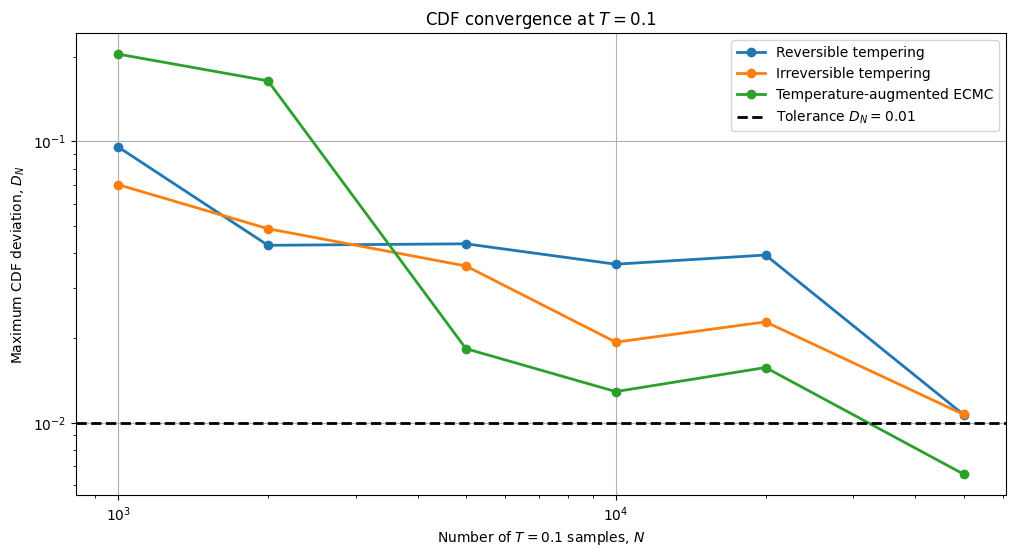

In [87]:
cdf_tolerance = 0.01

plt.figure(figsize=(12, 6))

for method in comparison_samples:

    method_results = cdf_convergence_df[
        cdf_convergence_df["Method"] == method
    ]

    plt.loglog(
        method_results["Samples"],
        method_results["Maximum CDF deviation"],
        marker="o",
        linewidth=2,
        label=method
    )

plt.axhline(
    cdf_tolerance,
    color="black",
    linestyle="--",
    linewidth=2,
    label=fr"Tolerance $D_N={cdf_tolerance}$"
)

plt.xlabel(r"Number of $T=0.1$ samples, $N$")
plt.ylabel(r"Maximum CDF deviation, $D_N$")
plt.title(r"CDF convergence at $T=0.1$")
plt.grid()
plt.legend()
plt.show()

## Final comparison configuration

In [88]:
pilot_seeds = [42, 43, 44, 45, 46]
target_temperature = 0.1

num_discrete_steps = 2_500_000
num_augmented_event_steps = 2_500_000

num_discrete_burn_in_steps = 50_000
num_augmented_burn_in_event_steps = 50_000

target_temperature_index = int(
    np.flatnonzero(
        np.isclose(
            tempering_temperatures,
            target_temperature
        )
    )[0]
)

target_beta = (
    1.0 / target_temperature
)

comparison_hot_temperature = float(
    np.max(tempering_temperatures)
)

comparison_beta_min = (
    1.0 / comparison_hot_temperature
)

comparison_beta_max = target_beta

comparison_physical_beta_interval = (
    comparison_beta_max
    - comparison_beta_min
)

sample_checkpoints = np.array([
    1_000,
    2_000,
    5_000,
    10_000,
    20_000,
    50_000,
    100_000,
    200_000
])

comparison_x_grid = np.linspace(-3.0, 3.0, 4_000)

target_theoretical_cdf = theoretical_cdf(
    comparison_x_grid,
    double_potential,
    target_temperature
)

In [89]:
(
    comparison_mean_energy_beta_grid,
    comparison_mean_energy_values,
    comparison_mean_energy_func
) = build_thermal_average_energy_interpolator(
    beta_min=comparison_beta_min,
    beta_max=comparison_beta_max,
    num_beta_points=1_001,
    potential_func=double_potential,
    x_grid=x_grid_tempering
)

print(
    f"Common temperature range: "
    f"{target_temperature:.1f} "
    f"to {comparison_hot_temperature:.1f}"
)

print(
    f"Common beta range: "
    f"{comparison_beta_min:.4f} "
    f"to {comparison_beta_max:.4f}"
)

Common temperature range: 0.1 to 1.2
Common beta range: 0.8333 to 10.0000


### Beta-speed tuning

In [90]:
tuning_seeds = [101, 102, 103]

num_tuning_event_steps = 500_000
tuning_burn_in_time = 10_000
cdf_samples_to_compare = 20_000

test_beta_speeds = [
    comparison_physical_beta_interval / 2.0,
    6.0,
    7.5,
    comparison_physical_beta_interval
]

beta_speed_tuning_records = []

for seed in tuning_seeds:

    for test_speed in test_beta_speeds:

        beta_speed = float(test_speed)

        local_rng = np.random.default_rng(seed)

        start_time = perf_counter()

        trajectory = run_temperature_augmented_ecmc(
            initial_x=local_rng.normal(),
            num_event_steps=num_tuning_event_steps,
            beta_min=comparison_beta_min,
            beta_max=comparison_beta_max,
            beta_speed=beta_speed,
            a=a,
            b=b,
            potential_func=double_potential,
            potential_derivative_func=(
                lambda x: dU_double(x, a, b)
            ),
            mean_energy_func=comparison_mean_energy_func,
            rng=local_rng
        )

        runtime = perf_counter() - start_time

        target_boundary_indices = (
            np.flatnonzero(
                trajectory["event_types"]
                == "boundary"
            )
            + 1
        )

        target_boundary_indices = (
            target_boundary_indices[
                np.isclose(
                    trajectory["beta_trajectory"][
                        target_boundary_indices
                    ],
                    comparison_beta_max,
                    atol=1e-10,
                    rtol=0.0
                )
                & (
                    trajectory["event_times"][
                        target_boundary_indices
                    ]
                    >= tuning_burn_in_time
                )
            ]
        )

        target_samples = trajectory[
            "position_trajectory"
        ][target_boundary_indices].copy()

        if (
            len(target_samples)
            < cdf_samples_to_compare
        ):
            raise RuntimeError(
                f"Seed {seed} at beta speed "
                f"{beta_speed:.4f} produced only "
                f"{len(target_samples)} target samples."
            )

        comparison_samples = target_samples[
            :cdf_samples_to_compare
        ]

        empirical_x, empirical_y = empirical_cdf(
            comparison_samples
        )

        theoretical_at_empirical_x = np.interp(
            empirical_x,
            comparison_x_grid,
            target_theoretical_cdf
        )

        maximum_cdf_deviation = np.max(
            np.abs(
                empirical_y
                - theoretical_at_empirical_x
            )
        )

        samples_per_second = (
            len(target_samples) / runtime
        )

        estimated_runtime_to_100k = (
            100_000 / samples_per_second
        )

        beta_speed_tuning_records.append({
            "Seed": seed,
            "Beta speed": beta_speed,
            "Effective beta interval": (
                comparison_physical_beta_interval
                / beta_speed
            ),
            "Runtime (seconds)": runtime,
            "Target samples": len(
                target_samples
            ),
            "Target samples per second": (
                samples_per_second
            ),
            "Estimated runtime to 100,000 samples": (
                estimated_runtime_to_100k
            ),
            "CDF samples compared": (
                cdf_samples_to_compare
            ),
            "Maximum CDF deviation": (
                maximum_cdf_deviation
            ),
            "Left-well proportion": np.mean(
                comparison_samples < 0
            )
        })

        print(
            f"Completed seed {seed}, "
            f"beta speed {beta_speed:.4f}."
        )


beta_speed_tuning_df = pd.DataFrame(
    beta_speed_tuning_records
)

print("\nIndividual tuning results")

print(
    beta_speed_tuning_df
    .round(6)
    .to_string(index=False)
)


beta_speed_tuning_summary = (
    beta_speed_tuning_df
    .groupby("Beta speed")
    .agg(
        Mean_target_samples_per_second=(
            "Target samples per second",
            "mean"
        ),
        Mean_estimated_runtime_to_100k=(
            "Estimated runtime to 100,000 samples",
            "mean"
        ),
        Mean_CDF_deviation=(
            "Maximum CDF deviation",
            "mean"
        ),
        Standard_deviation_CDF=(
            "Maximum CDF deviation",
            "std"
        ),
        Maximum_CDF_deviation=(
            "Maximum CDF deviation",
            "max"
        ),
        Mean_left_well_proportion=(
            "Left-well proportion",
            "mean"
        )
    )
    .reset_index()
)

print("\nBeta-speed tuning summary")

print(
    beta_speed_tuning_summary
    .round(6)
    .to_string(index=False)
)

Completed seed 101, beta speed 4.5833.
Completed seed 101, beta speed 6.0000.
Completed seed 101, beta speed 7.5000.
Completed seed 101, beta speed 9.1667.
Completed seed 102, beta speed 4.5833.
Completed seed 102, beta speed 6.0000.
Completed seed 102, beta speed 7.5000.
Completed seed 102, beta speed 9.1667.
Completed seed 103, beta speed 4.5833.
Completed seed 103, beta speed 6.0000.
Completed seed 103, beta speed 7.5000.
Completed seed 103, beta speed 9.1667.

Individual tuning results
 Seed  Beta speed  Effective beta interval  Runtime (seconds)  Target samples  Target samples per second  Estimated runtime to 100,000 samples  CDF samples compared  Maximum CDF deviation  Left-well proportion
  101    4.583333                 2.000000          31.399498           37899                1206.993800                             82.850467                 20000               0.013288               0.50665
  101    6.000000                 1.527778          29.027985           43287        

## Selected beta speed

In [91]:
comparison_beta_speed = 7.5

comparison_effective_beta_interval = (
    comparison_physical_beta_interval
    / comparison_beta_speed
)

print(
    f"Selected beta speed: "
    f"{comparison_beta_speed:.4f}"
)

print(
    f"Effective beta interval: "
    f"{comparison_effective_beta_interval:.4f}"
)

Selected beta speed: 7.5000
Effective beta interval: 1.2222


## Final comparison functions

In [92]:
def run_reversible_target_samples(seed_sequence):
    """
    Run reversible simulated tempering to collect samples at the target temperature.

    Args:
        seed_sequence (int): The seed for the random number generator.

    Returns:
        target_samples (np.ndarray): The collected samples at the target temperature.
        runtime (float): The runtime of the simulation.
    """     
    local_rng = np.random.default_rng(
        seed_sequence
    )

    start_time = perf_counter()

    result = run_simulated_tempering(
        initial_x=left_minimum,
        initial_index=target_temperature_index,
        num_steps=(
            num_discrete_burn_in_steps
            + num_discrete_steps
        ),
        betas=tempering_betas,
        log_weights=tempering_log_weights,
        metropolis_proposal_width=1.0,
        potential_func=double_potential,
        rng=local_rng
    )

    runtime = perf_counter() - start_time

    positions = result[
        "position_trajectory"
    ][num_discrete_burn_in_steps:]

    temperature_indices = result[
        "temperature_index_trajectory"
    ][num_discrete_burn_in_steps:]

    target_samples = positions[
        temperature_indices
        == target_temperature_index
    ].copy()

    return target_samples, runtime


def run_irreversible_target_samples(seed_sequence):
    """
    Run irreversible simulated tempering to collect samples at the target temperature.

    Args:
        seed_sequence (int): The seed for the random number generator.

    Returns:
        target_samples (np.ndarray): The collected samples at the target temperature.
        runtime (float): The runtime of the simulation.
    """
    local_rng = np.random.default_rng(
        seed_sequence
    )

    start_time = perf_counter()

    result = run_irreversible_simulated_tempering(
        initial_x=left_minimum,
        initial_index=target_temperature_index,
        initial_epsilon=-1,
        delta=irreversible_delta,
        num_steps=(
            num_discrete_burn_in_steps
            + num_discrete_steps
        ),
        betas=tempering_betas,
        log_weights=tempering_log_weights,
        metropolis_proposal_width=1.0,
        potential_func=double_potential,
        rng=local_rng
    )

    runtime = perf_counter() - start_time

    positions = result[
        "position_trajectory"
    ][num_discrete_burn_in_steps:]

    temperature_indices = result[
        "temperature_index_trajectory"
    ][num_discrete_burn_in_steps:]

    target_samples = positions[
        temperature_indices
        == target_temperature_index
    ].copy()

    return target_samples, runtime


def run_augmented_target_samples(seed_sequence):
    """
    Run temperature-augmented ECMC to collect samples at the target temperature.

    Args:
        seed_sequence (int): The seed for the random number generator.

    Returns:
        target_samples (np.ndarray): The collected samples at the target temperature.
        runtime (float): The runtime of the simulation.
    """
    local_rng = np.random.default_rng(
        seed_sequence
    )

    start_time = perf_counter()

    trajectory = run_temperature_augmented_ecmc(
        initial_x=left_minimum,
        num_event_steps=(
            num_augmented_burn_in_event_steps
            + num_augmented_event_steps
        ),
        beta_min=comparison_beta_min,
        beta_max=comparison_beta_max,
        beta_speed=comparison_beta_speed,
        a=a,
        b=b,
        potential_func=double_potential,
        potential_derivative_func=(
            lambda x: dU_double(x, a, b)
        ),
        mean_energy_func=(
            comparison_mean_energy_func
        ),
        rng=local_rng
    )

    runtime = (
        perf_counter() - start_time
    )

    # event_types[k] produces trajectory state k + 1.
    target_boundary_indices = (
        np.flatnonzero(
            trajectory["event_types"]
            == "boundary"
        )
        + 1
    )

    target_boundary_indices = (
        target_boundary_indices[
            np.isclose(
                trajectory["beta_trajectory"][
                    target_boundary_indices
                ],
                comparison_beta_max,
                atol=1e-10,
                rtol=0.0
            )
            & (
                target_boundary_indices
                >= num_augmented_burn_in_event_steps
            )
        ]
    )

    target_samples = trajectory[
        "position_trajectory"
    ][target_boundary_indices].copy()

    return target_samples, runtime


def run_one_pilot_seed(seed):
    """
    Run all three sampling methods for a given pilot seed and collect CDF convergence records.

    Args:
        seed (int): The seed for the random number generator.

    Returns:
        tuple: A tuple containing the CDF records and runtime records.
    """
    cdf_records = []
    run_records = []

    method_seed_sequences = (
        np.random.SeedSequence(seed).spawn(3)
    )

    reversible_samples, reversible_runtime = (
        run_reversible_target_samples(
            method_seed_sequences[0]
        )
    )

    irreversible_samples, irreversible_runtime = (
        run_irreversible_target_samples(
            method_seed_sequences[1]
        )
    )

    augmented_samples, augmented_runtime = (
        run_augmented_target_samples(
            method_seed_sequences[2]
        )
    )

    seeded_samples = {
        "Reversible tempering": (
            reversible_samples,
            reversible_runtime
        ),
        "Irreversible tempering": (
            irreversible_samples,
            irreversible_runtime
        ),
        "Temperature-augmented ECMC": (
            augmented_samples,
            augmented_runtime
        )
    }

    for method, (
        method_samples,
        method_runtime
    ) in seeded_samples.items():

        run_records.append({
            "Seed": seed,
            "Method": method,
            "Available T=0.1 samples": len(
                method_samples
            ),
            "Runtime (seconds)": method_runtime
        })

        for num_samples in sample_checkpoints:

            if len(method_samples) < num_samples:
                continue

            checkpoint_samples = method_samples[
                :num_samples
            ]

            empirical_x, empirical_y = empirical_cdf(
                checkpoint_samples
            )

            theoretical_at_empirical_x = np.interp(
                empirical_x,
                comparison_x_grid,
                target_theoretical_cdf
            )

            maximum_cdf_deviation = np.max(
                np.abs(
                    empirical_y
                    - theoretical_at_empirical_x
                )
            )

            cdf_records.append({
                "Seed": seed,
                "Method": method,
                "Samples": num_samples,
                "Maximum CDF deviation": (
                    maximum_cdf_deviation
                )
            })

    return cdf_records, run_records

### Final five-seed comparison

In [93]:
pilot_results = []

total_start_time = perf_counter()

for seed_number, seed in enumerate(
    pilot_seeds,
    start=1
):

    print(
        f"Running seed {seed} "
        f"({seed_number}/{len(pilot_seeds)})..."
    )

    seed_start_time = perf_counter()

    seed_result = run_one_pilot_seed(seed)

    pilot_results.append(seed_result)

    seed_runtime = (
        perf_counter() - seed_start_time
    )

    print(
        f"Completed seed {seed} in "
        f"{seed_runtime:.2f} seconds."
    )

Running seed 42 (1/5)...
Completed seed 42 in 241.85 seconds.
Running seed 43 (2/5)...
Completed seed 43 in 243.65 seconds.
Running seed 44 (3/5)...
Completed seed 44 in 242.52 seconds.
Running seed 45 (4/5)...
Completed seed 45 in 240.46 seconds.
Running seed 46 (5/5)...
Completed seed 46 in 241.85 seconds.


In [94]:
pilot_cdf_records = [
    record
    for cdf_records, _ in pilot_results
    for record in cdf_records
]

pilot_run_records = [
    record
    for _, run_records in pilot_results
    for record in run_records
]

pilot_cdf_df = pd.DataFrame(
    pilot_cdf_records
)

pilot_run_df = pd.DataFrame(
    pilot_run_records
)

total_runtime = (
    perf_counter() - total_start_time
)

print(
    f"\nCompleted all pilot runs in "
    f"{total_runtime:.2f} seconds."
)

print("\nPilot runtime summary")

print(
    pilot_run_df.to_string(
        index=False
    )
)


Completed all pilot runs in 1210.34 seconds.

Pilot runtime summary
 Seed                     Method  Available T=0.1 samples  Runtime (seconds)
   42       Reversible tempering                   249491          37.695303
   42     Irreversible tempering                   249840          62.224310
   42 Temperature-augmented ECMC                   243097         141.806934
   43       Reversible tempering                   251647          36.773771
   43     Irreversible tempering                   249321          62.275844
   43 Temperature-augmented ECMC                   243310         144.481352
   44       Reversible tempering                   247657          37.242442
   44     Irreversible tempering                   250172          62.412623
   44 Temperature-augmented ECMC                   243110         142.740892
   45       Reversible tempering                   251182          37.728352
   45     Irreversible tempering                   249804          61.347750
   45 T

## Accuracy summary

In [95]:
cdf_tolerance = 0.01

maximum_checkpoint = int(
    pilot_cdf_df["Samples"].max()
)

pilot_summary = (
    pilot_cdf_df
    .groupby(["Method", "Samples"])[
        "Maximum CDF deviation"
    ]
    .agg(
        Mean="mean",
        Standard_deviation="std",
        Maximum="max"
    )
    .reset_index()
)

print("CDF deviation summary")
print(pilot_summary.to_string(index=False))

convergence_records = []

for method, group in pilot_cdf_df.groupby("Method"):

    mean_deviation = (
        group
        .groupby("Samples")[
            "Maximum CDF deviation"
        ]
        .mean()
        .sort_index()
    )

    within_tolerance = (
        mean_deviation <= cdf_tolerance
    ).to_numpy()

    # Require the mean deviation at every later checkpoint
    # to remain below the tolerance.
    sustained = np.logical_and.accumulate(
        within_tolerance[::-1]
    )[::-1]

    if sustained.any():
        convergence_checkpoint = int(
            mean_deviation.index[sustained][0]
        )
        convergence_label = (
            f"{convergence_checkpoint:,}"
        )
    else:
        convergence_label = (
            f">{maximum_checkpoint:,}"
        )

    final_results = group[
        group["Samples"] == maximum_checkpoint
    ]["Maximum CDF deviation"]

    num_converged = int(
        (final_results <= cdf_tolerance).sum()
    )

    convergence_records.append({
        "Method": method,
        "Mean convergence checkpoint": (
            convergence_label
        ),
        "Seeds below tolerance at final checkpoint": (
            f"{num_converged}/{len(final_results)}"
        ),
        "Mean final deviation": (
            final_results.mean()
        ),
        "Standard deviation": (
            final_results.std()
        ),
        "Maximum final deviation": (
            final_results.max()
        )
    })

convergence_summary = pd.DataFrame(
    convergence_records
)

numeric_columns = [
    "Mean final deviation",
    "Standard deviation",
    "Maximum final deviation"
]

convergence_summary[numeric_columns] = (
    convergence_summary[numeric_columns].round(6)
)

print("\nConvergence summary")
print(convergence_summary.to_string(index=False))

CDF deviation summary
                    Method  Samples     Mean  Standard_deviation  Maximum
    Irreversible tempering     1000 0.064226            0.033446 0.120977
    Irreversible tempering     2000 0.051655            0.015551 0.070353
    Irreversible tempering     5000 0.030032            0.037655 0.097201
    Irreversible tempering    10000 0.029223            0.018023 0.056488
    Irreversible tempering    20000 0.015881            0.010488 0.031747
    Irreversible tempering    50000 0.010510            0.003792 0.016369
    Irreversible tempering   100000 0.009774            0.006324 0.016479
    Irreversible tempering   200000 0.005713            0.005229 0.014530
      Reversible tempering     1000 0.078628            0.021801 0.101889
      Reversible tempering     2000 0.075992            0.051028 0.157939
      Reversible tempering     5000 0.047787            0.027793 0.072540
      Reversible tempering    10000 0.020576            0.010612 0.036124
      Reversible

In [96]:
final_seed_results = (
    pilot_cdf_df[
        pilot_cdf_df["Samples"]
        == maximum_checkpoint
    ]
    .pivot(
        index="Seed",
        columns="Method",
        values="Maximum CDF deviation"
    )
)

print(
    f"Results at the final checkpoint "
    f"({maximum_checkpoint:,} samples)"
)

print(
    final_seed_results.to_string()
)

Results at the final checkpoint (200,000 samples)
Method  Irreversible tempering  Reversible tempering  Temperature-augmented ECMC
Seed                                                                            
42                    0.006439              0.004607                    0.008082
43                    0.014530              0.017802                    0.010896
44                    0.002877              0.003452                    0.003964
45                    0.002890              0.002635                    0.006778
46                    0.001831              0.008125                    0.004224


## Final comparison plots

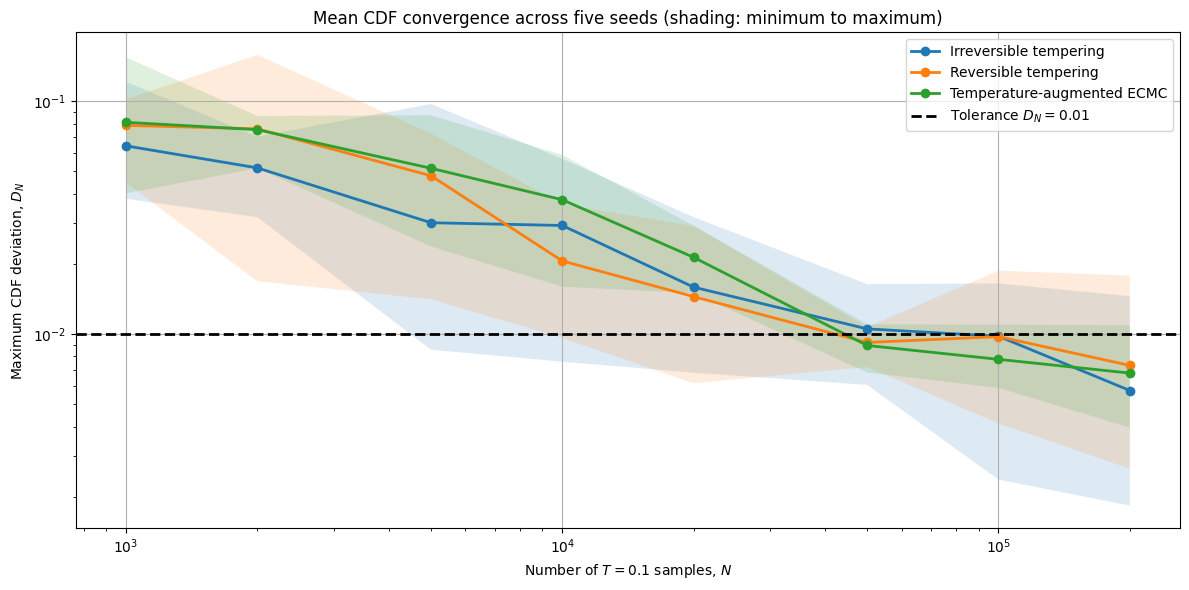

In [97]:
cdf_plot_summary = (
    pilot_cdf_df
    .groupby(["Method", "Samples"])[
        "Maximum CDF deviation"
    ]
    .agg(
        Mean="mean",
        Minimum="min",
        Maximum="max"
    )
    .reset_index()
)

plt.figure(figsize=(12, 6))

for method, method_results in (
    cdf_plot_summary.groupby("Method")
):

    method_results = method_results.sort_values(
        "Samples"
    )

    sample_values = method_results[
        "Samples"
    ].to_numpy()

    mean_values = method_results[
        "Mean"
    ].to_numpy()

    lower_values = method_results[
        "Minimum"
    ].to_numpy()

    upper_values = method_results[
        "Maximum"
    ].to_numpy()

    plt.plot(
        sample_values,
        mean_values,
        marker="o",
        linewidth=2,
        label=method
    )

    plt.fill_between(
        sample_values,
        lower_values,
        upper_values,
        alpha=0.15
    )

plt.axhline(
    cdf_tolerance,
    color="black",
    linestyle="--",
    linewidth=2,
    label=fr"Tolerance $D_N={cdf_tolerance}$"
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Number of $T=0.1$ samples, $N$")
plt.ylabel(r"Maximum CDF deviation, $D_N$")
plt.title(
    "Mean CDF convergence across five seeds "
    "(shading: minimum to maximum)"
)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

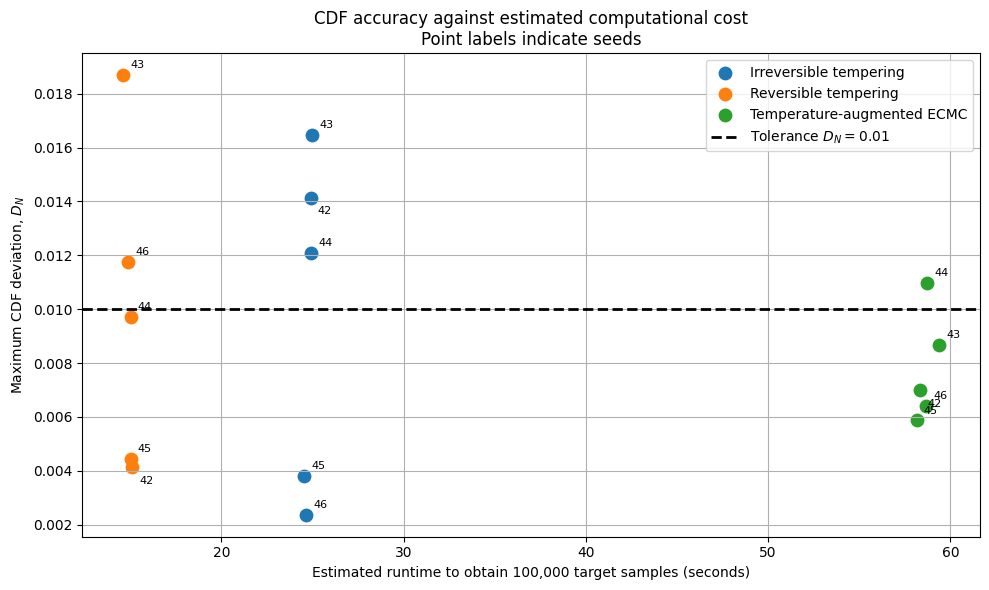

In [98]:
accuracy_at_100k = pilot_cdf_df[
    pilot_cdf_df["Samples"] == 100_000
].copy()

runtime_efficiency = pilot_run_df.copy()

runtime_efficiency[
    "Estimated runtime to 100,000 samples"
] = (
    runtime_efficiency["Runtime (seconds)"]
    * 100_000
    / runtime_efficiency[
        "Available T=0.1 samples"
    ]
)

runtime_accuracy = accuracy_at_100k.merge(
    runtime_efficiency[
        [
            "Seed",
            "Method",
            "Estimated runtime to 100,000 samples"
        ]
    ],
    on=["Seed", "Method"]
)

plt.figure(figsize=(10, 6))

for method, method_results in (
    runtime_accuracy.groupby("Method")
):

    plt.scatter(
        method_results[
            "Estimated runtime to 100,000 samples"
        ],
        method_results[
            "Maximum CDF deviation"
        ],
        s=80,
        label=method
    )

seed_label_offsets = {
    42: (5, -12),
    43: (5, 5),
    44: (5, 5),
    45: (5, 5),
    46: (5, 5)
}

for _, row in runtime_accuracy.iterrows():

    seed = int(row["Seed"])

    plt.annotate(
        str(seed),
        (
            row[
                "Estimated runtime "
                "to 100,000 samples"
            ],
            row[
                "Maximum CDF deviation"
            ]
        ),
        xytext=seed_label_offsets[seed],
        textcoords="offset points",
        fontsize=8
    )

plt.axhline(
    cdf_tolerance,
    color="black",
    linestyle="--",
    linewidth=2,
    label=fr"Tolerance $D_N={cdf_tolerance}$"
)

plt.xlabel(
    "Estimated runtime to obtain 100,000 "
    "target samples (seconds)"
)
plt.ylabel(r"Maximum CDF deviation, $D_N$")
plt.title(
    "CDF accuracy against estimated computational cost"
    "\nPoint labels indicate seeds"
)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## Monotonic Cubic Spline for $\langle U \rangle_\beta$

In [99]:
from scipy.interpolate import PchipInterpolator

mean_energy_spline = PchipInterpolator(
    mean_energy_beta_grid,
    mean_energy_values
)

def mean_energy_spline_func(beta):
    """
    Interpolate the mean energy at a given inverse temperature

    Args:
        beta (float or numpy.ndarray): The inverse temperature(s) at which to interpolate.

    Raises:
        ValueError: If the inverse temperature is outside the valid range.

    Returns:
        float or numpy.ndarray: The interpolated mean energy.
    """
    beta_values = np.asarray(beta)

    if (
        np.any(beta_values < beta_min)
        or np.any(beta_values > beta_max)
    ):
        raise ValueError(
            "beta must lie inside [beta_min, beta_max]."
        )

    spline_values = mean_energy_spline(
        beta_values
    )

    if beta_values.ndim == 0:
        return float(spline_values)

    return spline_values

In [100]:
linear_mean_energies = mean_energy_func(
    validation_betas
)

spline_mean_energies = mean_energy_spline_func(
    validation_betas
)

linear_errors = np.abs(
    direct_mean_energies
    - linear_mean_energies
)

spline_errors = np.abs(
    direct_mean_energies
    - spline_mean_energies
)

maximum_linear_error = np.max(
    linear_errors
)

maximum_spline_error = np.max(
    spline_errors
)

print(
    "Maximum linear interpolation error: "
    f"{maximum_linear_error:.10f}"
)

print(
    "Maximum monotonic-spline interpolation error: "
    f"{maximum_spline_error:.10f}"
)

Maximum linear interpolation error: 0.0000113940
Maximum monotonic-spline interpolation error: 0.0000001810


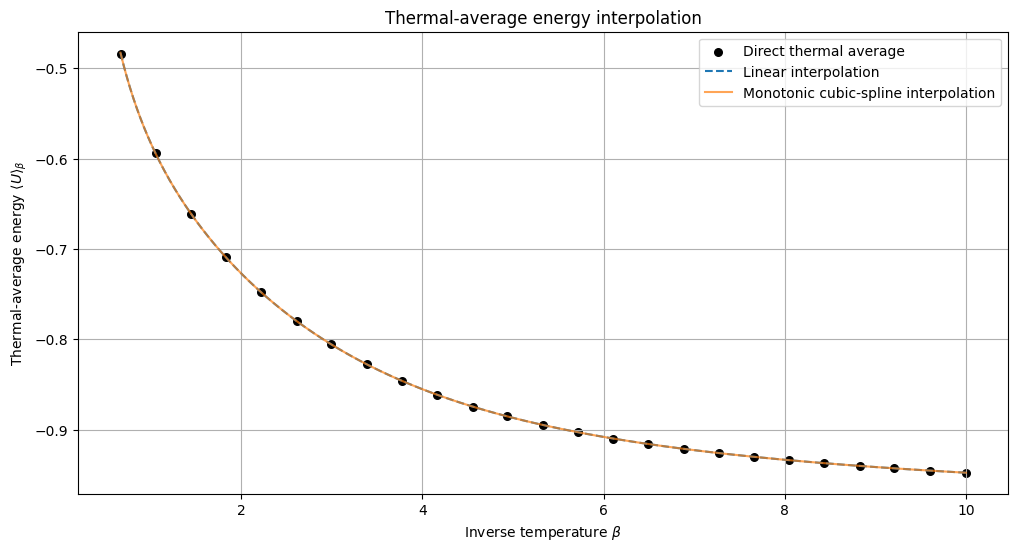

In [101]:
beta_plot_grid = np.linspace(
    beta_min,
    beta_max,
    10_001
)

linear_plot_values = mean_energy_func(
    beta_plot_grid
)

spline_plot_values = mean_energy_spline_func(
    beta_plot_grid
)

plt.figure(figsize=(12, 6))

plt.scatter(
    validation_betas,
    direct_mean_energies,
    color="black",
    s=30,
    label="Direct thermal average"
)

plt.plot(
    beta_plot_grid,
    linear_plot_values,
    linestyle="--",
    label="Linear interpolation"
)

plt.plot(
    beta_plot_grid,
    spline_plot_values,
    alpha=0.7,
    label="Monotonic cubic-spline interpolation"
)

plt.xlabel(r"Inverse temperature $\beta$")
plt.ylabel(r"Thermal-average energy $\langle U\rangle_\beta$")
plt.title("Thermal-average energy interpolation")
plt.grid()
plt.legend()
plt.show()

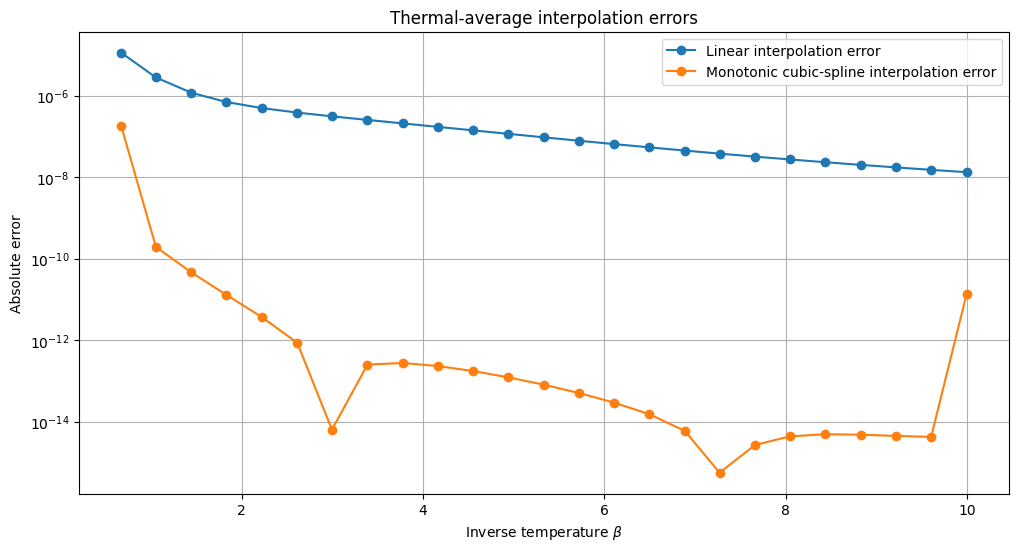

In [102]:
plt.figure(figsize=(12, 6))

plt.semilogy(
    validation_betas,
    linear_errors,
    marker="o",
    label="Linear interpolation error"
)

plt.semilogy(
    validation_betas,
    spline_errors,
    marker="o",
    label="Monotonic cubic-spline interpolation error"
)

plt.xlabel(r"Inverse temperature $\beta$")
plt.ylabel("Absolute error")
plt.title("Thermal-average interpolation errors")
plt.grid()
plt.legend()
plt.show()

In [103]:
spline_derivatives = (
    mean_energy_spline.derivative()(
        beta_plot_grid
    )
)

assert np.all(
    spline_derivatives <= 1e-12
)

assert (
    maximum_spline_error
    < maximum_linear_error
)

spline_improvement_factor = (
    maximum_linear_error
    / maximum_spline_error
)

print(
    "Spline error improvement factor: "
    f"{spline_improvement_factor:.1f}"
)

Spline error improvement factor: 63.0


1. Verify that the code works by running at T = 0.1 for ~10 times longer.
2. Then play around with both the beta interval length and the beta speed (relative to the x speed) to optimise performance.
3. Then do an initial comparison between the three tempering methods at T = 0.1; once you've got a feel for that, try to characterise the performance differences numerically (eg, number of samples required for the CDFs to converge within some tolerance - can then do error estimates as UQ is important in PMSC). 
4. Then we can think about the spline stuff and/or speed change along the beta direction.